In [2]:
require(data.table)
require(tidyverse)
require(phyloseq)
require(ggplot2)
require(RColorBrewer)
require(metacoder)
require(vegan)
require(DESeq2)
options(repr.plot.width=20, repr.plot.height=15)

# Table of Contents
* [1. Looking into ps_16S read counts across samples](##investigate_read_counts)
- make sure negatives have low reads
- see that Seq_run 1 has weird counts (high and low read count outliers)
* [2. ps_16S cleaning](##clean_phyloseq_object)
- remove mitochondrial and chloroplast
- remove singletons
* [3. OTU exploration](##how_many_taxa_showup?)
    * [3.1 Rare OTUs](##any_super_rare_OTUs?)
* [4. Rarefaction Curves](#rarefaction_curves)
    * [4.1 Rarefaction curves for filtered ps_16S](##rarefaction_curve_ps)
    * [4.2 Rarefaction curves for filtered ps_16S wihtout Seq run 1](##rarefaction_curve_ps_no1)
    * [4.4 Rarefaction curve for each host species](##species_rarefaction_curve_ps_no1)
* [5. Filtering Parameters](#filtering_ps_prune_for_outliers)
    * [5.1 Finding outlier read counts for filtering ps](##filtering_threshold)
    * [5.2 Filtering read counts outliers from ps_16S](##removing_under_10K_reads)
    * [5.2.1 Cleaning ps_high](###filtering_ps_high)
* [6. Alpha Diversity plots for each species](#species_diversity_plots)
    * [6.1 Make sure ps_high_prune is in chronological order](##chron_dates)
    * [6.2 Separate host species after 10K filter](##split_species_post_10K_filter)
    * [6.3 PAST plots Date sampled by Diversity Measurment](##PAST)
        * [6.3.1 Colored by Transect](###transect)
        * [6.3.2 Colored by Health Status](###health_status)
    * [6.4 MCAV plots Date sampled by Diversity Measurment](##MCAV)
        * [6.4.1 Colored by Transect](###transect)
        * [6.4.2 Colored by Health Status](###health_status)
* [7. Deseq2 for Unique coral species](#DeSeq2)
* [8. Network analysis using phyloseq package](#network_analysis?)

In [3]:
ps<-readRDS(file = "/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/BEL_16S_outputs/ps_16S.rds")
#removing any taxa that don't show up in any samples to speed up the process
ps

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 268938 taxa and 479 samples ]
sample_data() Sample Data:       [ 479 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 268938 taxa by 6 taxonomic ranks ]

**479 samples instead of 480 because 042024_T1_429_PAST was an AS**

## investigate_read_counts

- make sure negatives have low numbers of reads
1. reads histogram
2. create total_reads table

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


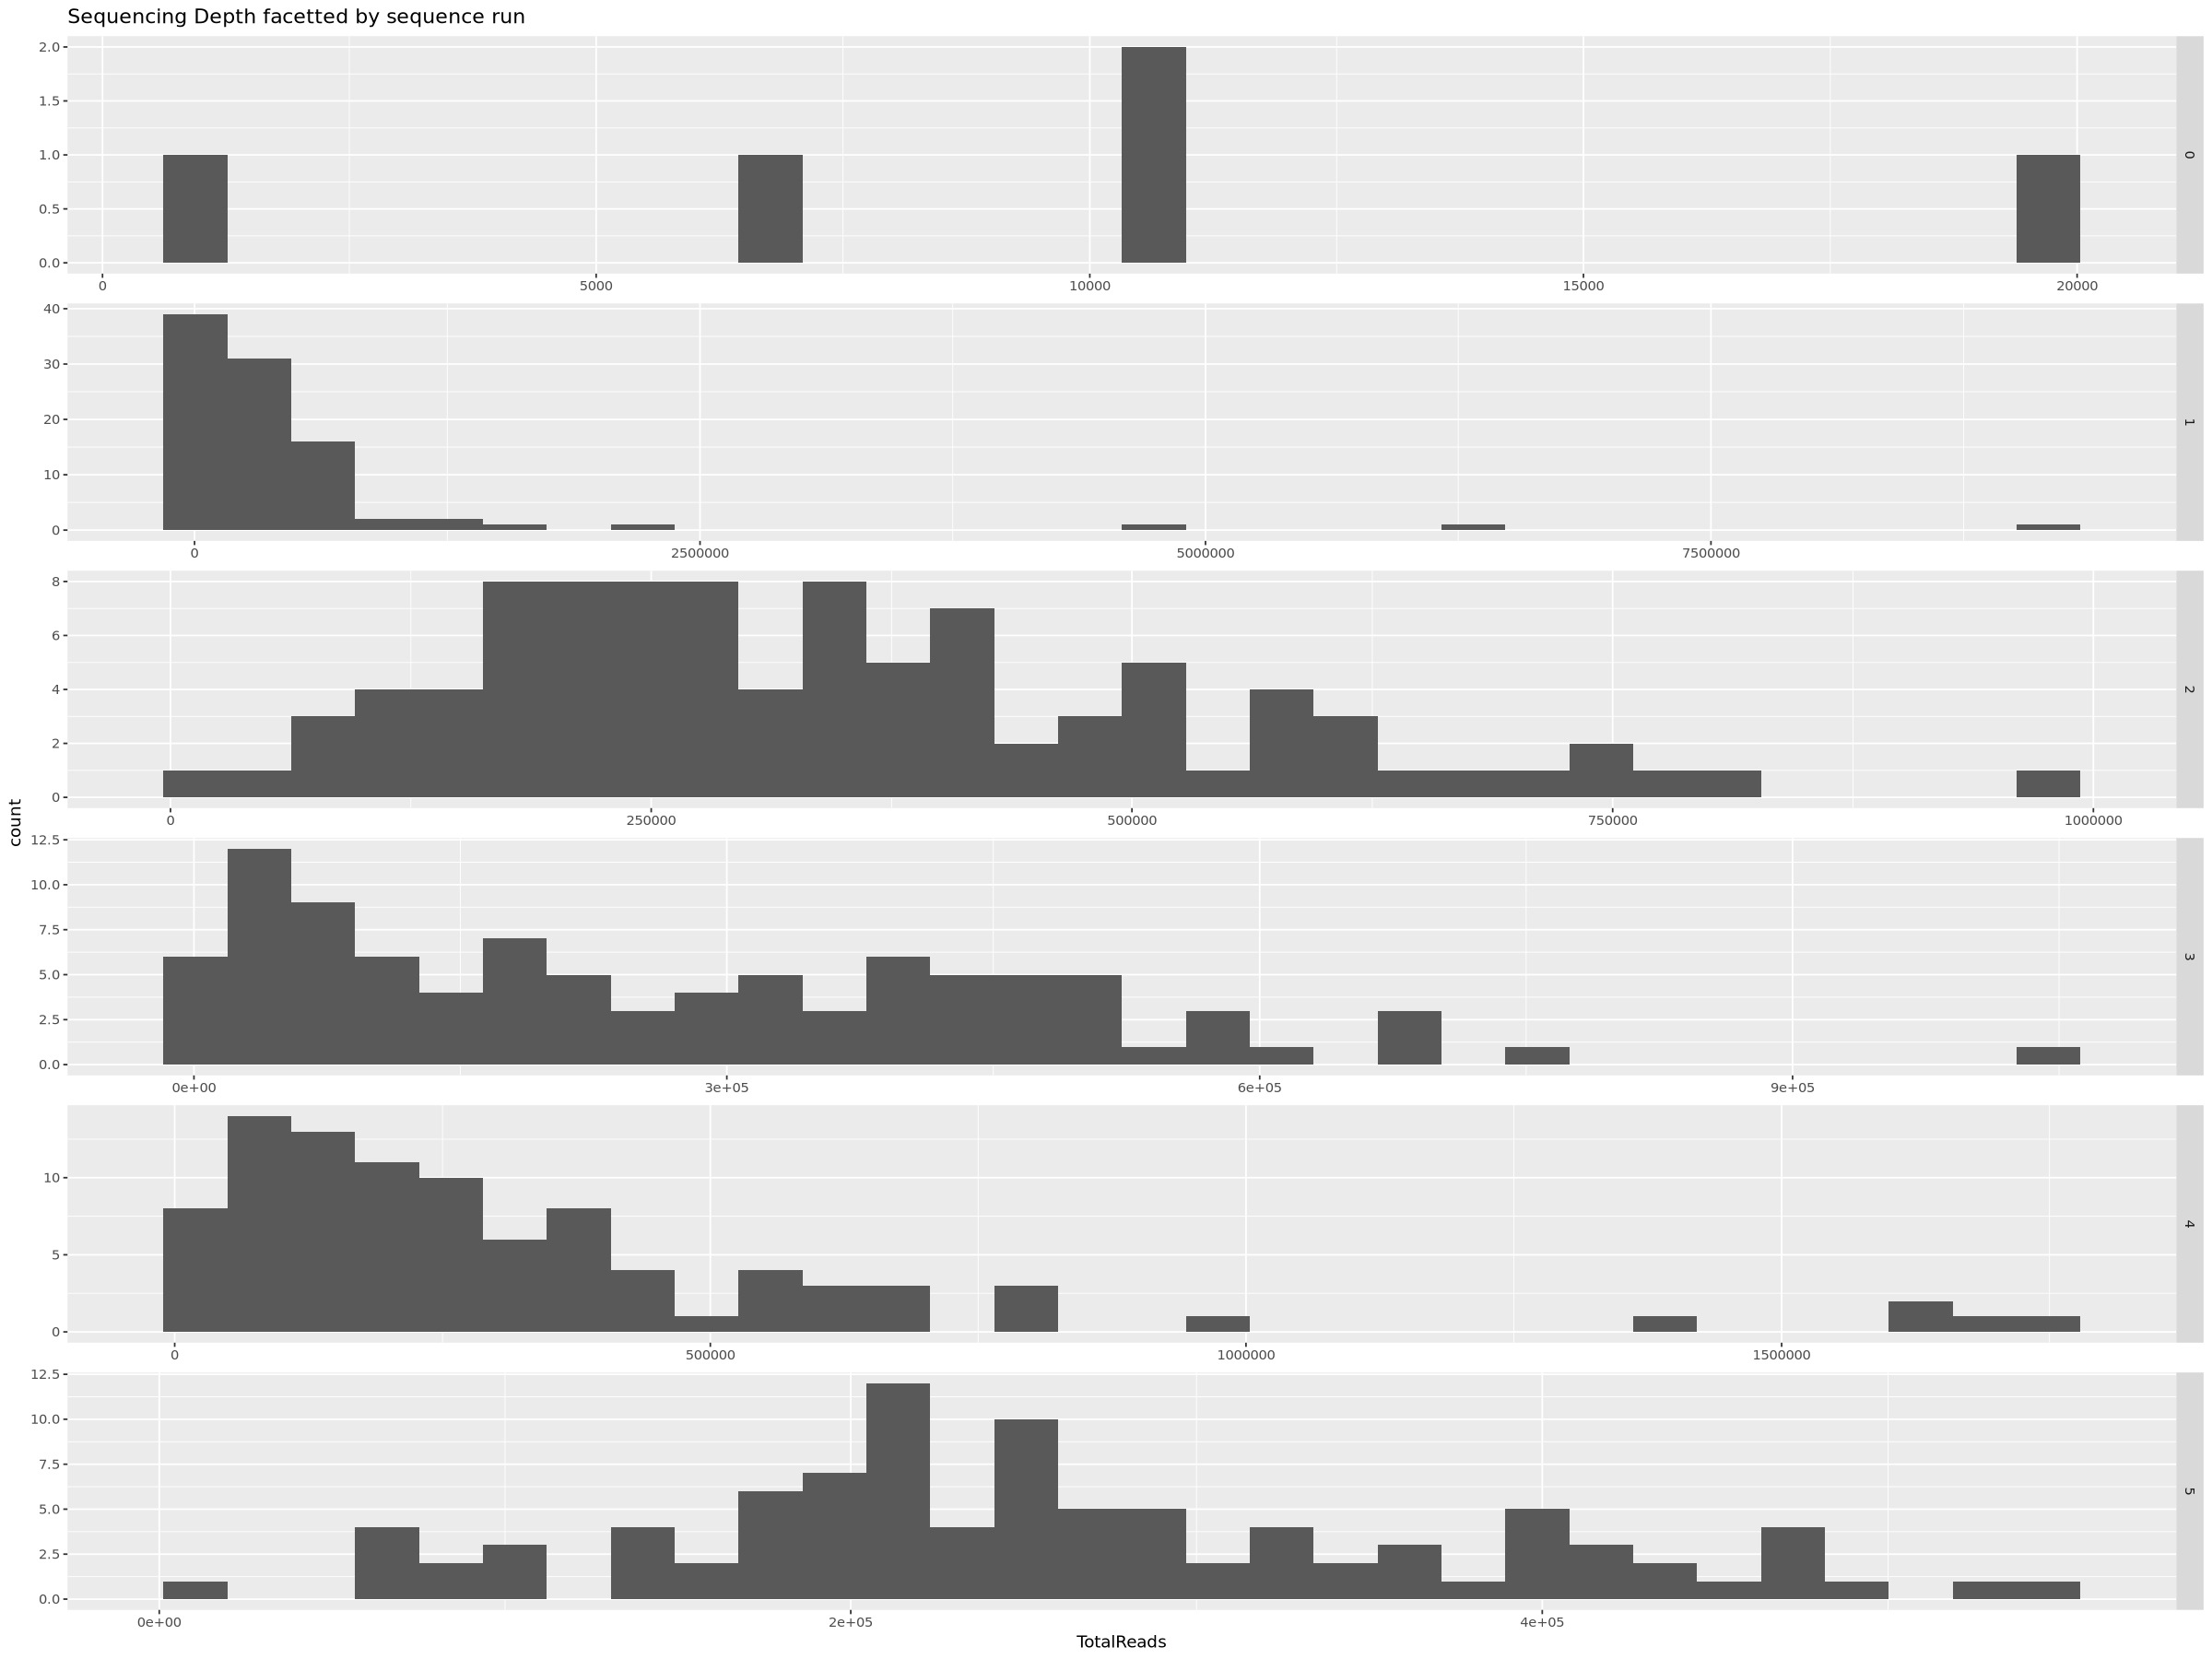

In [4]:
# Check read count
readcount = data.table(as(sample_data(ps), "data.frame"),
                 TotalReads = sample_sums(ps), 
                 keep.rownames = TRUE)
setnames(readcount, "rn", "SampleID")
ggplot(readcount, aes(TotalReads)) + geom_histogram() + ggtitle("Sequencing Depth facetted by sequence run") + facet_wrap(Seq_run ~., strip.position = "right",  ncol = 1, scales="free")  # Set desired font size

### figure notes
- negative controls are listed as seq run 0. they all have less than 2000 reads

In [5]:
total_reads <- print(readcount[order(readcount$TotalReads), c("SampleID", "TotalReads")])

# median reads
median(readcount$TotalReads)

# mean reads
mean(readcount$TotalReads)

# minimum read number
readcount[, min(TotalReads)]

                        SampleID TotalReads
                          <char>      <num>
  1:  012024_BEL_CBC_T1_561_OANN        765
  2:                    Negative        940
  3:  042024_BEL_CBC_T3_960_OFAV       3853
  4:  122022_BEL_CBC_T3_142_MCAV       4868
  5:                  Negative.4       6771
 ---                                       
475:  012024_BEL_CBC_T3_625_SSID    1749091
476: 042024_BEL_CBC_T2_1018_PAST    2096344
477: 082024_BEL_CBC_T3_1562_OFAV    4651047
478: 062024_BEL_CBC_T2_1375_SSID    6257366
479:  092023_BEL_CBC_T2_184_MCAV    9169329


[1] 257489

[1] 348608.4

[1] 765

## clean_phyloseq_object
- remove chloroplast and mitochondrial taxa
- remove singletons

In [6]:
#isolate just bacteria
ps_bac=subset_taxa(ps, Kingdom=="Bacteria")
ps_bac

#remove chloroplast order
ps_nochlo=subset_taxa(ps_bac, Order!="Chloroplast")
ps_nochlo

#remove mitochondria family
ps_nomit=subset_taxa(ps_nochlo, Family!="Mitochondria")
ps_nomit

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 104196 taxa and 479 samples ]
sample_data() Sample Data:       [ 479 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 104196 taxa by 6 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 78949 taxa and 479 samples ]
sample_data() Sample Data:       [ 479 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 78949 taxa by 6 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46684 taxa and 479 samples ]
sample_data() Sample Data:       [ 479 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 46684 taxa by 6 taxonomic ranks ]

In [7]:
#removing any taxa that don't show up in any samples to speed up the process

#maybe I should up to 1 to remove singletons
ps_prune <- prune_taxa(taxa_sums(ps_nomit) > 0, ps_nomit)
ps_prune

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46551 taxa and 479 samples ]
sample_data() Sample Data:       [ 479 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 46551 taxa by 6 taxonomic ranks ]

## how_many_taxa_showup?

Warning message:
“Some columns are a multi-column type (such as a matrix column): [1, 2, 3, 4, 5, 6]. setDT will retain these columns as-is but subsequent operations like grouping and joining may fail. Please consider as.data.table() instead which will create a new column for each embedded column.”
Warning message:
“Some columns are a multi-column type (such as a matrix column): [1, 2, 3, 4, 5, 6]. setDT will retain these columns as-is but subsequent operations like grouping and joining may fail. Please consider as.data.table() instead which will create a new column for each embedded column.”
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


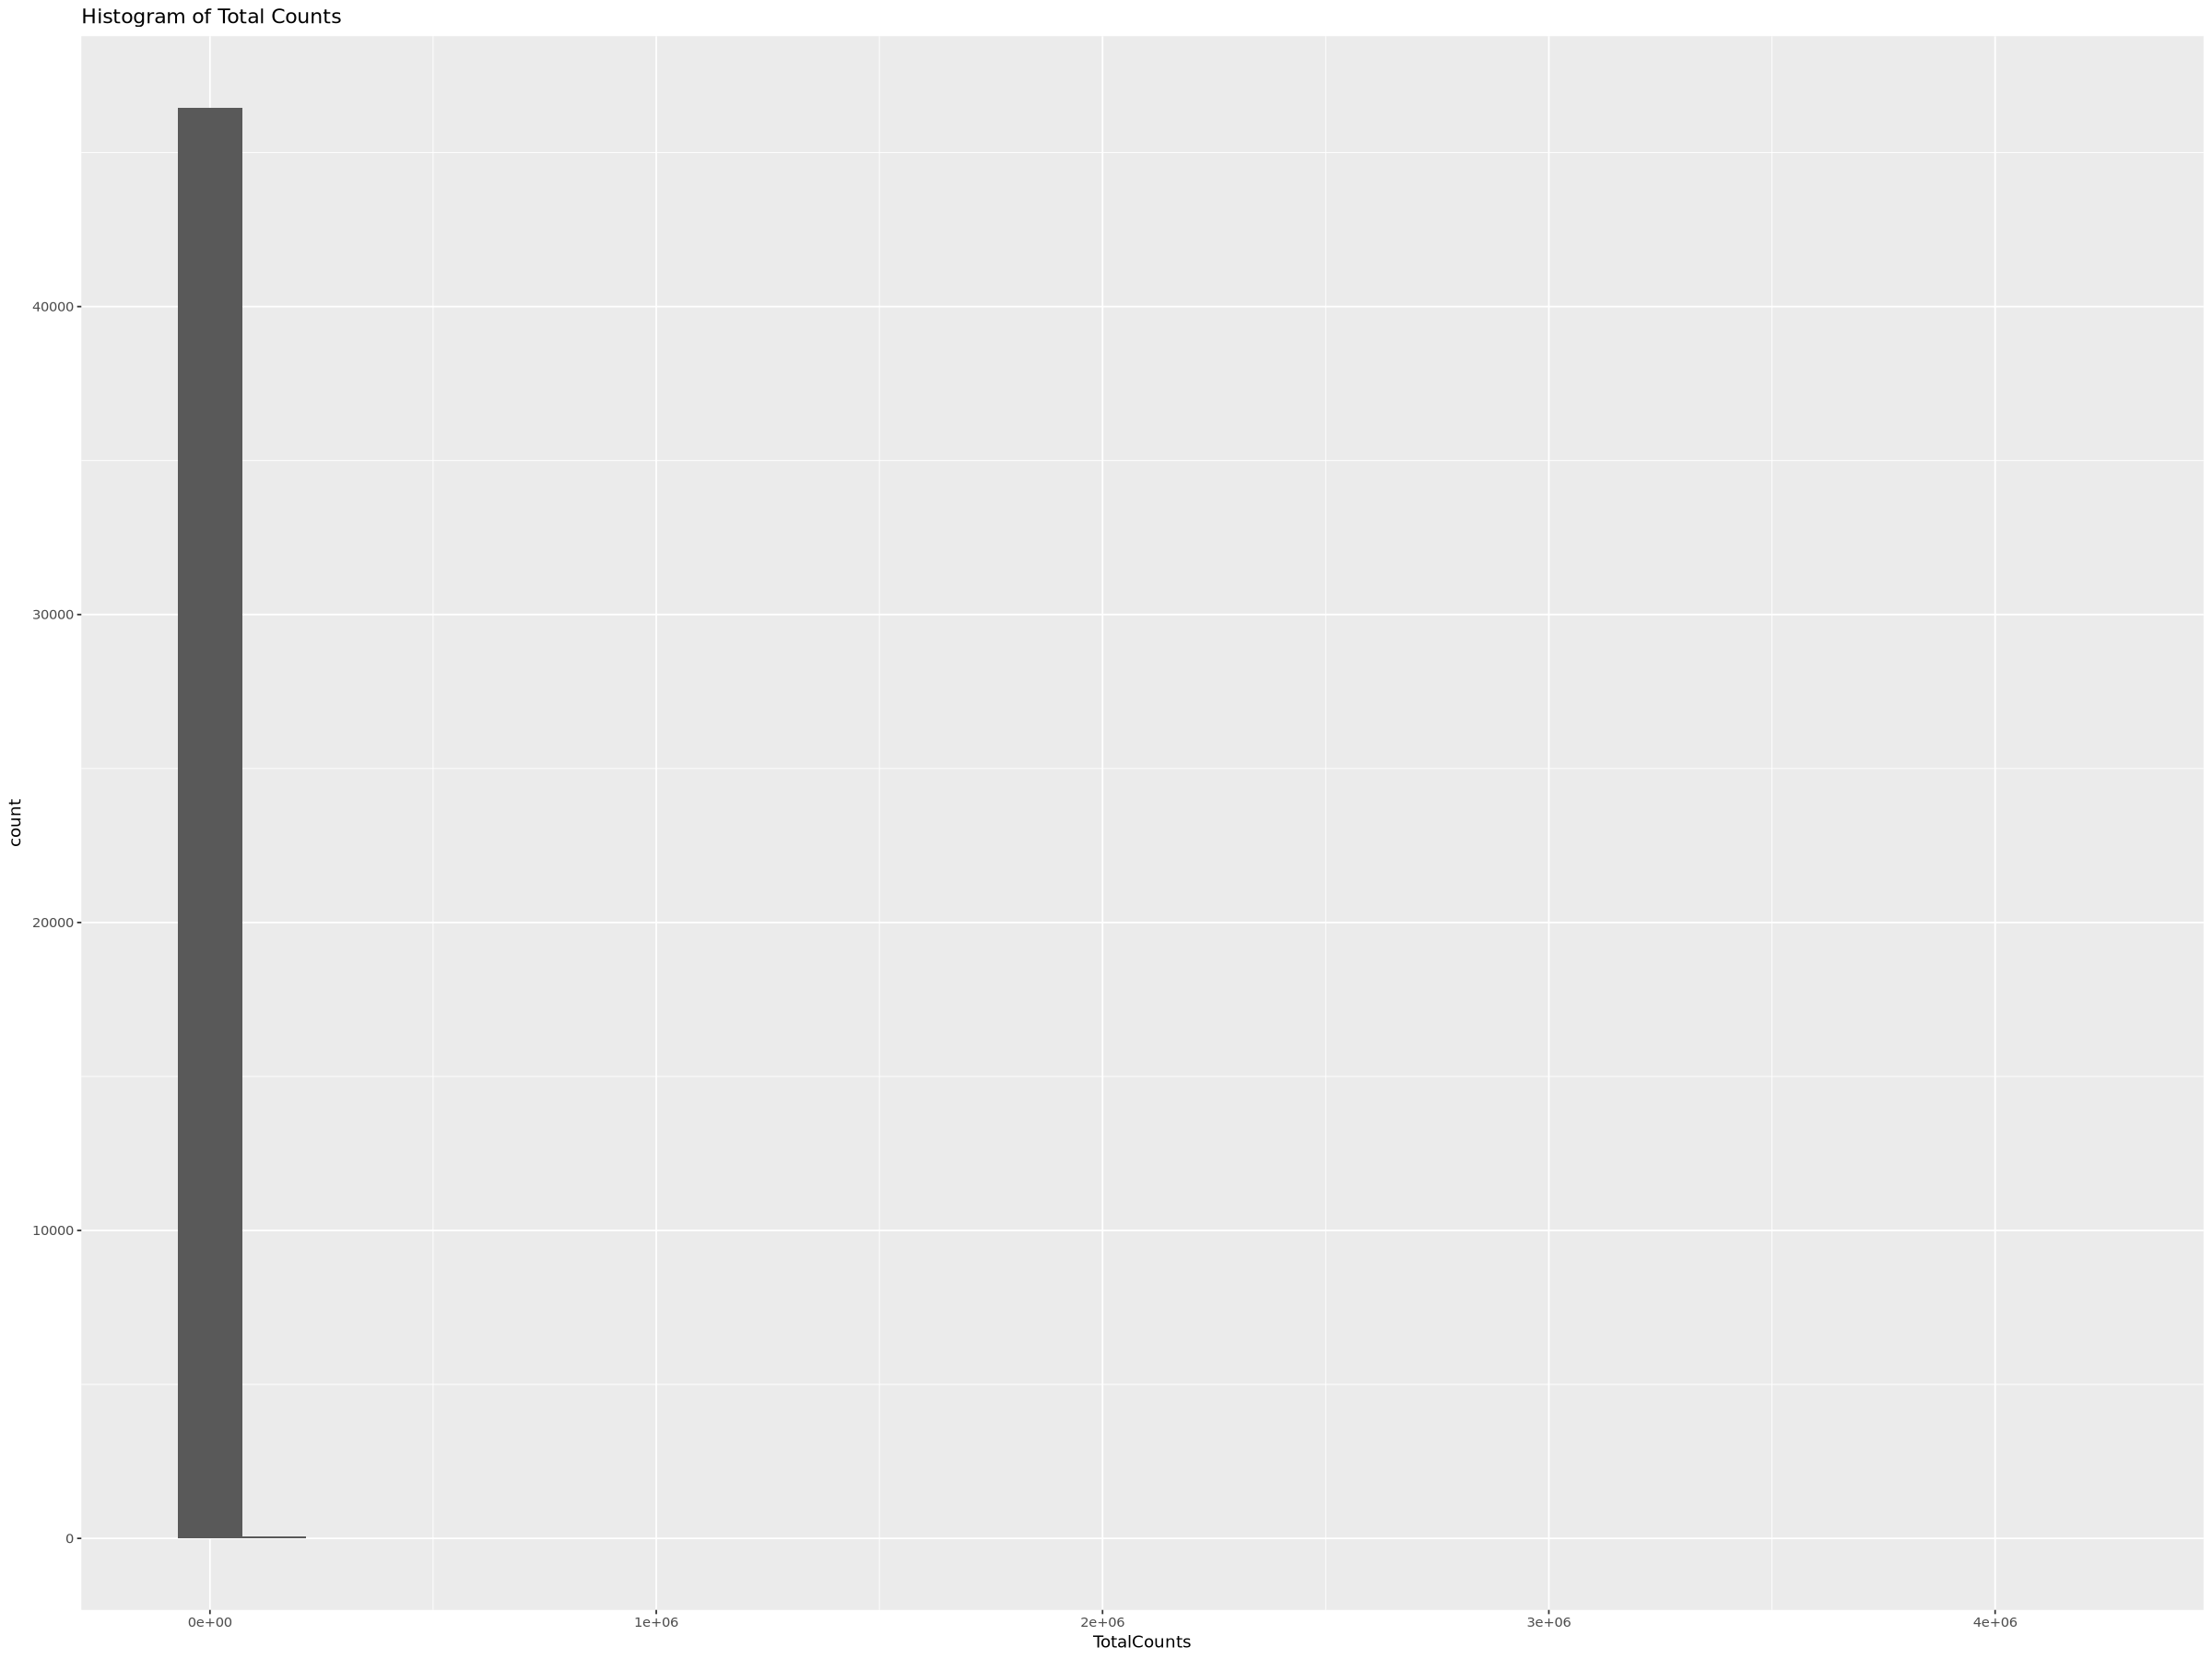

In [14]:
tdt = data.table(tax_table(ps_prune),
                 TotalCounts = taxa_sums(ps_prune),
                 OTU = taxa_names(ps_prune))
ggplot(tdt, aes(TotalCounts)) + 
  geom_histogram() + 
  ggtitle("Histogram of Total Counts")

### figure notes
- most otus show up less than 1E06 times

## any_super_rare_OTUs?

In [11]:
# How many singletons?
tdt[(TotalCounts <= 0), .N]

# already filtered for otus that don't show up in any samples
#313 in ps
tdt[(TotalCounts <= 1), .N]

# 5 OTU singletons in ps_prine
#there are 325 OTU in ps

# How many doubletons?
tdt[(TotalCounts <= 2), .N]
# 787 doubleton otus in ps_prune
#there are 2964 otu that only show up twice

[1] 0

[1] 5

[1] 787

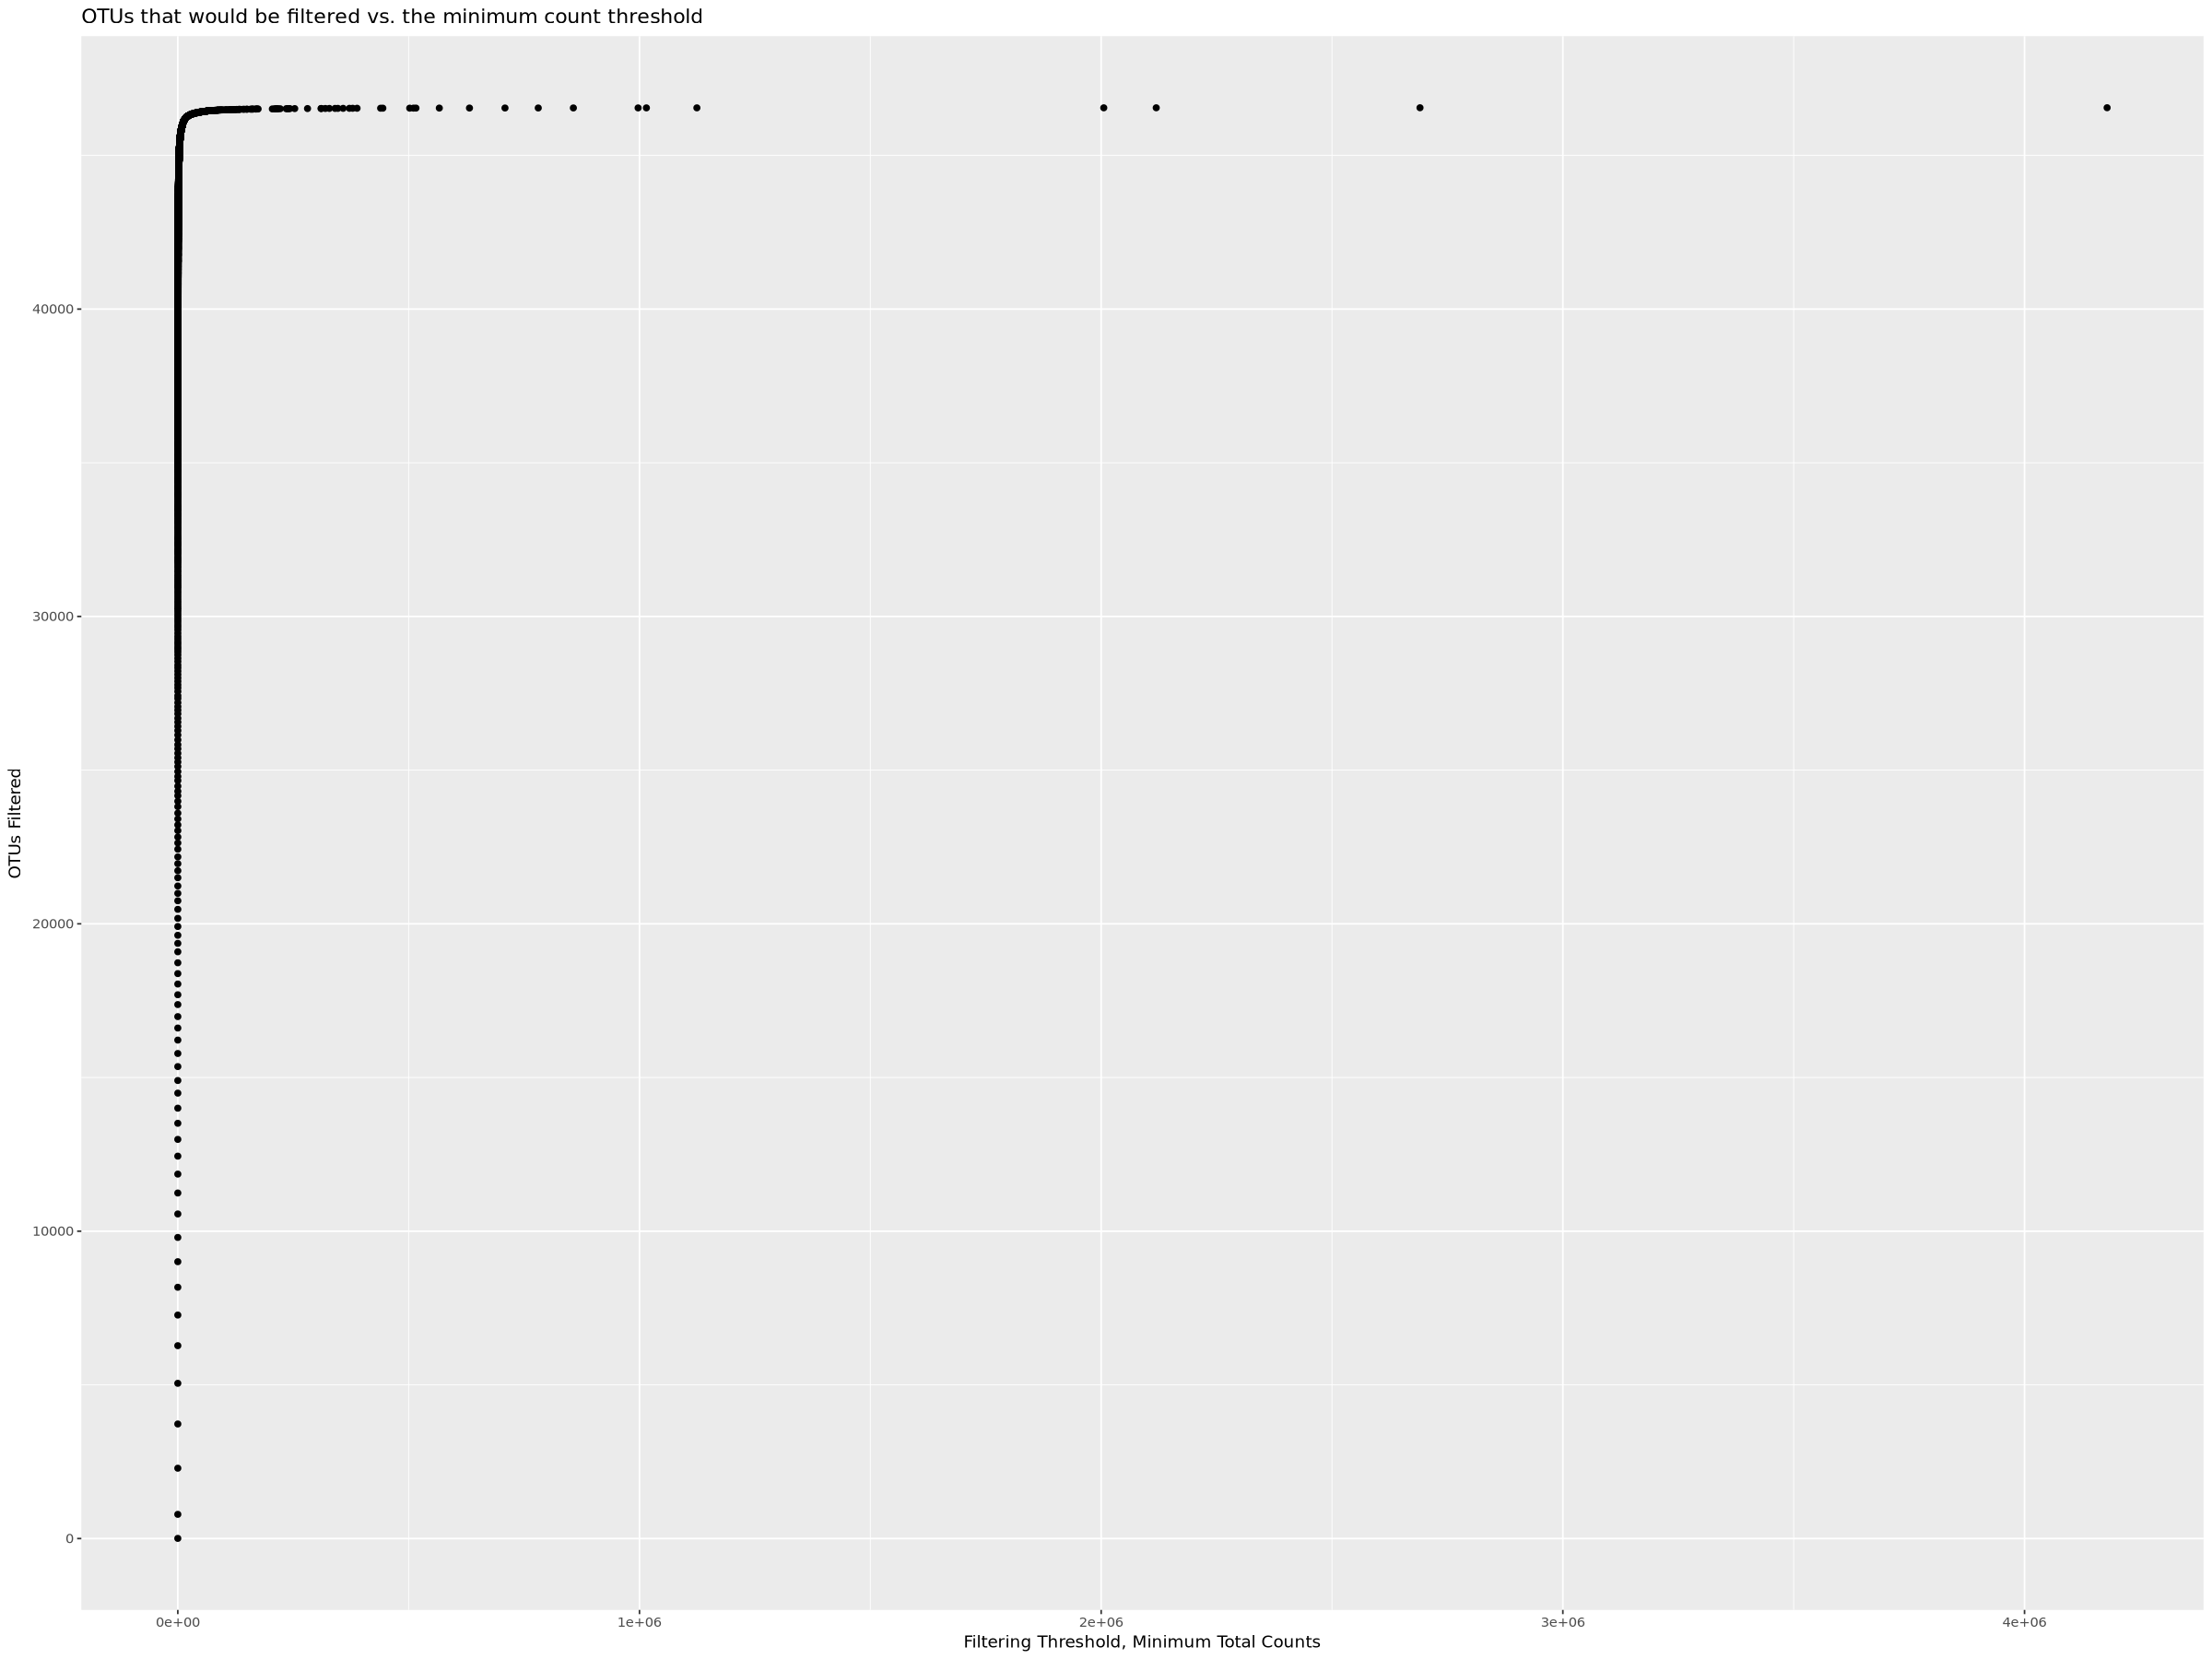

In [12]:
# taxa cumulative sum
taxcumsum = tdt[, .N, by = TotalCounts]
setkey(taxcumsum, TotalCounts)
taxcumsum[, CumSum := cumsum(N)]
# Define the plot
pCumSum = ggplot(taxcumsum, aes(TotalCounts, CumSum)) + 
  geom_point() +
  xlab("Filtering Threshold, Minimum Total Counts") +
  ylab("OTUs Filtered") +
  ggtitle("OTUs that would be filtered vs. the minimum count threshold")
pCumSum

Warning message:
“Removed 553 rows containing missing values or values outside the scale range
(`geom_point()`).”


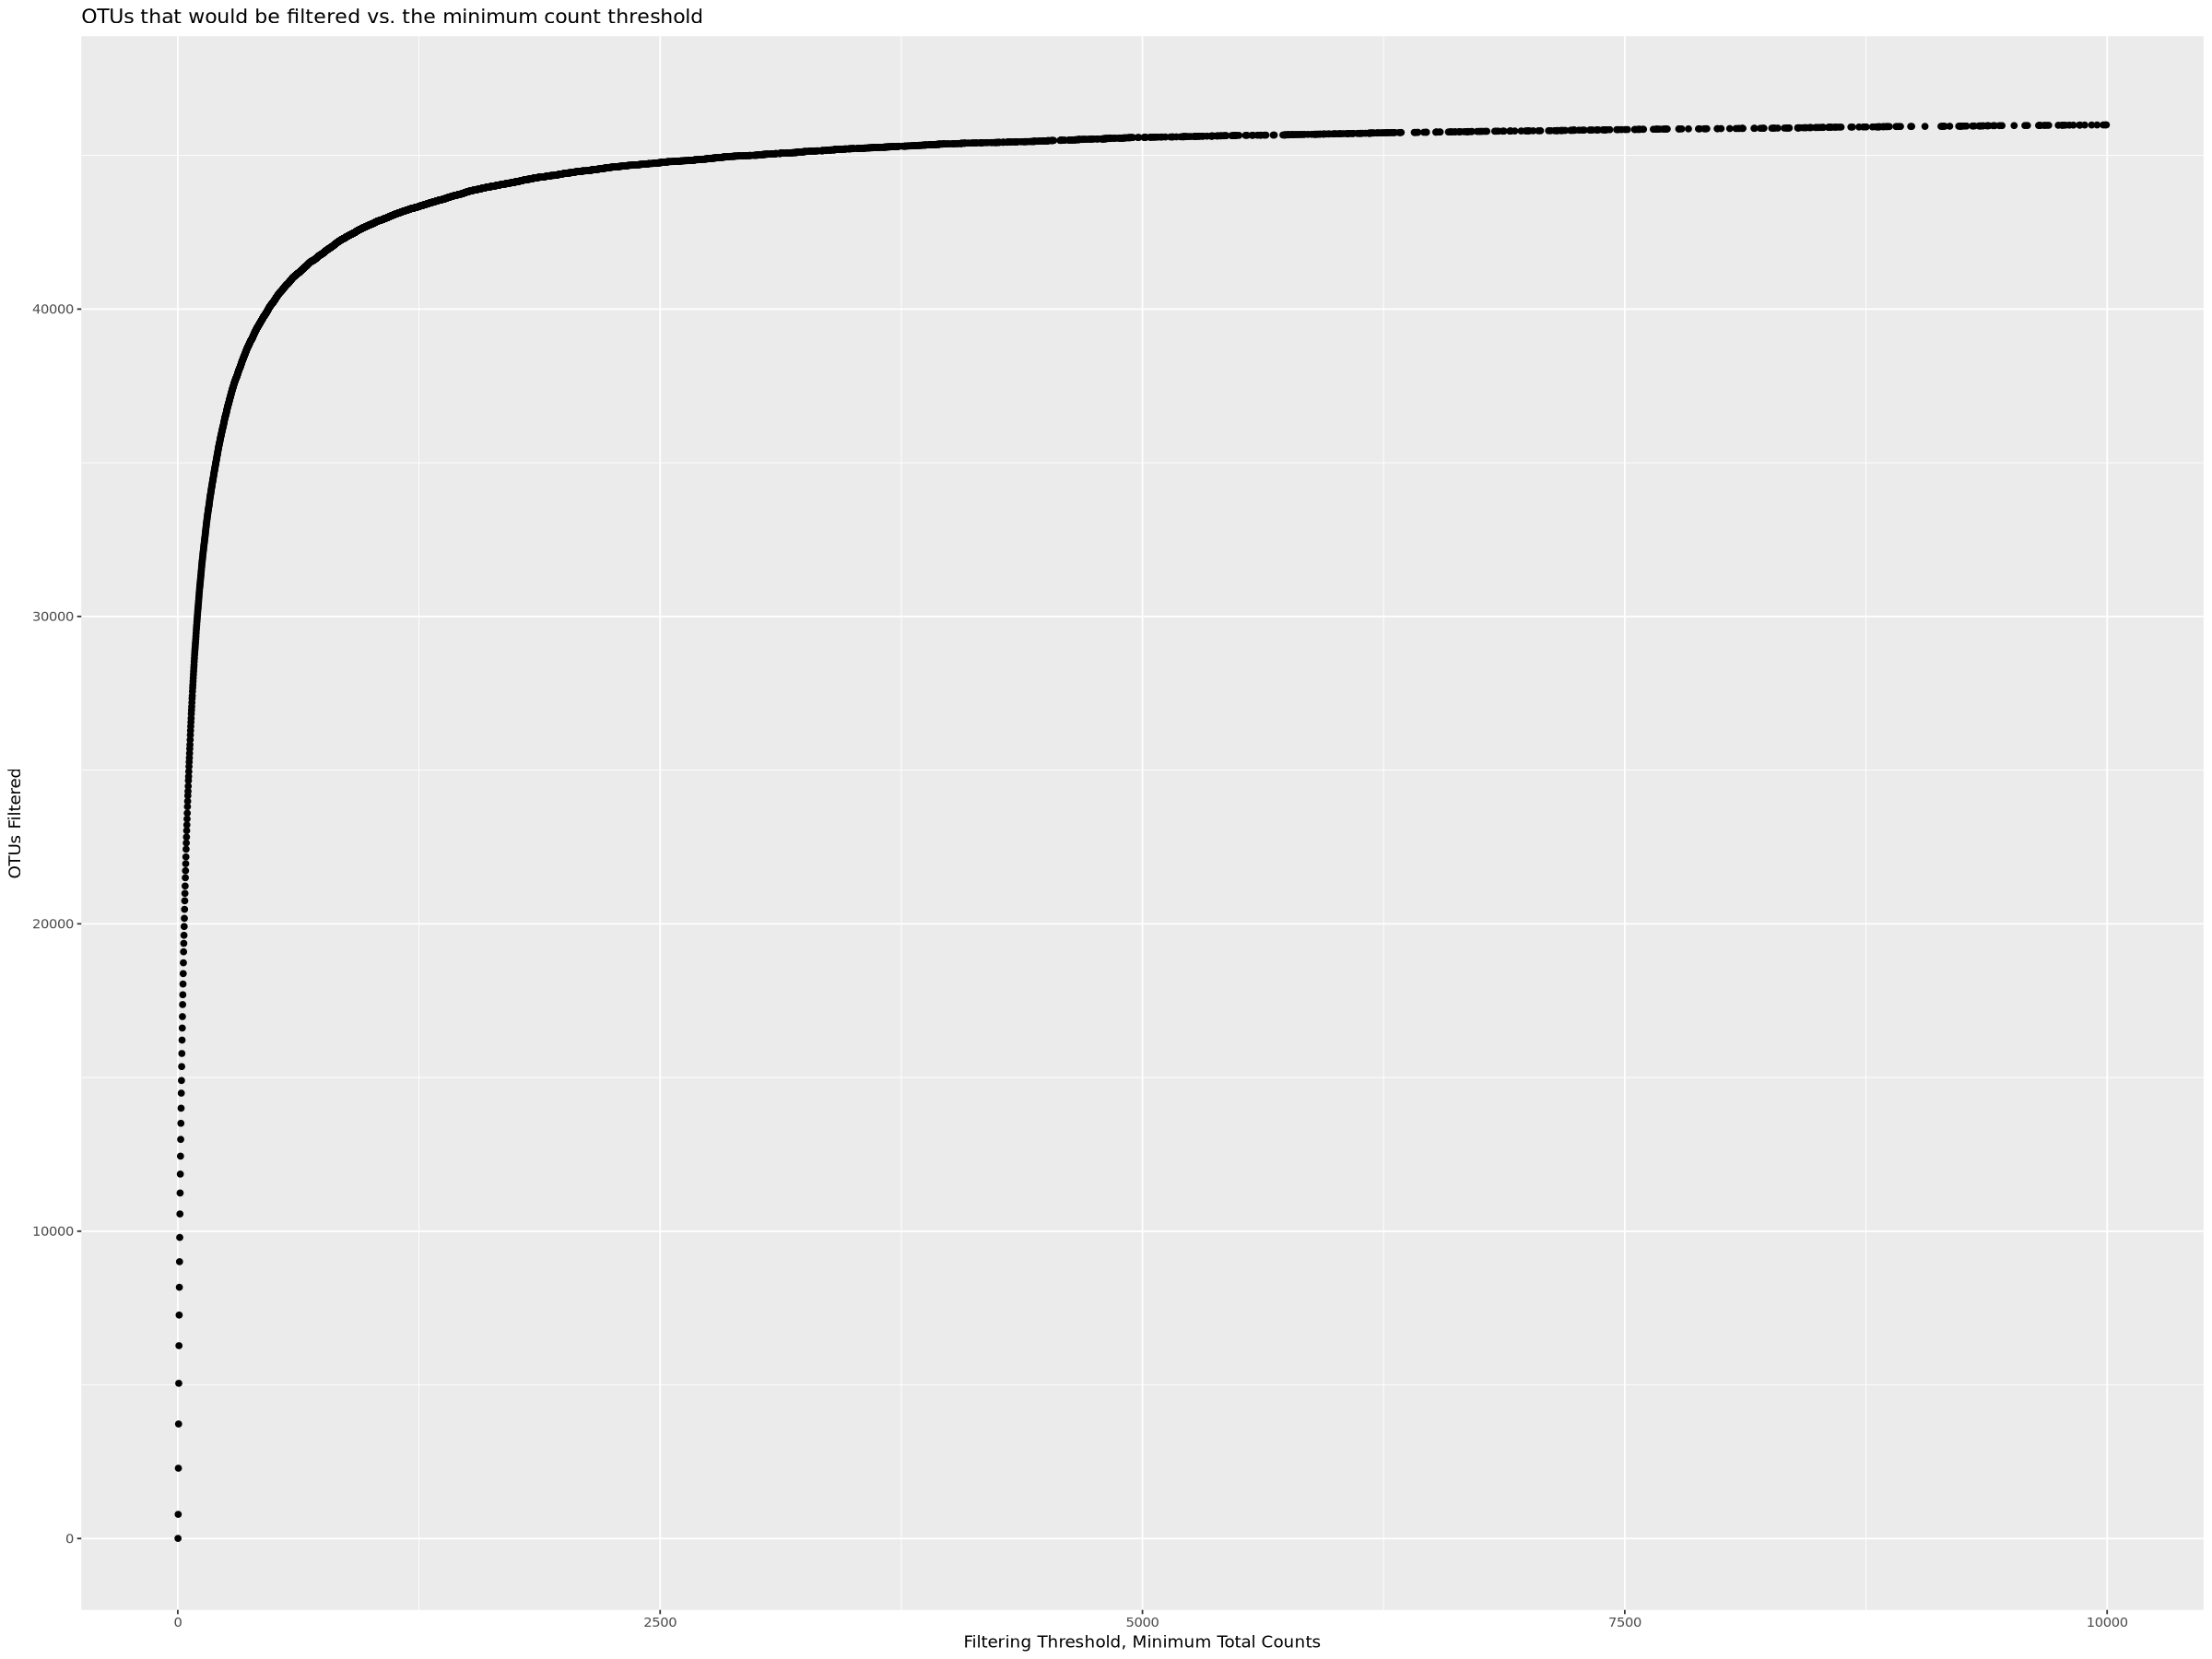

In [13]:
# Zoom-in to 0-10000 otu counts
pCumSum + xlim(0, 10000)

### figure notes 

**I dont really know what the point of plotting this is https://evomics.org/wp-content/uploads/2016/01/phyloseq-Lab-01-Answers.html**

- cumulative sum of OTUs that would be filtered at every possible value of such a threshold, from zero to the most-observed OTU.

- this plot shows us that if I filter out OTu's that appear less than 1000 times then I will be losing 40,000 OTUs

- goal is to justify and document decision for filtering. The goal of filtering is to remove noise from the data, in this case noisy variables that are unlikely to provide any useful information. Our criteria for this filtering should not include variables from which we want to infer biological insights later on. Why is that?




# rarefaction_curves
- test out if sequencing depth was optimal for revealing the OTU species that exist in each sample
- As the curve flattens, it suggests that the sequencing data volume is optimised (additional data would yield only a minimal increase in new OTUs)
- rarefaction curve could be used to determined whether the sequencing depth cover microbial diversity of the sample

### notes:

**vegan::rarefy() is using the exact calculation when rarefying data**
- calculates expected # of taxa we would see for a given sampling depth 
- this only works to find species richness

**vegan::rrarefy() calculates the expectations once at a time rather than for all reads at once**
- if want diversity metrics use empricial rarefaction (rrarefy)

**vegan::drarefy() calculates the probability of seeing an ASV in a sample if we had the minimum number of reads**

#### organization of otu_table
**to be able to plot rarefaction curve in vegan, dataframe must be:**
- sampleID as rownames, OTU labels across cols, otu counts as col values

## rarefaction_curve_ps
- all species and runs in the same plot

- step: tells R to evaluate diversity at X number of reads (decreasing this makes curves smoother but takes longer).
- sample: Subsample size. If specified, a vertical line is drawn at this sample size, along with horizontal lines marking rarefied species richness.
- label: Adds labels to the curves using the row names of your dataset.

In [51]:
head(otu_table(ps_prune))

,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATAGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGAGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,GCAAGCGTTGTTCGGAATTACTGGGCGTAAAGGGCGTGTAGGCGGATTATCAAGTTAGGGGTGAAATCCCGGGGCTCAACCTCGGCACTGCCTTTAAGACTGATAATCTAGAGTATGTGAGGGGATAATGGAATACCTAGTGTAGAGGTGAAATTCGTAGATATTAGGTGGAACACCAGTGGCGAAGGCGATTATCTGGCACATTACTGACGCTGAGGCGCGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGGGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,TCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCGCGTAGGCGGTTTGCTAAGTCAGATGTGAAATCCCTGGGCTTAACCTAGGAACTGCATTTGAAACTAGCAAGCTAGAGTATGGTAGAGGTGGGTGGAATTTCAGGTGTAGCGGTGGAATGCGTAGAGATCTGAAGGAACATCAGTGGCGAAGGCGGCTCACTGGGCCATCACTGACGCTGAGGTGCGAAAGCGTGGGT,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATTGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGCGCGTAGGCGGTGTGTTAAGTCGGATGTGAAAGCCCAGGGCTCAACCTTGGAATTGCATCCGATACTGGCACGCTAGAGTGCAGTAGAGGGAGGTGGAATTTCCGGTGTAGCGGTGAAATGCGTAGAGATCGGAAGGAACACCAGTGGCGAAGGCGGCCTCCTGGACTGACACTGACGCTGAGGTGCGAAAGCGTGGGG,GCAAGCGTTGTTCGGATTTACTGGGCGTAAAGGGTGCGTAGGTGGCATGACAAGTCACTTGTGAAATCTCCGAGCTTAACTCGGAACGGTCAAGTGATACTGTTGTGCTAGAGTGCGGGAAGGGCAGCTGGAATTCTTGGTGTAGCGGTGAAATGCGTAGATATCAAGAGGAACACCGGAGGCGAAGGCGAGTTGCTAGACCGACACTGACGCTGAGGCACGAAAGCCAGGGG,GCAAGCGTTATCCGGATTTACTGGGTTTAAAGAGTGCGTAGGCGGCTTCTTAAGTCAGTGGTGAAAGCTTAGCGCTTAACGCTAGAAGTGCCACTGATACTGGGAAGCTTGAGTCAAGAAGAGGTAAGCAGAATTCATAGTGTAGCAGTGAAATGCTTAGATACTATGAGGAATACCAACAGCGAAGGCAGCTTACTGGTCTTGTACTGACGTTGAGGCACGAAAGCGTGGGT,GCGAGCGTTGTTCGGAATTATTGGGCGTAAAGGGCGCGTAGGCGGACGTGCAAGTCTGGTGTGAAAGACCGCAGCTCAACTGCGGGCACGCGCTGGAAACTGTATGTCTTGAATCCTTGAGGGGGAACTGGAATTCCTGGTGTAGGGGTGAAATCTGTAGATATCAGGAAGAACACCGGTGGCGAAGGCGAGTTCCTGGCAAGTGATTGACGCTGAGGCGCGAAAGCGTGGGG,⋯,GCAAGCGTTATCCGGAATGACTGGGTGTAAAGAGCATGTAGGCGGGGATGCAAGTCAGATGTGAAATCTTAAGGCTCAACCTTATTGAGCATCTGAAACTGTGTTTCTTGAGTACTGGAGAGGAAAGTGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTGGCGAAGGCGGCTTTCTGGACAGTAACTGACGCTGAGATGCGAAAGTGTGGGT,GCAAGCGTTATTCGGAATTACTGGGCGTAAAGGGCGCGCAGGCGGCCCGTTAAGTGAGAAGTGAAAGCCCCGGGCTCAACCCGGGAATTGCTTCTCATACTGGCAGGCTAGAGGATGGGAGAGGAAAATGGAATTCCCGGTGTAGCGGTGAAATGCGTAGAGATCGGGAGGAACACCAGTGGCGAAGGCGGTTTTCTGGACCATTACTGACGCTGAGGCGCGAAAGCGTGGGG,GCAAGCGTTGTTCGGATTCATTGGGTGTAAAGGGTATGTAGGTGTCCTGCCAAGTCTTTCTTGAAATACTCTGGCTCAACCAGAGACCCGGGAGAGAAACTGGCAGGATTGAGTACTGGAGAGGAAAGCGGAATTCCCGGTGTAAGGGTGAAATCTGTAGATATCGGGAGGAACACCAGTGGCGAAAGCGGCTTTCTGGCCAGATACTGACACTGAAATACGAAAGCAAGGGG,GCGAGCGTTAATCGGAATCACTGGGCGTAAAGGGCGCGTAGGCGGTTCGATAAGTCGGGTGTGAAAGCCCCGGGCTCAACCCGGGAACTGCACTCGATACTGTCGAGCTTGAGTGTGGTAGAGGGGAGCGGAATTCCCGGTGTAGCGGTGAAATGCGTAGATATCGGGAAGAACACCAGTGGCGAAGGCGGCTCCCTGGACCAACACTGACGCTGAGGCGCGAAAGCGTGGGG,ACGAACGTTATTCGGAATTACTGGGCTTAAAGGGTGCGCAGGCGGTCTGGCGGGTTGGGTGTGAAAGCCCTCGGCTCAACCGGGGAACTGCGCTCAATACCACCAGGCTCGAGCGAGATAGAGGTGAGCGGAACTACGGGTGGAGCGGTGGAATGCGTTGATATCCGTGGGAACACCGGCGGCGAAAGCGGCTCACTGGGTCTCTGCTGACGCTCAGGCACGAAAGCTAGGGG,GGTGCGGTAAGTGAGGTGTGAAATCCCCCGGCTCAACCGAGGAATTGCGCTTCATACTGCCGTGCTAGAGGGAGACAGAGGTAAGCGGAACTGATGGTGGAGCGGTGAAATGCGTTGATATCATCAGGAACACCGGTGGCGAAAGCGGCTTACTGGGTCTCTTCTGACGCTGAGGCACGAAAGCTAGGGTAGCGAACGGGATTAGATACCCGGGTAGTCC,GCAAGCGTTATTCGGAATTATTGGGCGTAAAGGGTCTGTAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATAGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATCCTGACACTCAGATGCGACAGCGTGGGG,GGTGAGTCAAGTTACCTATGAAAGATACAGGCT

#### making species richness expections table
- rarefy() in vegan

In [56]:
class(total_reads)
head(total_reads)

[1] "data.table" "data.frame"

SampleID,TotalReads
<chr>,<dbl>
012024_BEL_CBC_T1_561_OANN,765
Negative,940
042024_BEL_CBC_T3_960_OFAV,3853
122022_BEL_CBC_T3_142_MCAV,4868
Negative.4,6771
122022_BEL_CBC_T2_85_MCAV,10429


In [59]:
## finding min number of reads so that I can calculate expected # of taxa we would see for a given sampling depth 

min_reads <- total_reads %>%
    # group_by(SampleID) %>%
    summarize(min = min(TotalReads)) %>%
          pull(min)
print(min_reads)

[1] 765


### rarefy table notes:
- this table tells us how many species (OTU) we would expect to find in each sample based on the minimum number of reads
- this info then gets used in the rarecurve so see if each sample meets the expectation


In [60]:
## vegan rarefy and rrarefy functions
rarefy(otu_df, min_reads) %>%
as_tibble(rownames="SampleID")

Warning message in rarefy(otu_df, min_reads):
“requested 'sample' was larger than smallest site maximum (68)”


SampleID,value
<chr>,<dbl>
052022_BEL_CBC_T1_2_SSID,223.436952
092023_BEL_CBC_T1_175_PAST,231.731082
022024_BEL_CBC_T3_851_PSTR,85.939810
082024_BEL_CBC_T4_1609_OFAV,61.225681
122023_BEL_CBC_T3_526_SSID,454.430744
112023_BEL_CBC_T4_399_MCAV,119.950391
112023_BEL_CBC_T3_355_PSTR,135.125592
082024_BEL_CBC_T3_1554_OANN,194.020188
042024_BEL_CBC_T2_1018_PAST,30.857586


### rarefaction curve notes:
- yippee! it seems like all samples reached seq depth saturation based on rarefaction curves

In [52]:
otu_df = as.data.frame(otu_table(ps_prune))
head(otu_df)

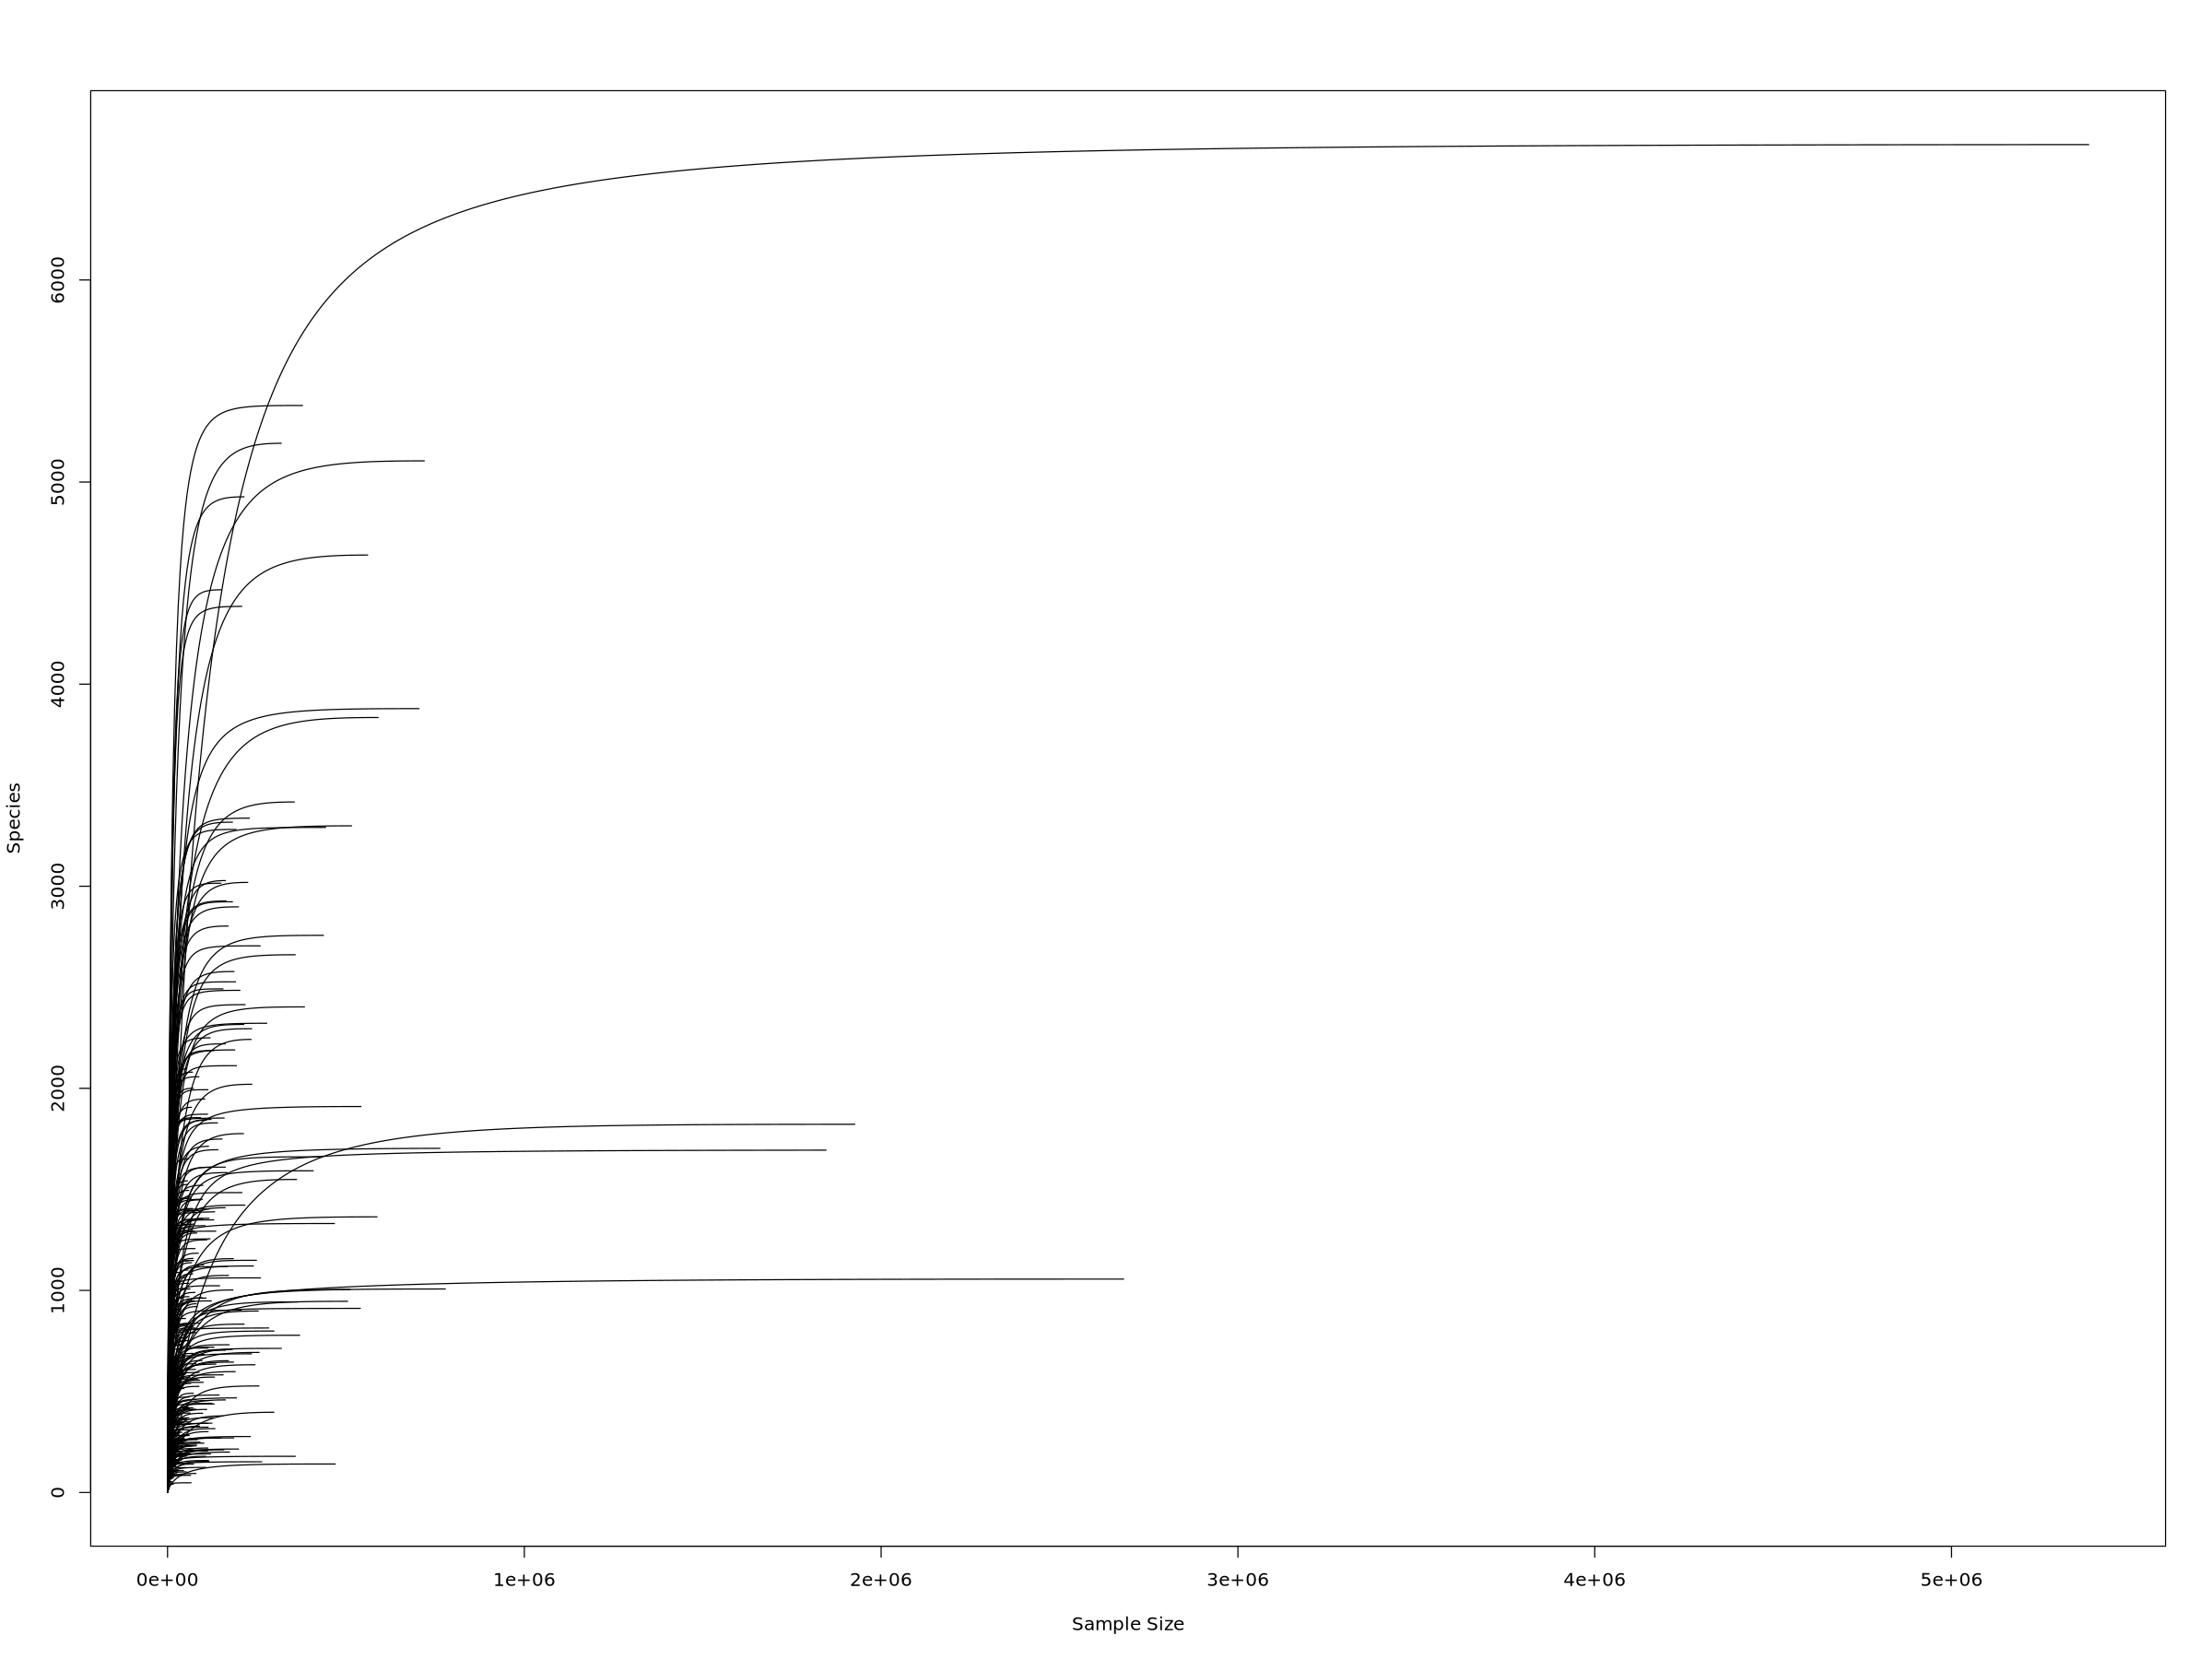

In [54]:
# we will use vegan rarecurve 
otu.rarecurve = rarecurve(otu_df, step = 5000, label = FALSE)

## seq_run_rarefaction_curve

**split ps_prune into 5 seq runs**

In [24]:
ps_1 <- subset_samples(ps_prune, Seq_run == "1")
ps_2 <- subset_samples(ps_prune, Seq_run == "2")
ps_3 <- subset_samples(ps_prune, Seq_run == "3")
ps_4 <- subset_samples(ps_prune, Seq_run == "4")
ps_5 <- subset_samples(ps_prune, Seq_run == "5")

,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATAGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGAGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,GCAAGCGTTGTTCGGAATTACTGGGCGTAAAGGGCGTGTAGGCGGATTATCAAGTTAGGGGTGAAATCCCGGGGCTCAACCTCGGCACTGCCTTTAAGACTGATAATCTAGAGTATGTGAGGGGATAATGGAATACCTAGTGTAGAGGTGAAATTCGTAGATATTAGGTGGAACACCAGTGGCGAAGGCGATTATCTGGCACATTACTGACGCTGAGGCGCGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGGGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,TCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCGCGTAGGCGGTTTGCTAAGTCAGATGTGAAATCCCTGGGCTTAACCTAGGAACTGCATTTGAAACTAGCAAGCTAGAGTATGGTAGAGGTGGGTGGAATTTCAGGTGTAGCGGTGGAATGCGTAGAGATCTGAAGGAACATCAGTGGCGAAGGCGGCTCACTGGGCCATCACTGACGCTGAGGTGCGAAAGCGTGGGT,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATTGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGCGCGTAGGCGGTGTGTTAAGTCGGATGTGAAAGCCCAGGGCTCAACCTTGGAATTGCATCCGATACTGGCACGCTAGAGTGCAGTAGAGGGAGGTGGAATTTCCGGTGTAGCGGTGAAATGCGTAGAGATCGGAAGGAACACCAGTGGCGAAGGCGGCCTCCTGGACTGACACTGACGCTGAGGTGCGAAAGCGTGGGG,GCAAGCGTTGTTCGGATTTACTGGGCGTAAAGGGTGCGTAGGTGGCATGACAAGTCACTTGTGAAATCTCCGAGCTTAACTCGGAACGGTCAAGTGATACTGTTGTGCTAGAGTGCGGGAAGGGCAGCTGGAATTCTTGGTGTAGCGGTGAAATGCGTAGATATCAAGAGGAACACCGGAGGCGAAGGCGAGTTGCTAGACCGACACTGACGCTGAGGCACGAAAGCCAGGGG,GCAAGCGTTATCCGGATTTACTGGGTTTAAAGAGTGCGTAGGCGGCTTCTTAAGTCAGTGGTGAAAGCTTAGCGCTTAACGCTAGAAGTGCCACTGATACTGGGAAGCTTGAGTCAAGAAGAGGTAAGCAGAATTCATAGTGTAGCAGTGAAATGCTTAGATACTATGAGGAATACCAACAGCGAAGGCAGCTTACTGGTCTTGTACTGACGTTGAGGCACGAAAGCGTGGGT,GCGAGCGTTGTTCGGAATTATTGGGCGTAAAGGGCGCGTAGGCGGACGTGCAAGTCTGGTGTGAAAGACCGCAGCTCAACTGCGGGCACGCGCTGGAAACTGTATGTCTTGAATCCTTGAGGGGGAACTGGAATTCCTGGTGTAGGGGTGAAATCTGTAGATATCAGGAAGAACACCGGTGGCGAAGGCGAGTTCCTGGCAAGTGATTGACGCTGAGGCGCGAAAGCGTGGGG,⋯,GCAAGCGTTATCCGGAATGACTGGGTGTAAAGAGCATGTAGGCGGGGATGCAAGTCAGATGTGAAATCTTAAGGCTCAACCTTATTGAGCATCTGAAACTGTGTTTCTTGAGTACTGGAGAGGAAAGTGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTGGCGAAGGCGGCTTTCTGGACAGTAACTGACGCTGAGATGCGAAAGTGTGGGT,GCAAGCGTTATTCGGAATTACTGGGCGTAAAGGGCGCGCAGGCGGCCCGTTAAGTGAGAAGTGAAAGCCCCGGGCTCAACCCGGGAATTGCTTCTCATACTGGCAGGCTAGAGGATGGGAGAGGAAAATGGAATTCCCGGTGTAGCGGTGAAATGCGTAGAGATCGGGAGGAACACCAGTGGCGAAGGCGGTTTTCTGGACCATTACTGACGCTGAGGCGCGAAAGCGTGGGG,GCAAGCGTTGTTCGGATTCATTGGGTGTAAAGGGTATGTAGGTGTCCTGCCAAGTCTTTCTTGAAATACTCTGGCTCAACCAGAGACCCGGGAGAGAAACTGGCAGGATTGAGTACTGGAGAGGAAAGCGGAATTCCCGGTGTAAGGGTGAAATCTGTAGATATCGGGAGGAACACCAGTGGCGAAAGCGGCTTTCTGGCCAGATACTGACACTGAAATACGAAAGCAAGGGG,GCGAGCGTTAATCGGAATCACTGGGCGTAAAGGGCGCGTAGGCGGTTCGATAAGTCGGGTGTGAAAGCCCCGGGCTCAACCCGGGAACTGCACTCGATACTGTCGAGCTTGAGTGTGGTAGAGGGGAGCGGAATTCCCGGTGTAGCGGTGAAATGCGTAGATATCGGGAAGAACACCAGTGGCGAAGGCGGCTCCCTGGACCAACACTGACGCTGAGGCGCGAAAGCGTGGGG,ACGAACGTTATTCGGAATTACTGGGCTTAAAGGGTGCGCAGGCGGTCTGGCGGGTTGGGTGTGAAAGCCCTCGGCTCAACCGGGGAACTGCGCTCAATACCACCAGGCTCGAGCGAGATAGAGGTGAGCGGAACTACGGGTGGAGCGGTGGAATGCGTTGATATCCGTGGGAACACCGGCGGCGAAAGCGGCTCACTGGGTCTCTGCTGACGCTCAGGCACGAAAGCTAGGGG,GGTGCGGTAAGTGAGGTGTGAAATCCCCCGGCTCAACCGAGGAATTGCGCTTCATACTGCCGTGCTAGAGGGAGACAGAGGTAAGCGGAACTGATGGTGGAGCGGTGAAATGCGTTGATATCATCAGGAACACCGGTGGCGAAAGCGGCTTACTGGGTCTCTTCTGACGCTGAGGCACGAAAGCTAGGGTAGCGAACGGGATTAGATACCCGGGTAGTCC,GCAAGCGTTATTCGGAATTATTGGGCGTAAAGGGTCTGTAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATAGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATCCTGACACTCAGATGCGACAGCGTGGGG,GGTGAGTCAAGTTACCTATGAAAGATACAGGCT

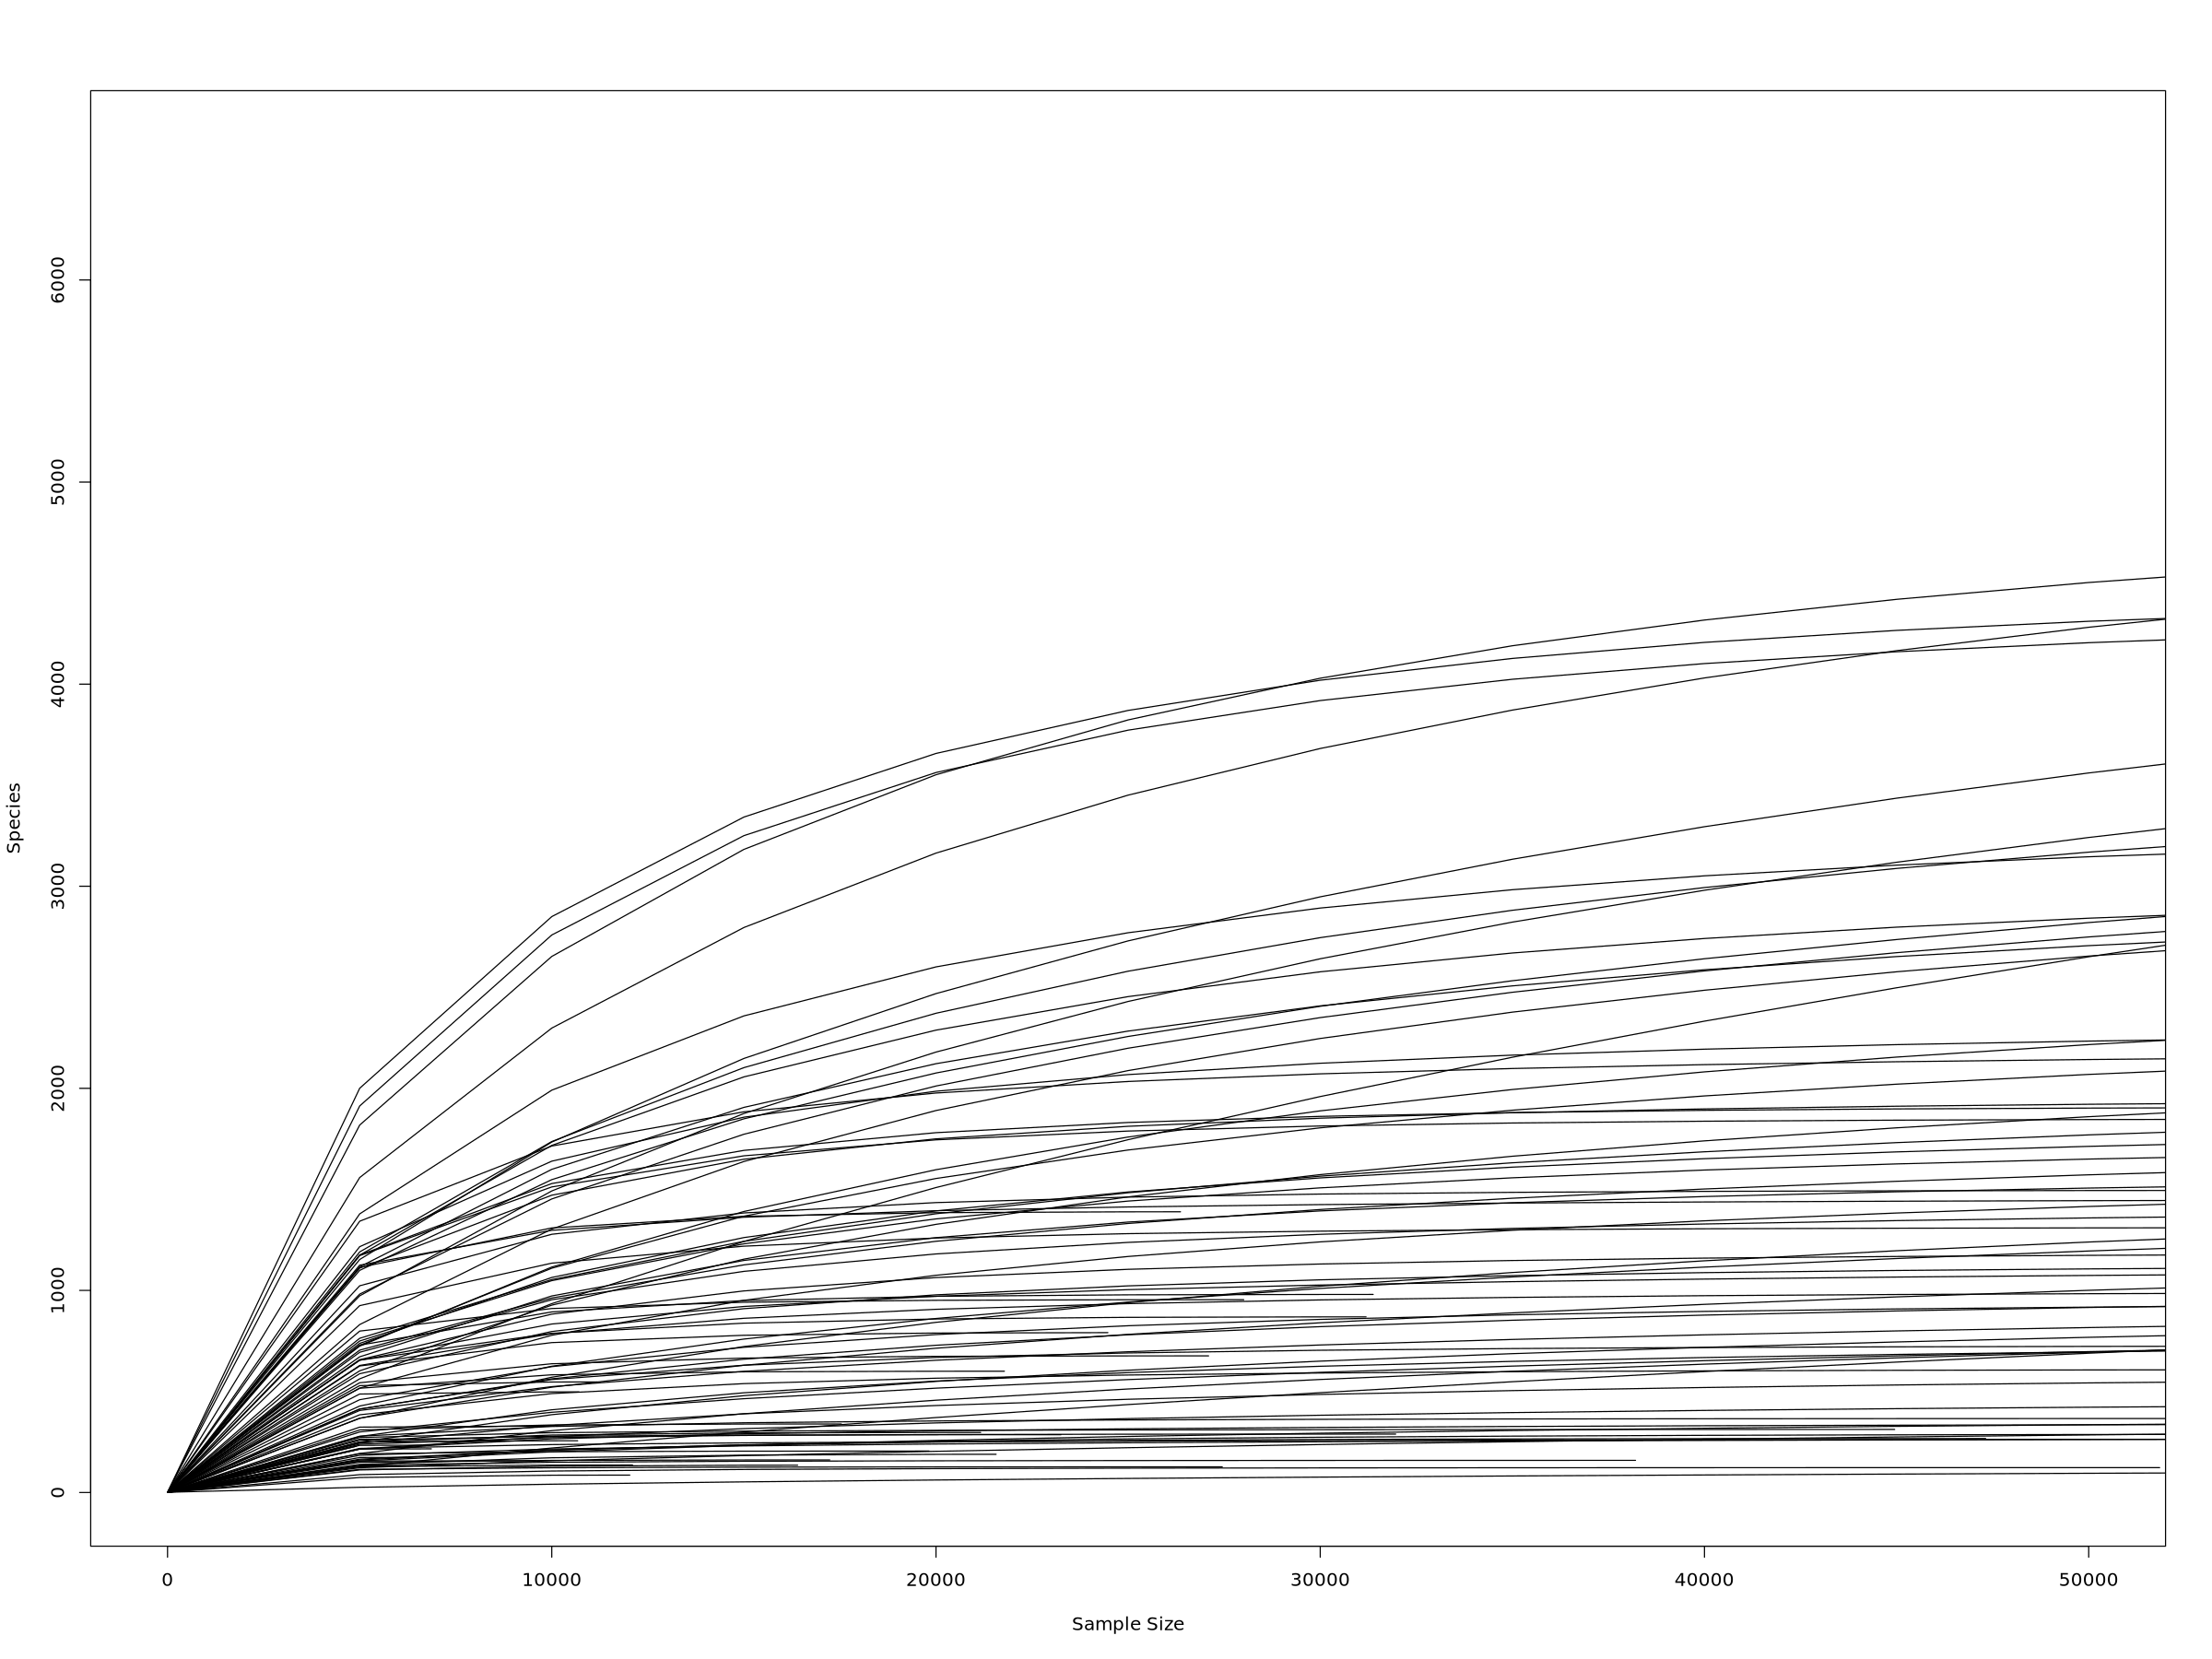

In [25]:
otu.1 = as.data.frame(otu_table(ps_1))
head(otu.1)
# we will use vegan rarecurve 
otu.1curve = rarecurve(otu.1, step = 5000, label = FALSE, xlim = c(0, 50000))

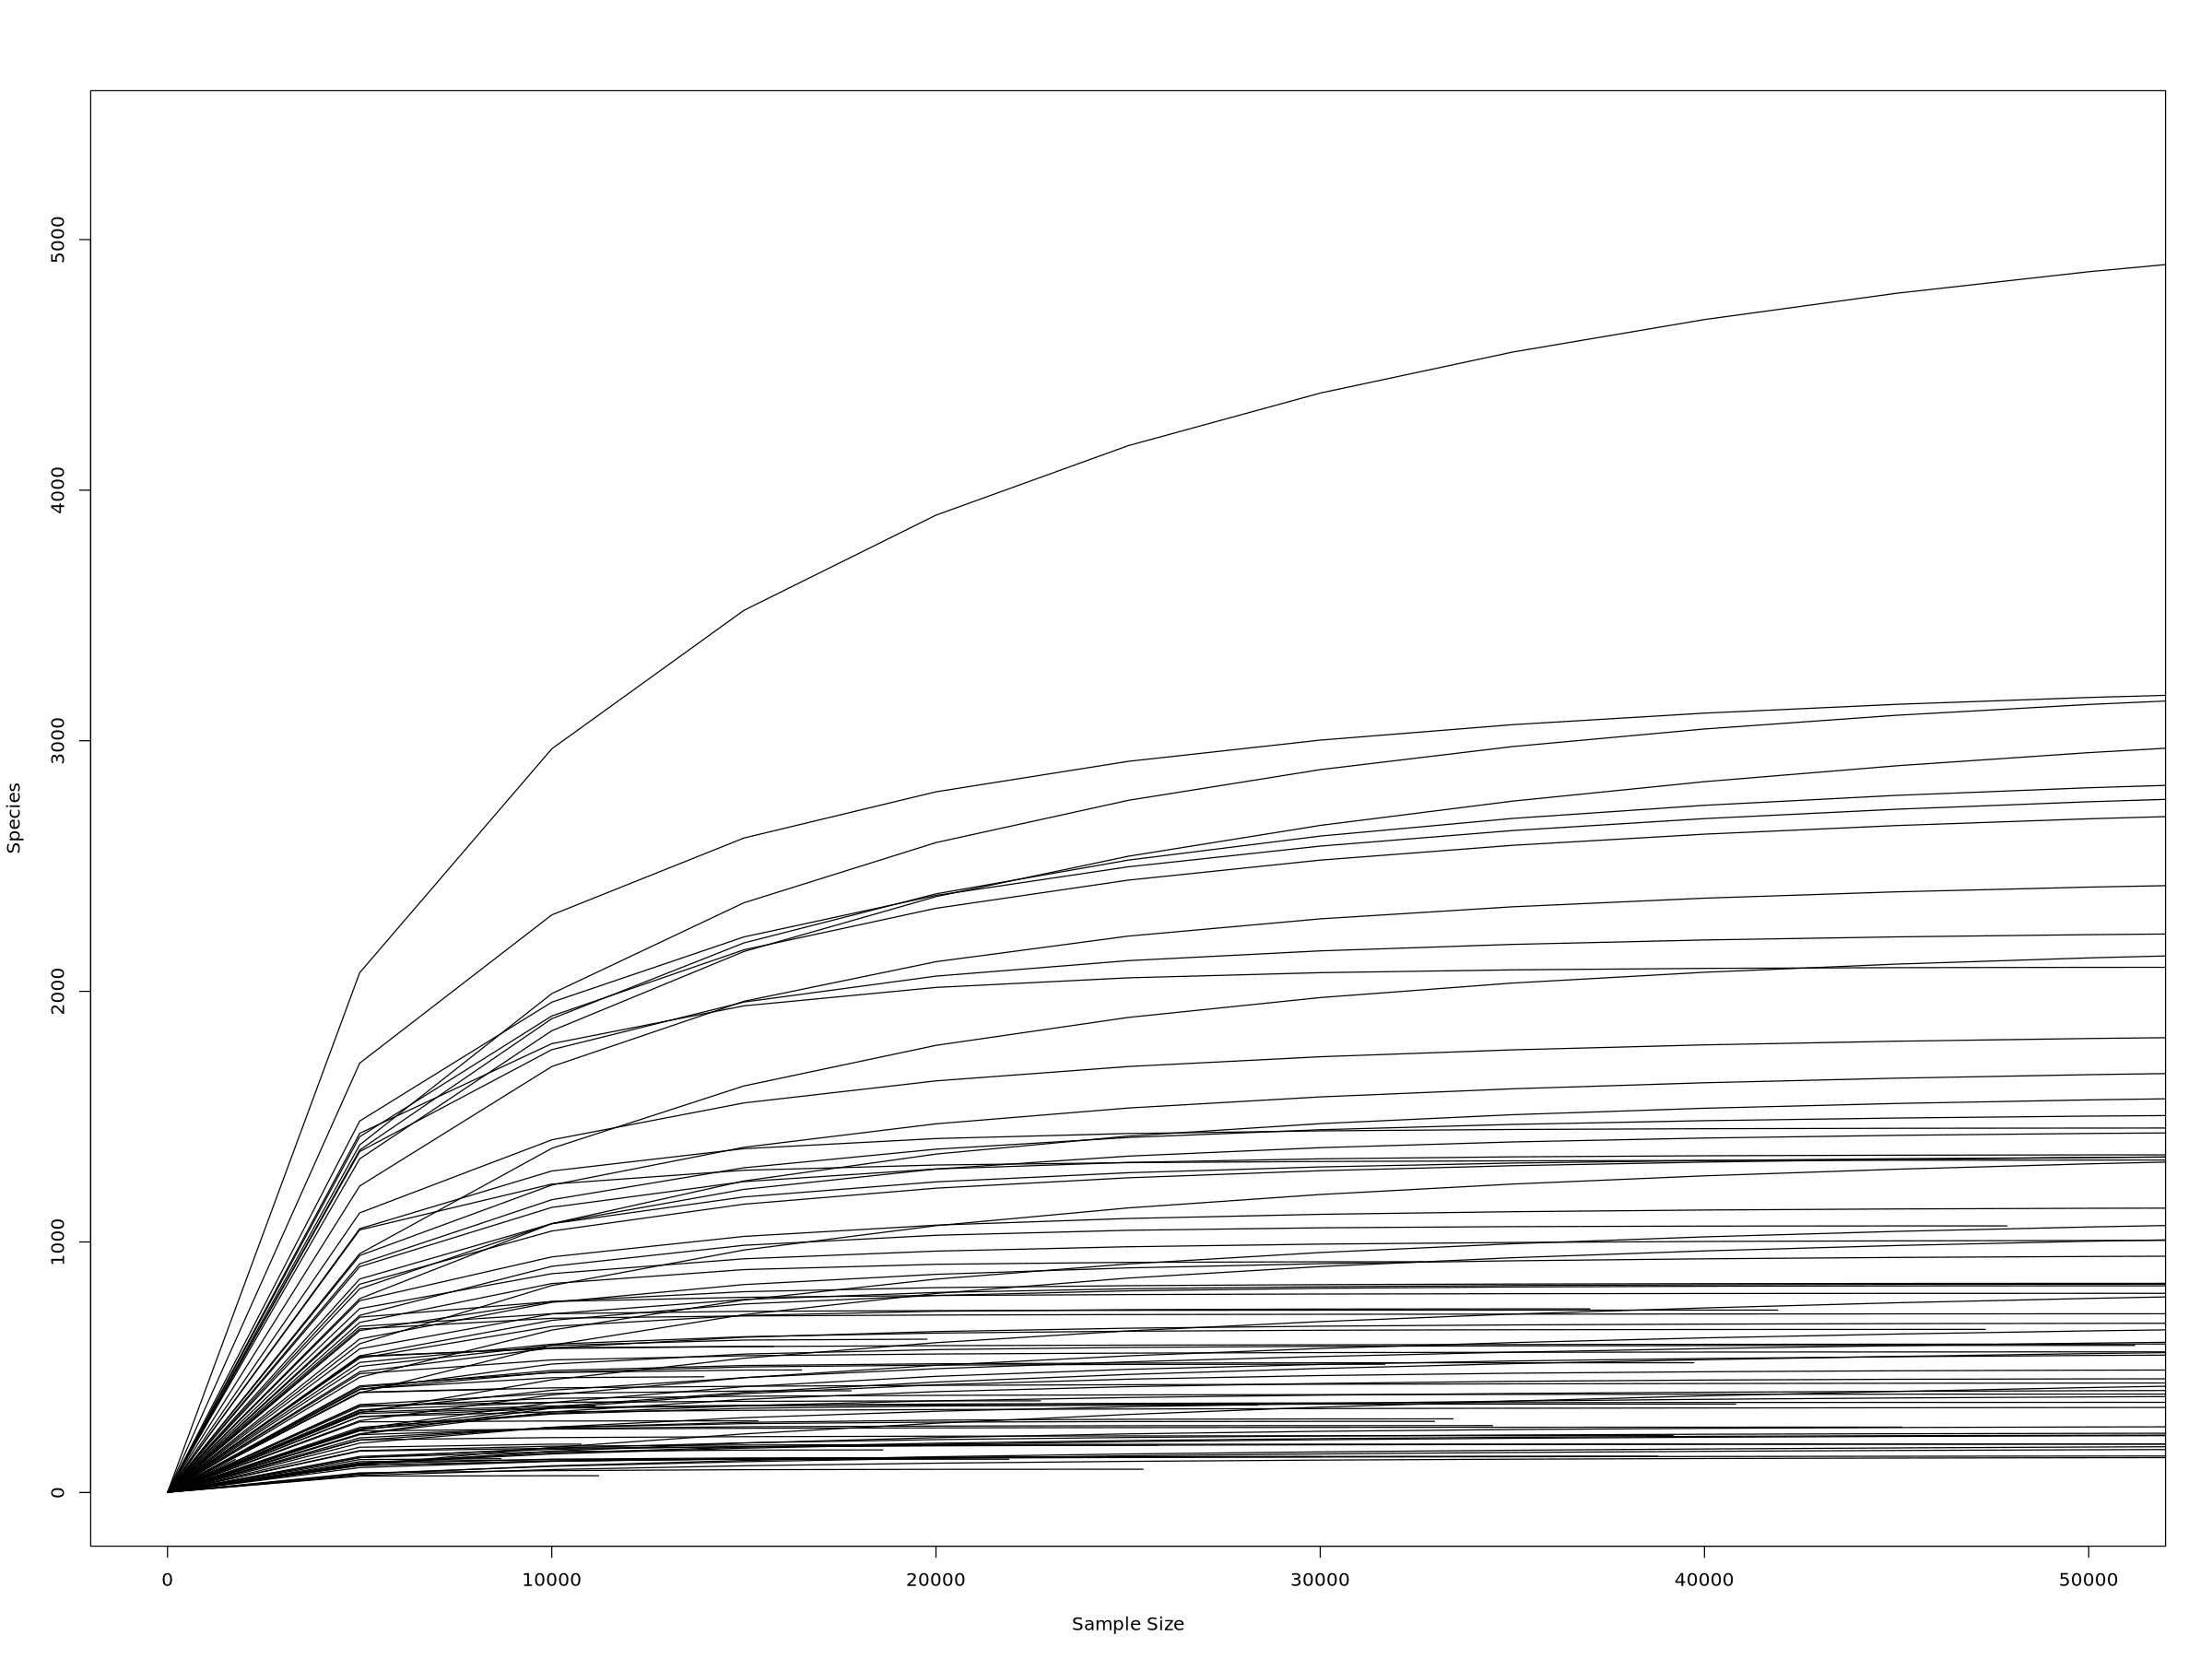

In [26]:
otu.2 = as.data.frame(otu_table(ps_2))

# we will use vegan rarecurve 
otu.2curve = rarecurve(otu.2, step = 5000, label = FALSE, xlim = c(0, 50000))

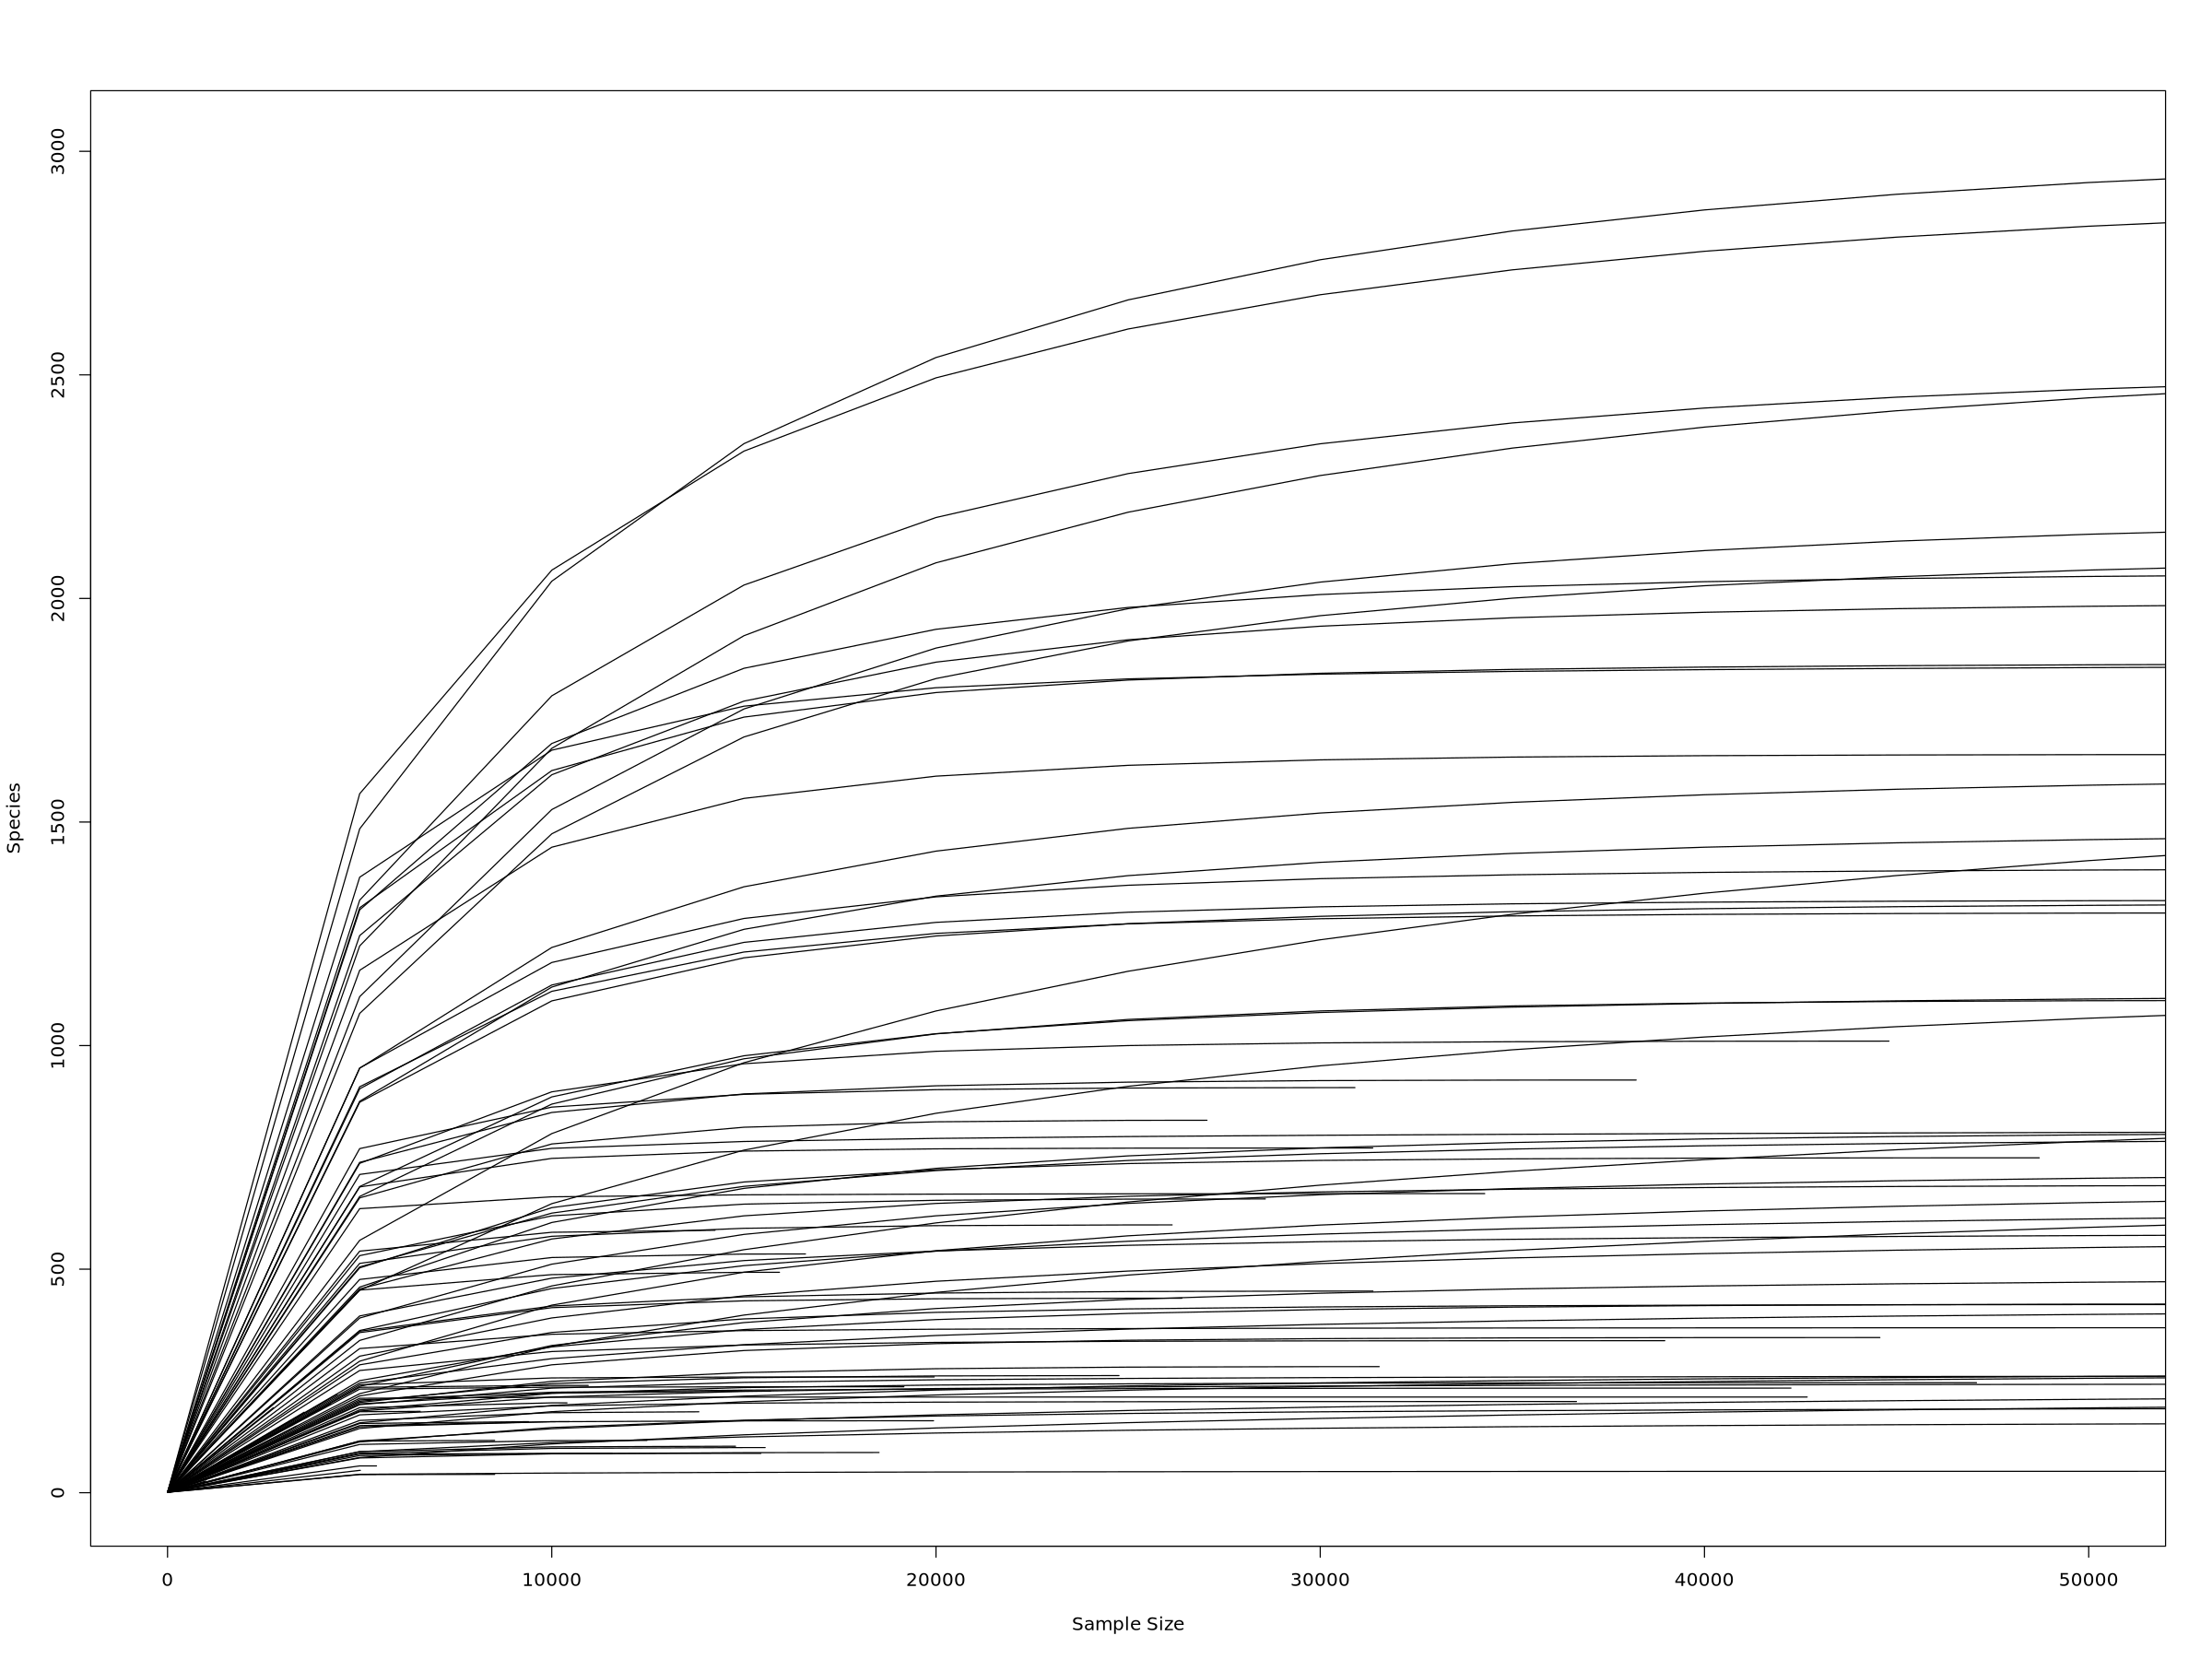

In [27]:
otu.3 = as.data.frame(otu_table(ps_3))

# we will use vegan rarecurve 
otu.3curve = rarecurve(otu.3, step = 5000, label = FALSE, xlim = c(0, 50000))

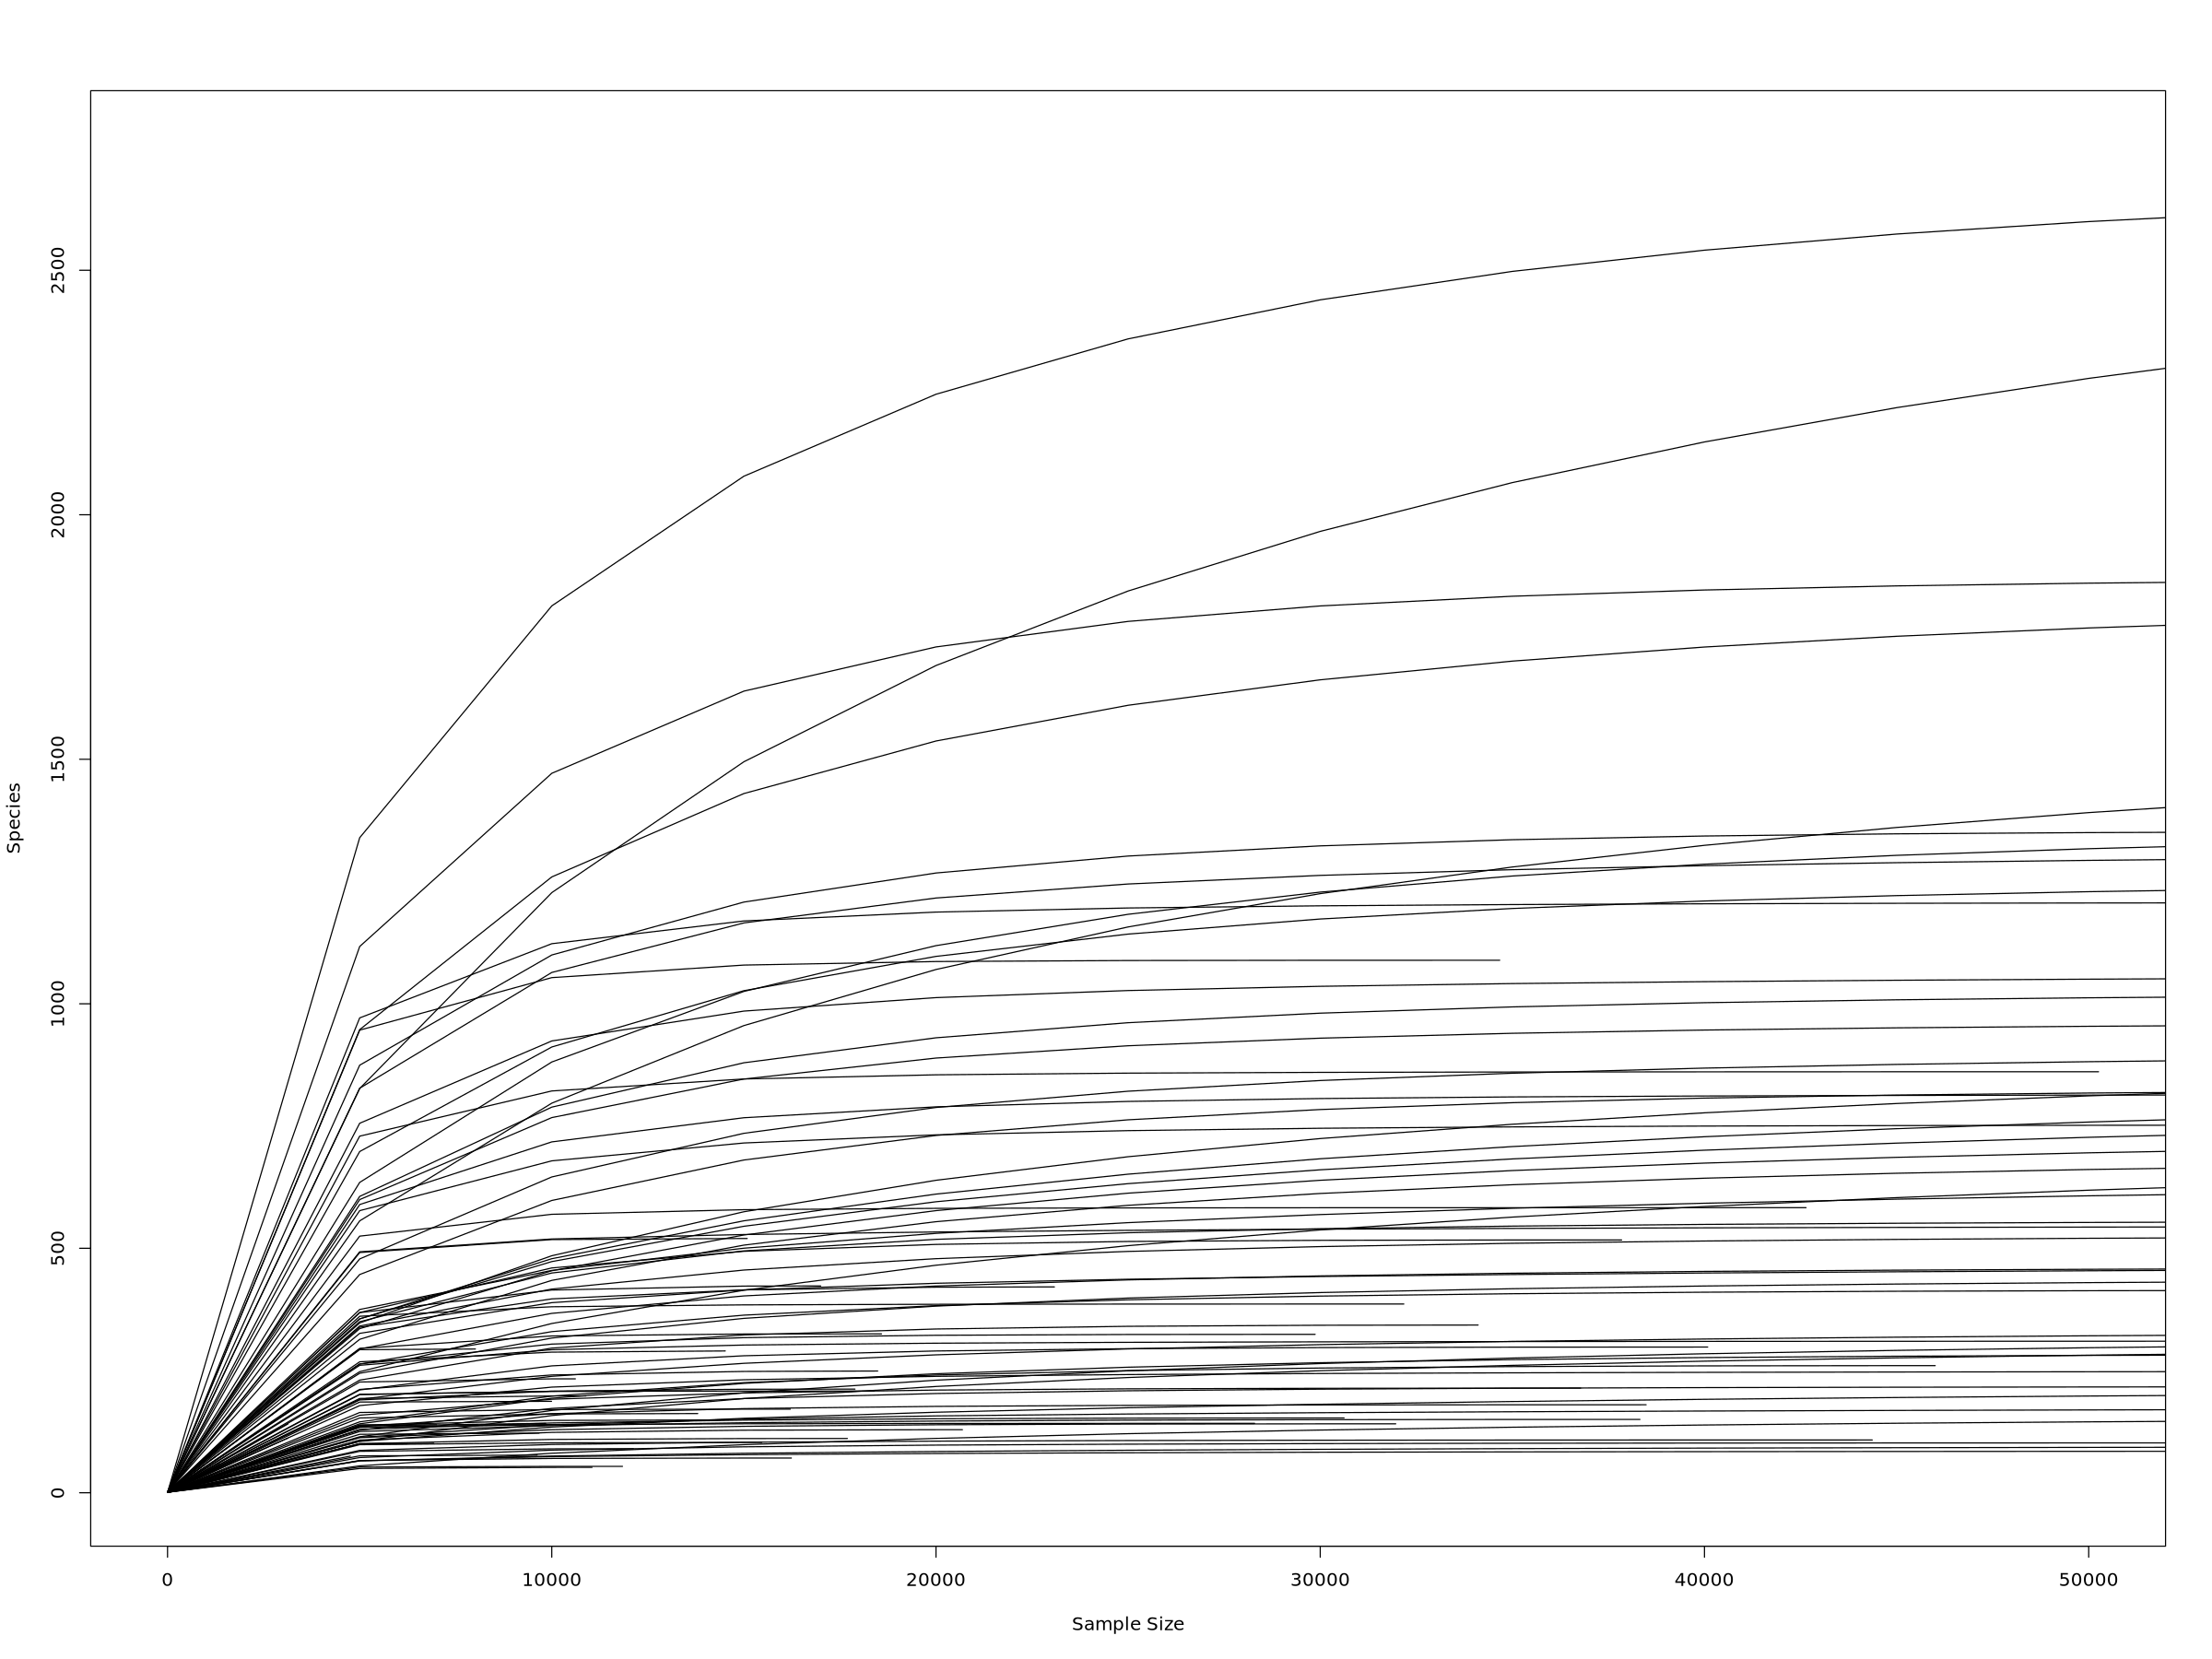

In [28]:
otu.4 = as.data.frame(otu_table(ps_4))

# we will use vegan rarecurve 
otu.4curve = rarecurve(otu.4, step = 5000, label = FALSE, xlim = c(0, 50000))

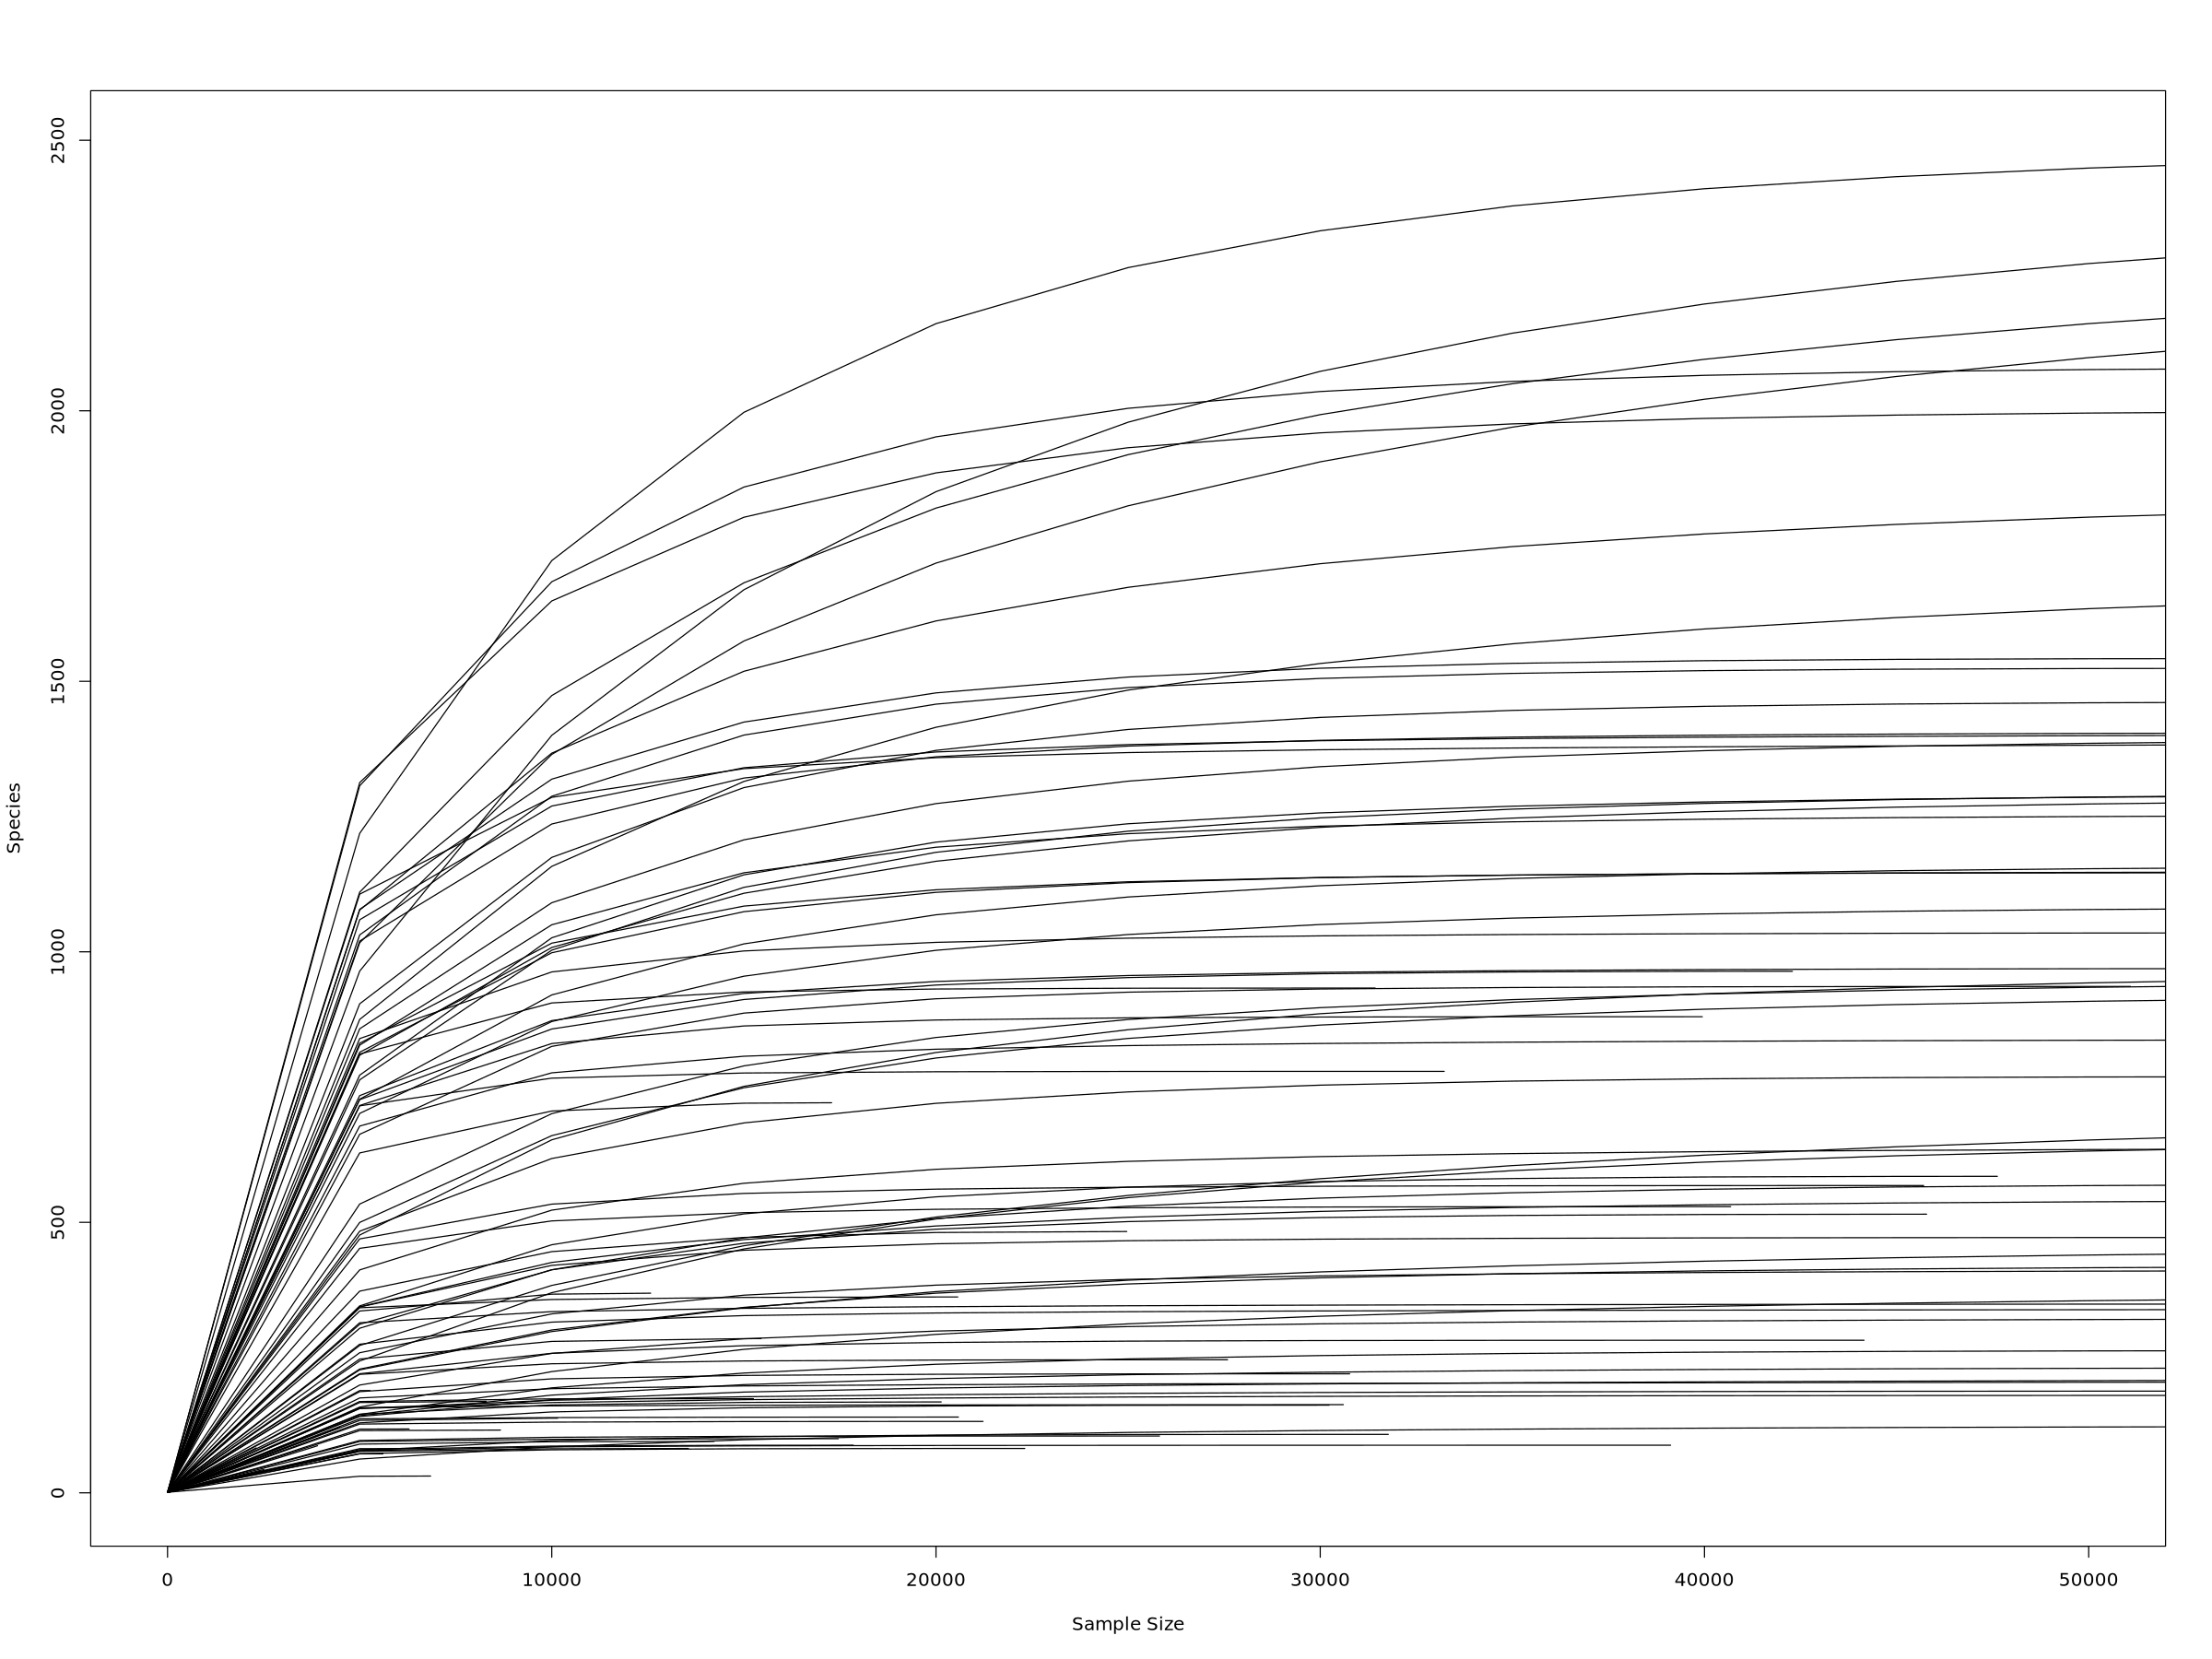

In [30]:
otu.5 = as.data.frame(otu_table(ps_5))

# we will use vegan rarecurve 
otu.5curve = rarecurve(otu.5, step = 5000, label = FALSE, xlim = c(0, 50000))

## rarefaction_curve_ps_no1
- genrating a rarefaction curve for ps_16S without run1
- hopefully this will show that more samples were successful outside of run1

In [62]:
#remove seq run1
ps_no1 <- subset_samples(ps_prune, Seq_run != "1")
ps_no1

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46551 taxa and 384 samples ]
sample_data() Sample Data:       [ 384 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 46551 taxa by 6 taxonomic ranks ]

In [63]:
# otu_table into dataframe
otu.no1 = as.data.frame(otu_table(ps_no1))

In [64]:
## vegan rarefy and rrarefy functions
rarefy(otu.no1, min_reads) %>%
as_tibble(rownames="SampleID")

Warning message in rarefy(otu.no1, min_reads):
“requested 'sample' was larger than smallest site maximum (68)”


SampleID,value
<chr>,<dbl>
Negative,36.00000
022024_BEL_CBC_T2_812_PAST,29.79916
112023_BEL_CBC_T1_274_PAST,317.01493
092023_BEL_CBC_T3_174_OFAV,79.31180
062019_BEL_CBC_T2_17_SSID,153.40411
022024_BEL_CBC_T4_870_MCAV,47.79116
042024_BEL_CBC_T4_1044_PSTR,237.77539
022024_BEL_CBC_T3_848_MCAV,84.82706
122023_BEL_CBC_T4_540_MCAV,192.71603


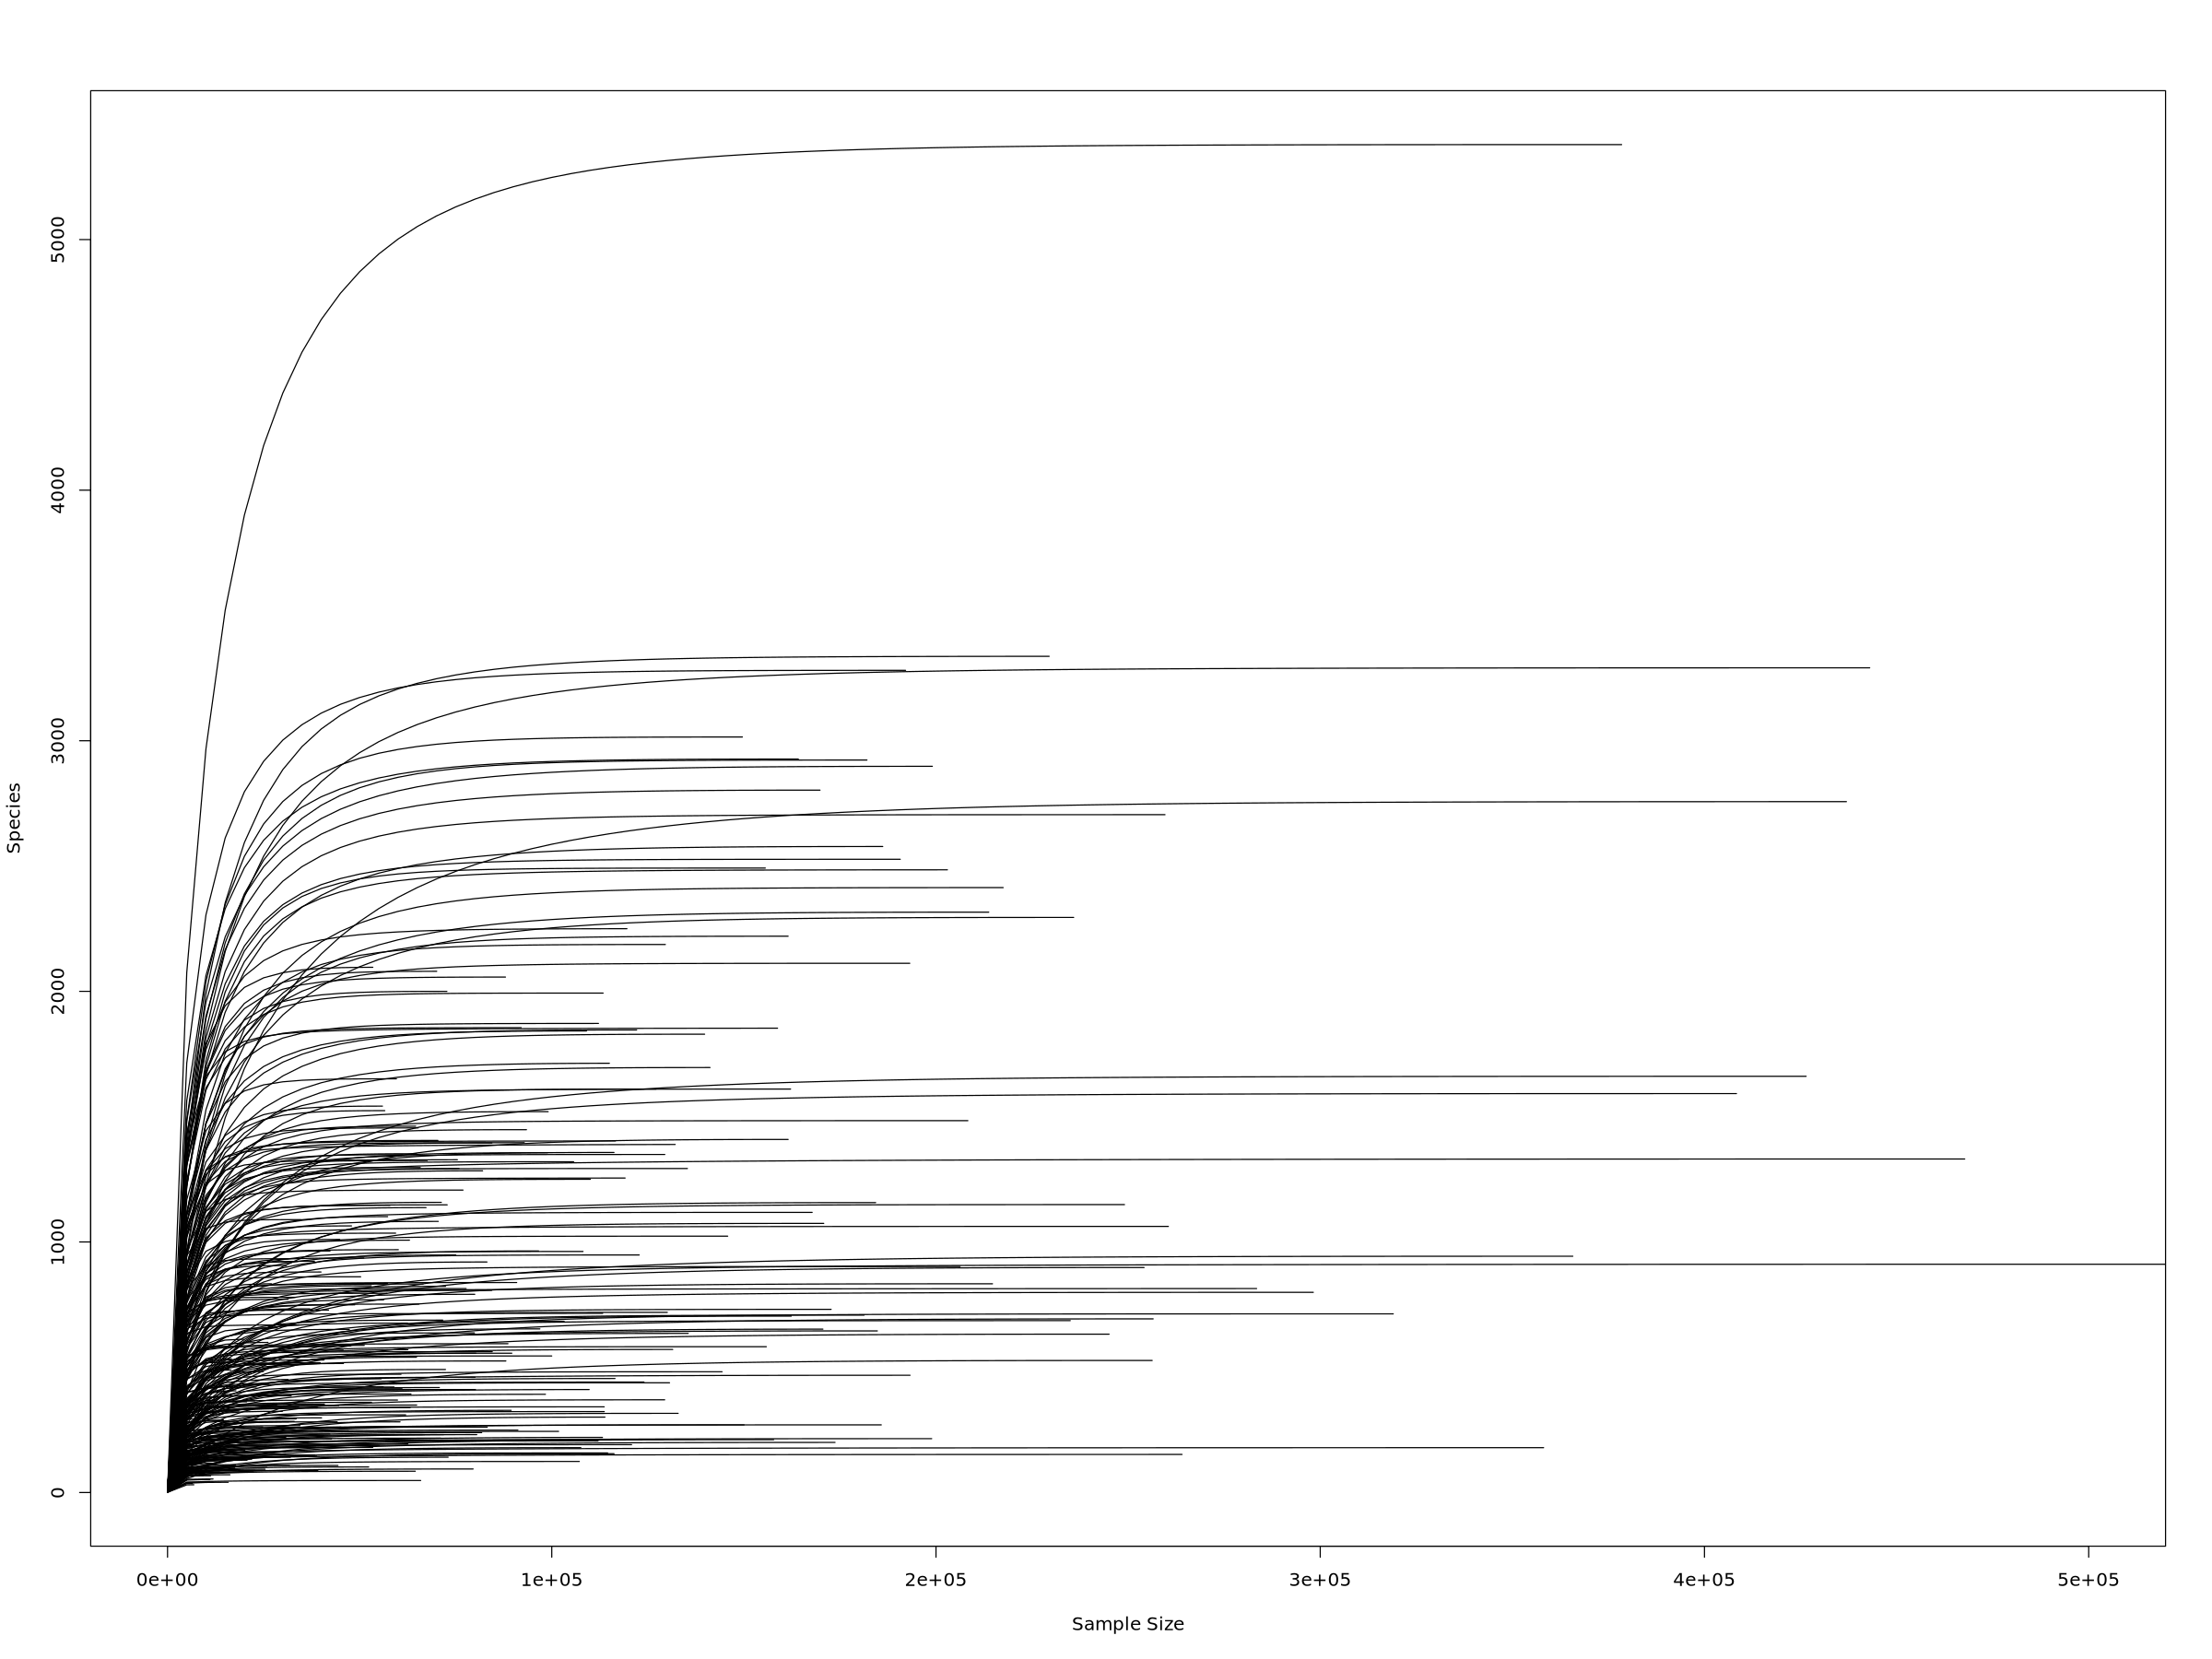

In [65]:
#plot rarefaction curve

# we will use vegan rarecurve zooming in to 500K
# Zoom in directly using the xlim argument

otu.rarecurve.no1 = rarecurve(otu.no1, step = 5000, label = FALSE, xlim = c(0, 500000))

### figure notes
- this rarefaction curve shows that as the number of reads within each sample (x) increases, the number of species (ASV) identified increased until an upper limit is reached.


## species_rarefaction_curve_ps_no1
-(not seq run 1) to parse out which samples had successful sequencing depths
### notes:
- xlim (0,50K) enables me to see that some samples do not pass rarafaction curve test
- **species plots**
- some samples in every species did not pass rarefaction curves

In [66]:
ps_past_no1 <- subset_samples(ps_no1, Species == "PAST")
ps_mcav_no1 <- subset_samples(ps_no1, Species == "MCAV")

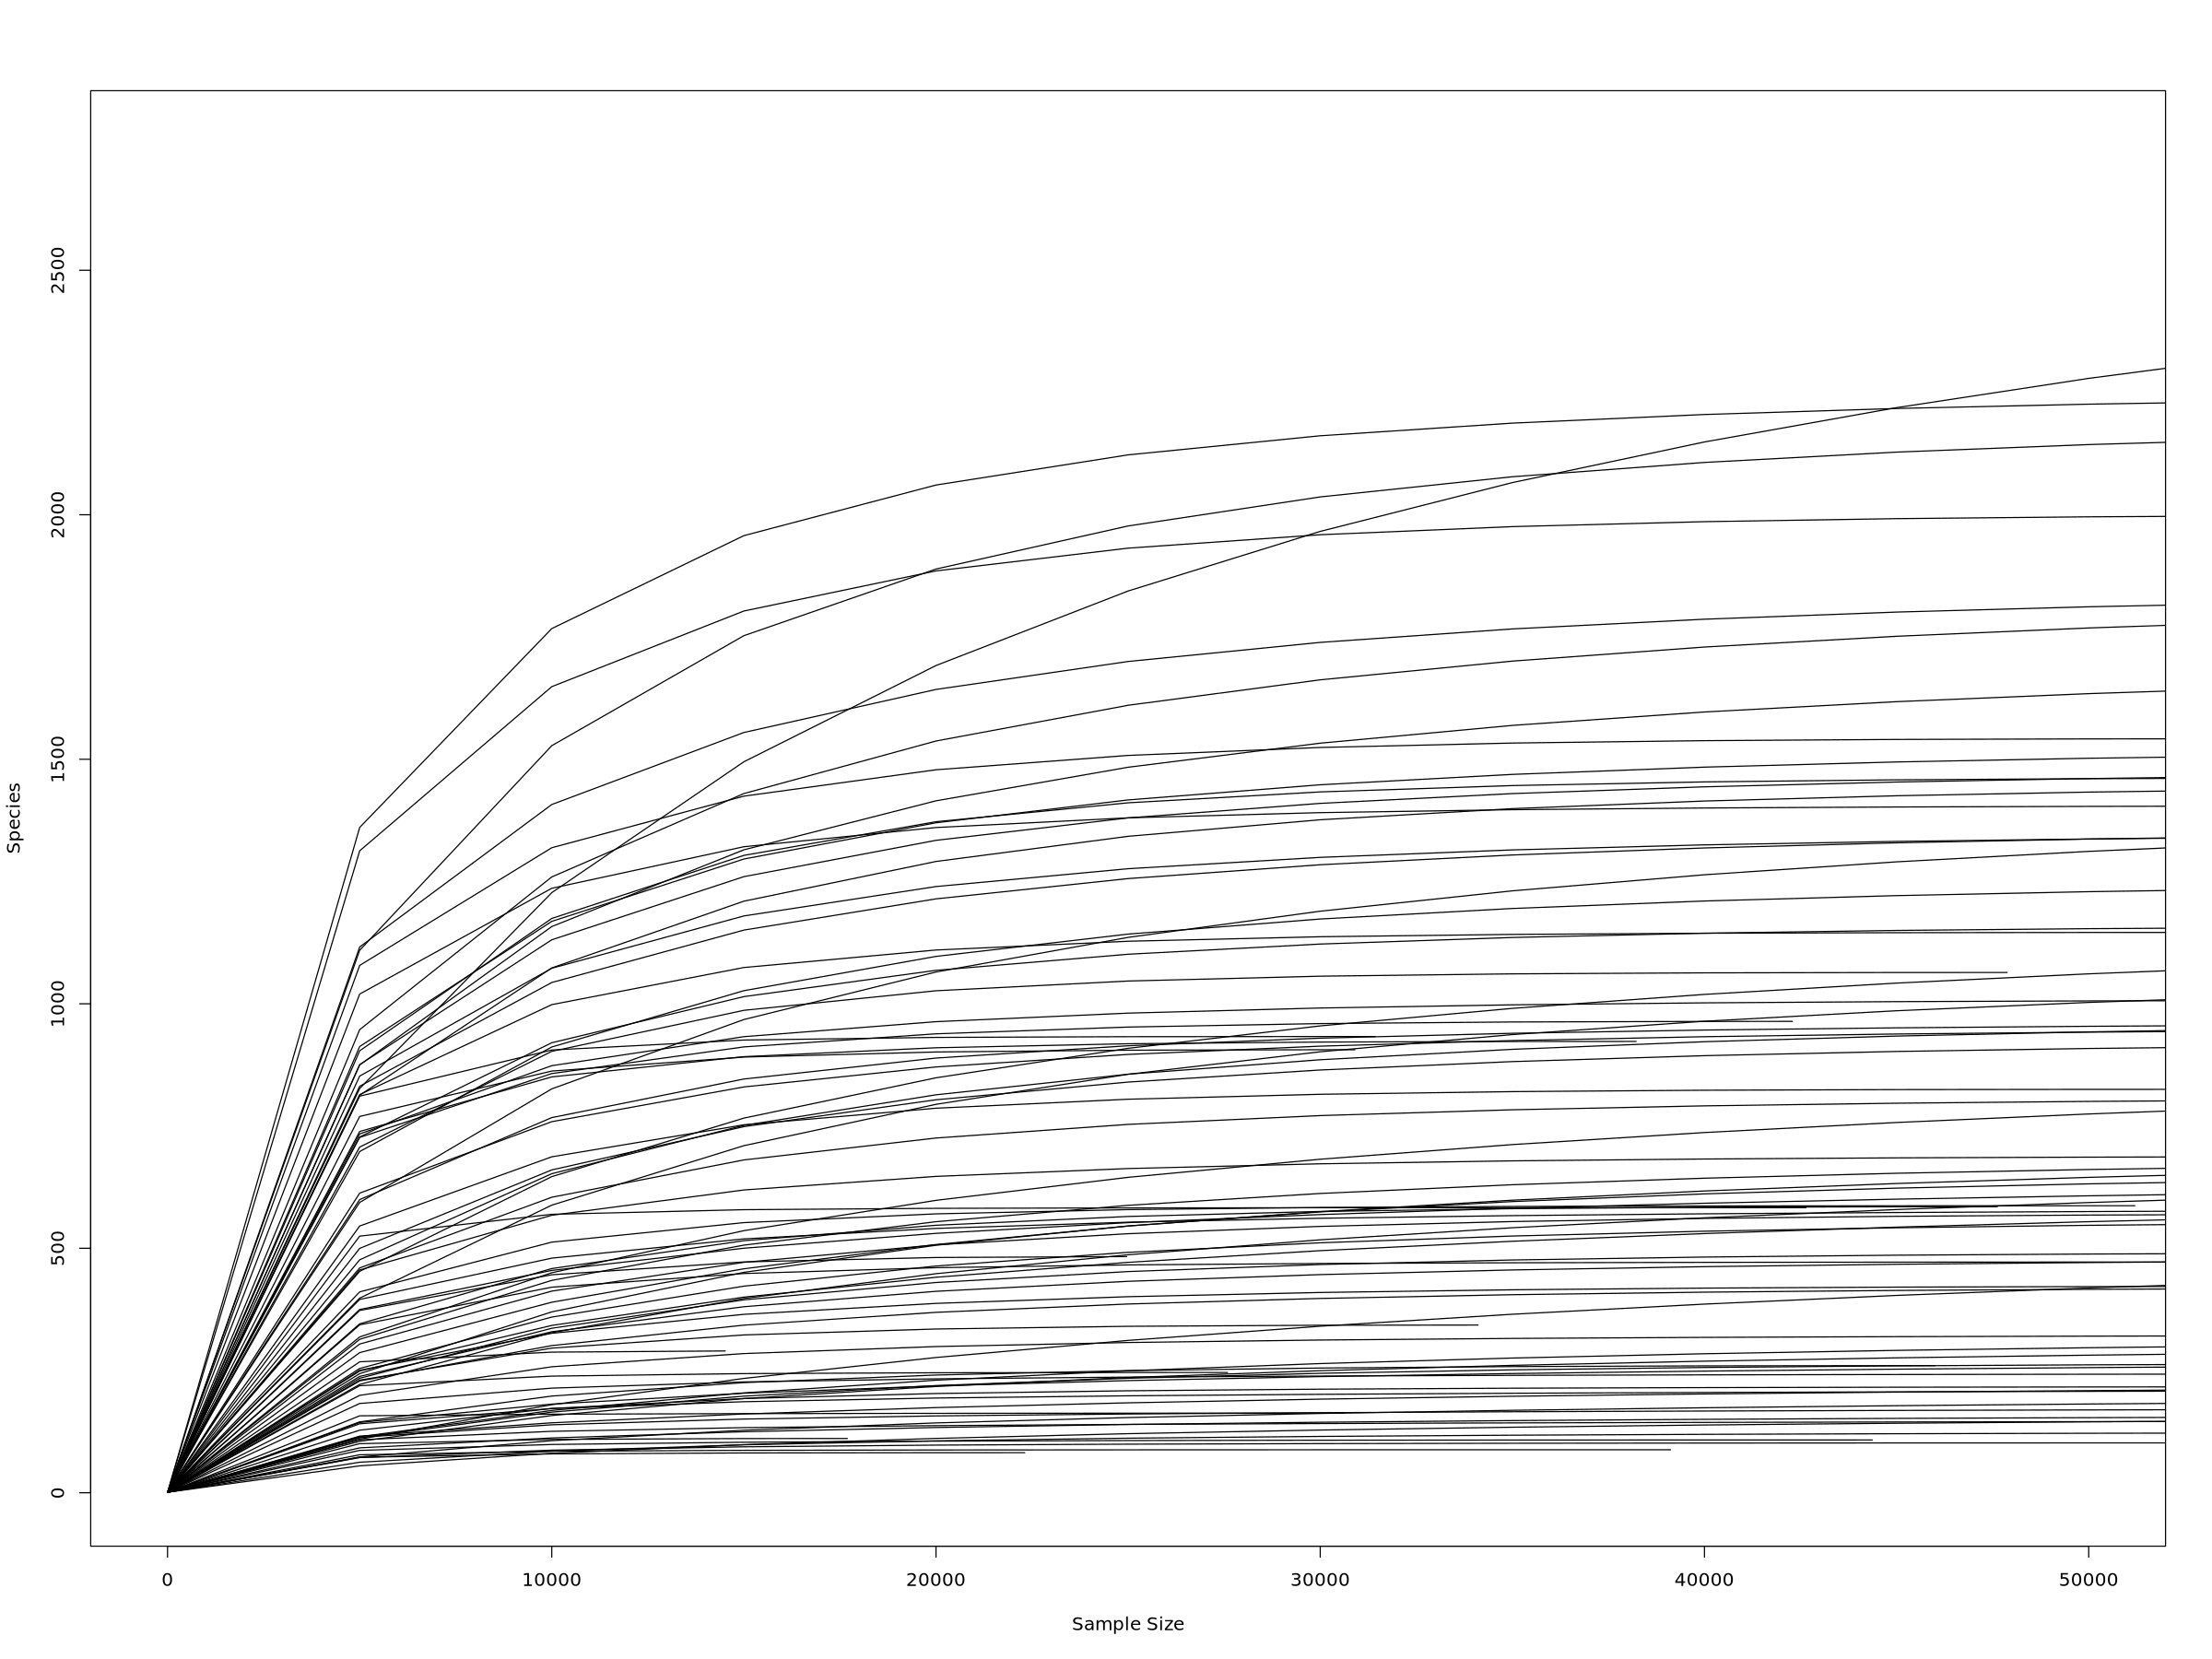

In [67]:
otu.past.no1 = as.data.frame(otu_table(ps_past_no1))

# we will use vegan rarecurve zooming in to 500K
# Zoom in directly using the xlim argument

otu.pastcurve.no1 = rarecurve(otu.past.no1, step = 5000, label = FALSE, xlim = c(0, 50000))

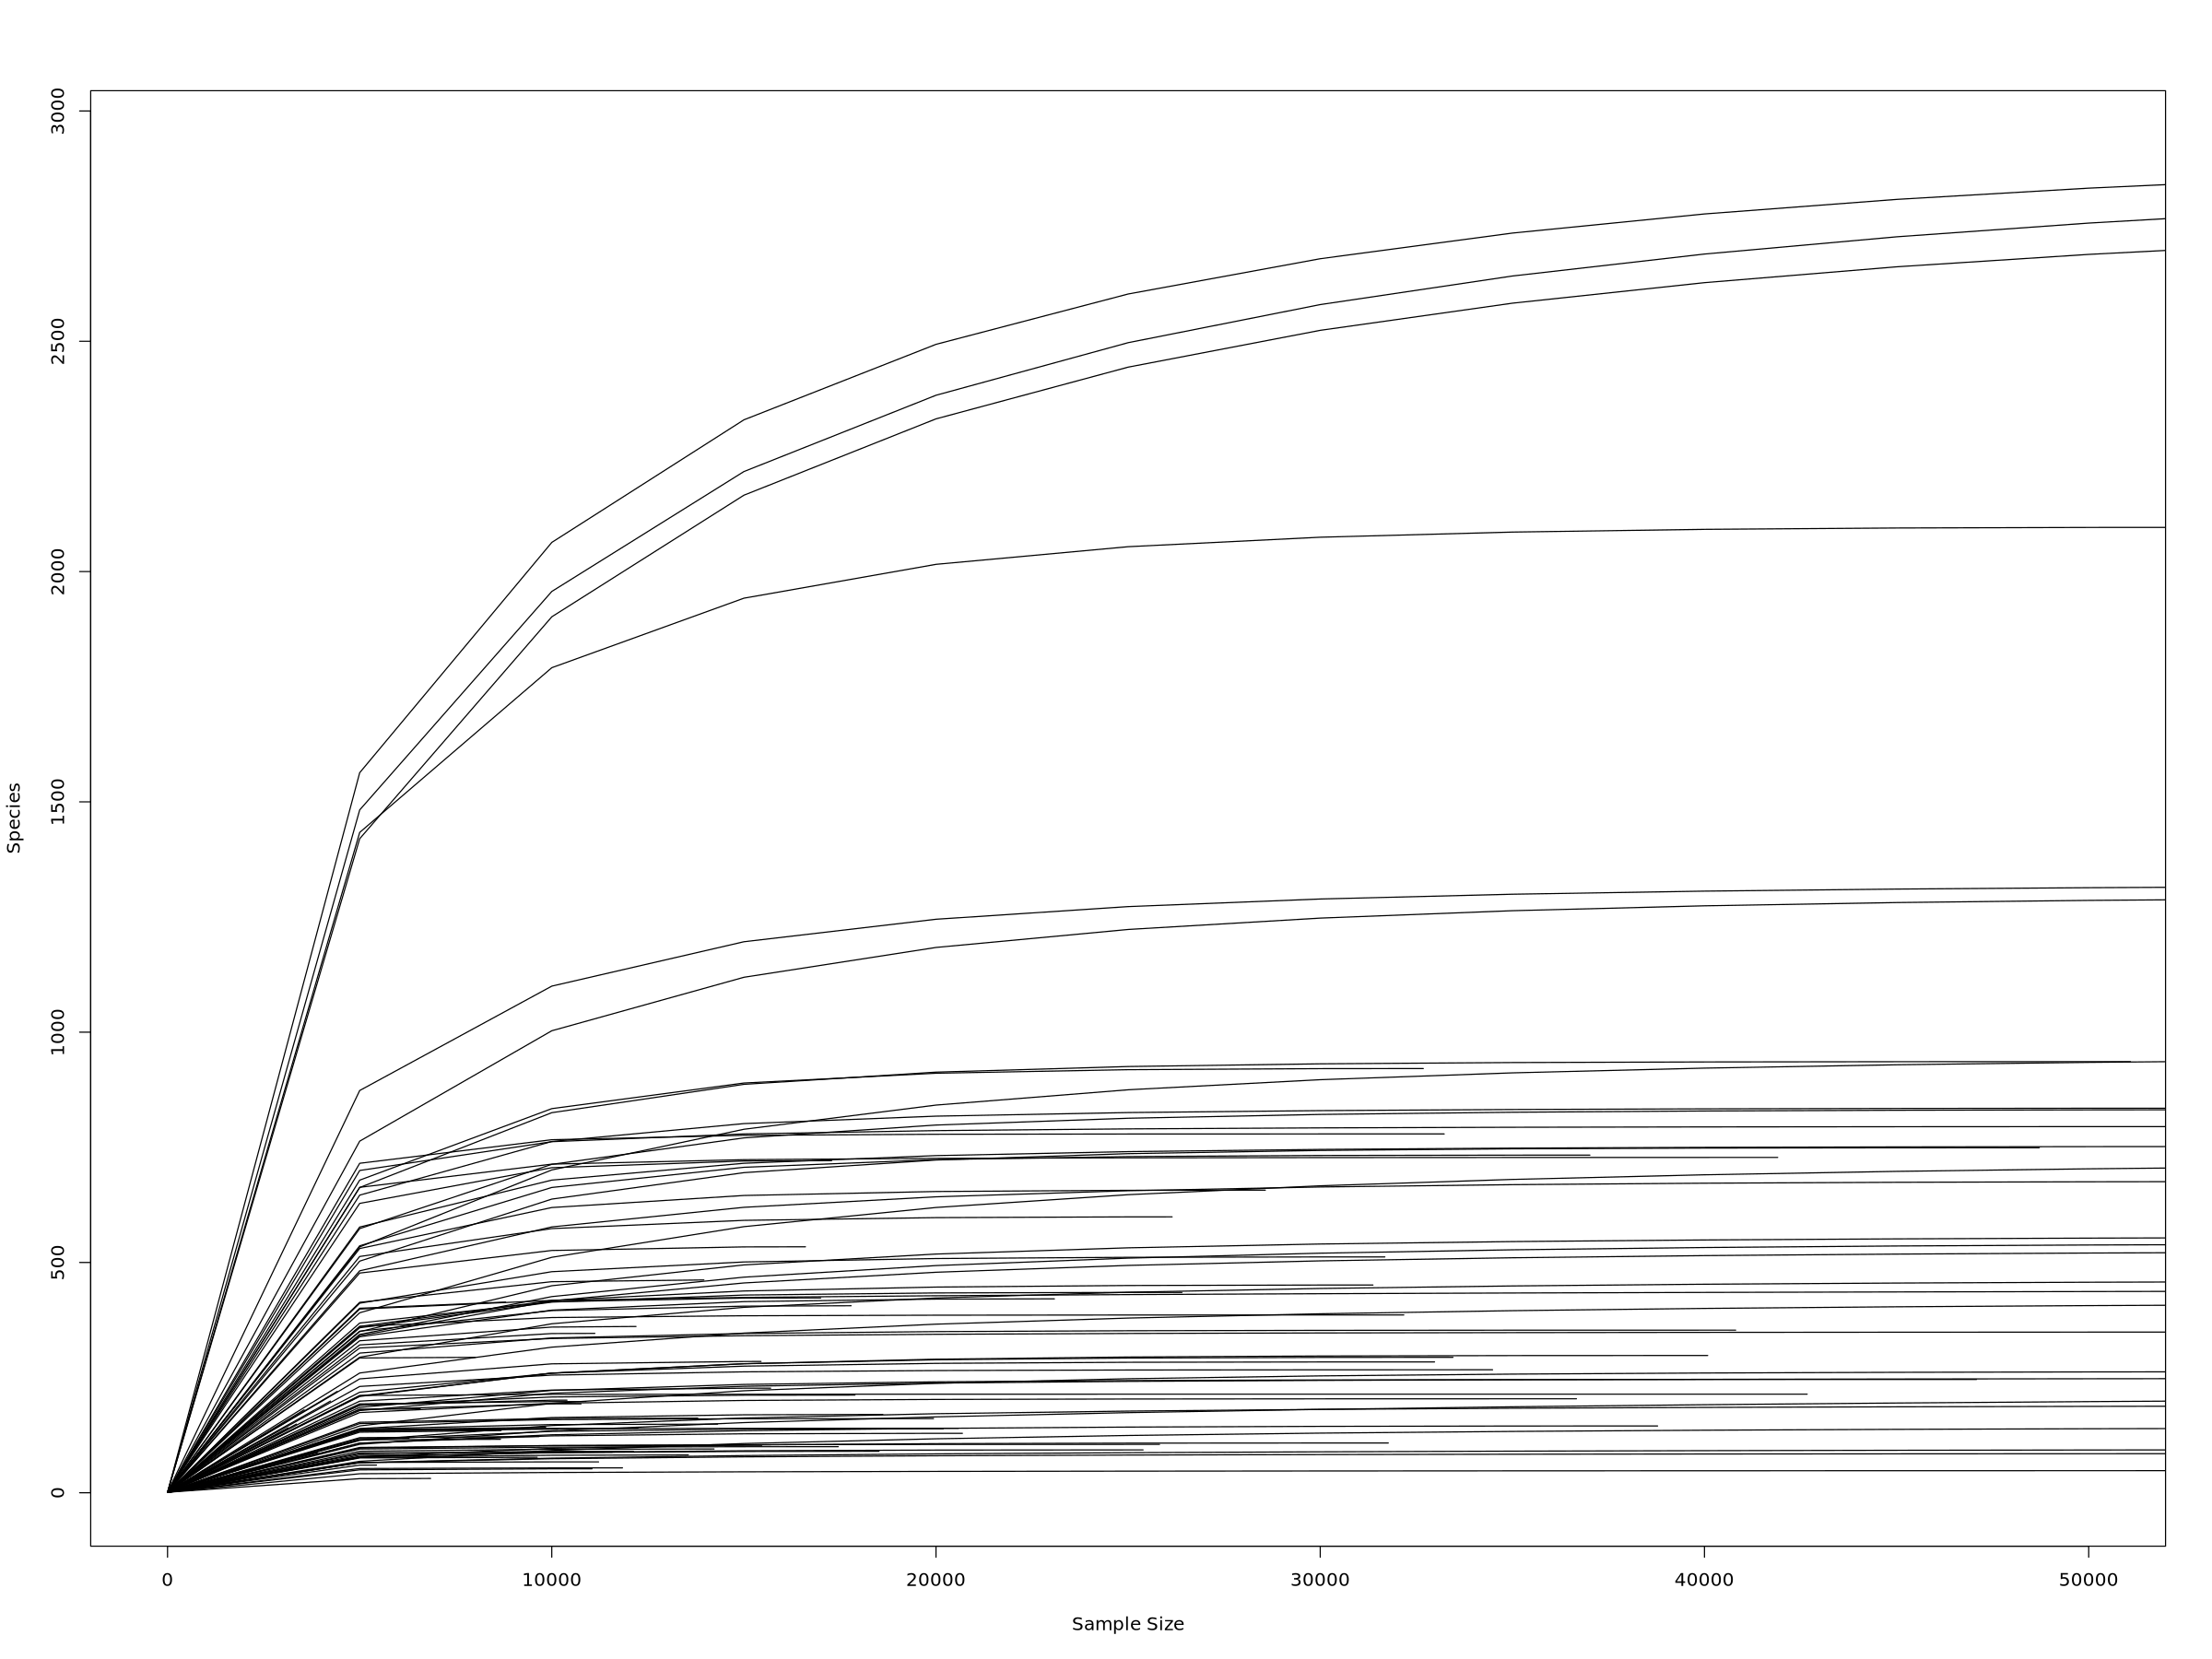

In [68]:
otu.mcav.no1 = as.data.frame(otu_table(ps_mcav_no1))

# we will use vegan rarecurve zooming in to 500K
# Zoom in directly using the xlim argument

otu.mcavcurve.no1 = rarecurve(otu.mcav.no1, step = 5000, label = FALSE, xlim = c(0, 50000))

# filtering_ps_prune_for_outliers

## filtering_threshold
- finding my ideal threshold (its 10K reads)

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


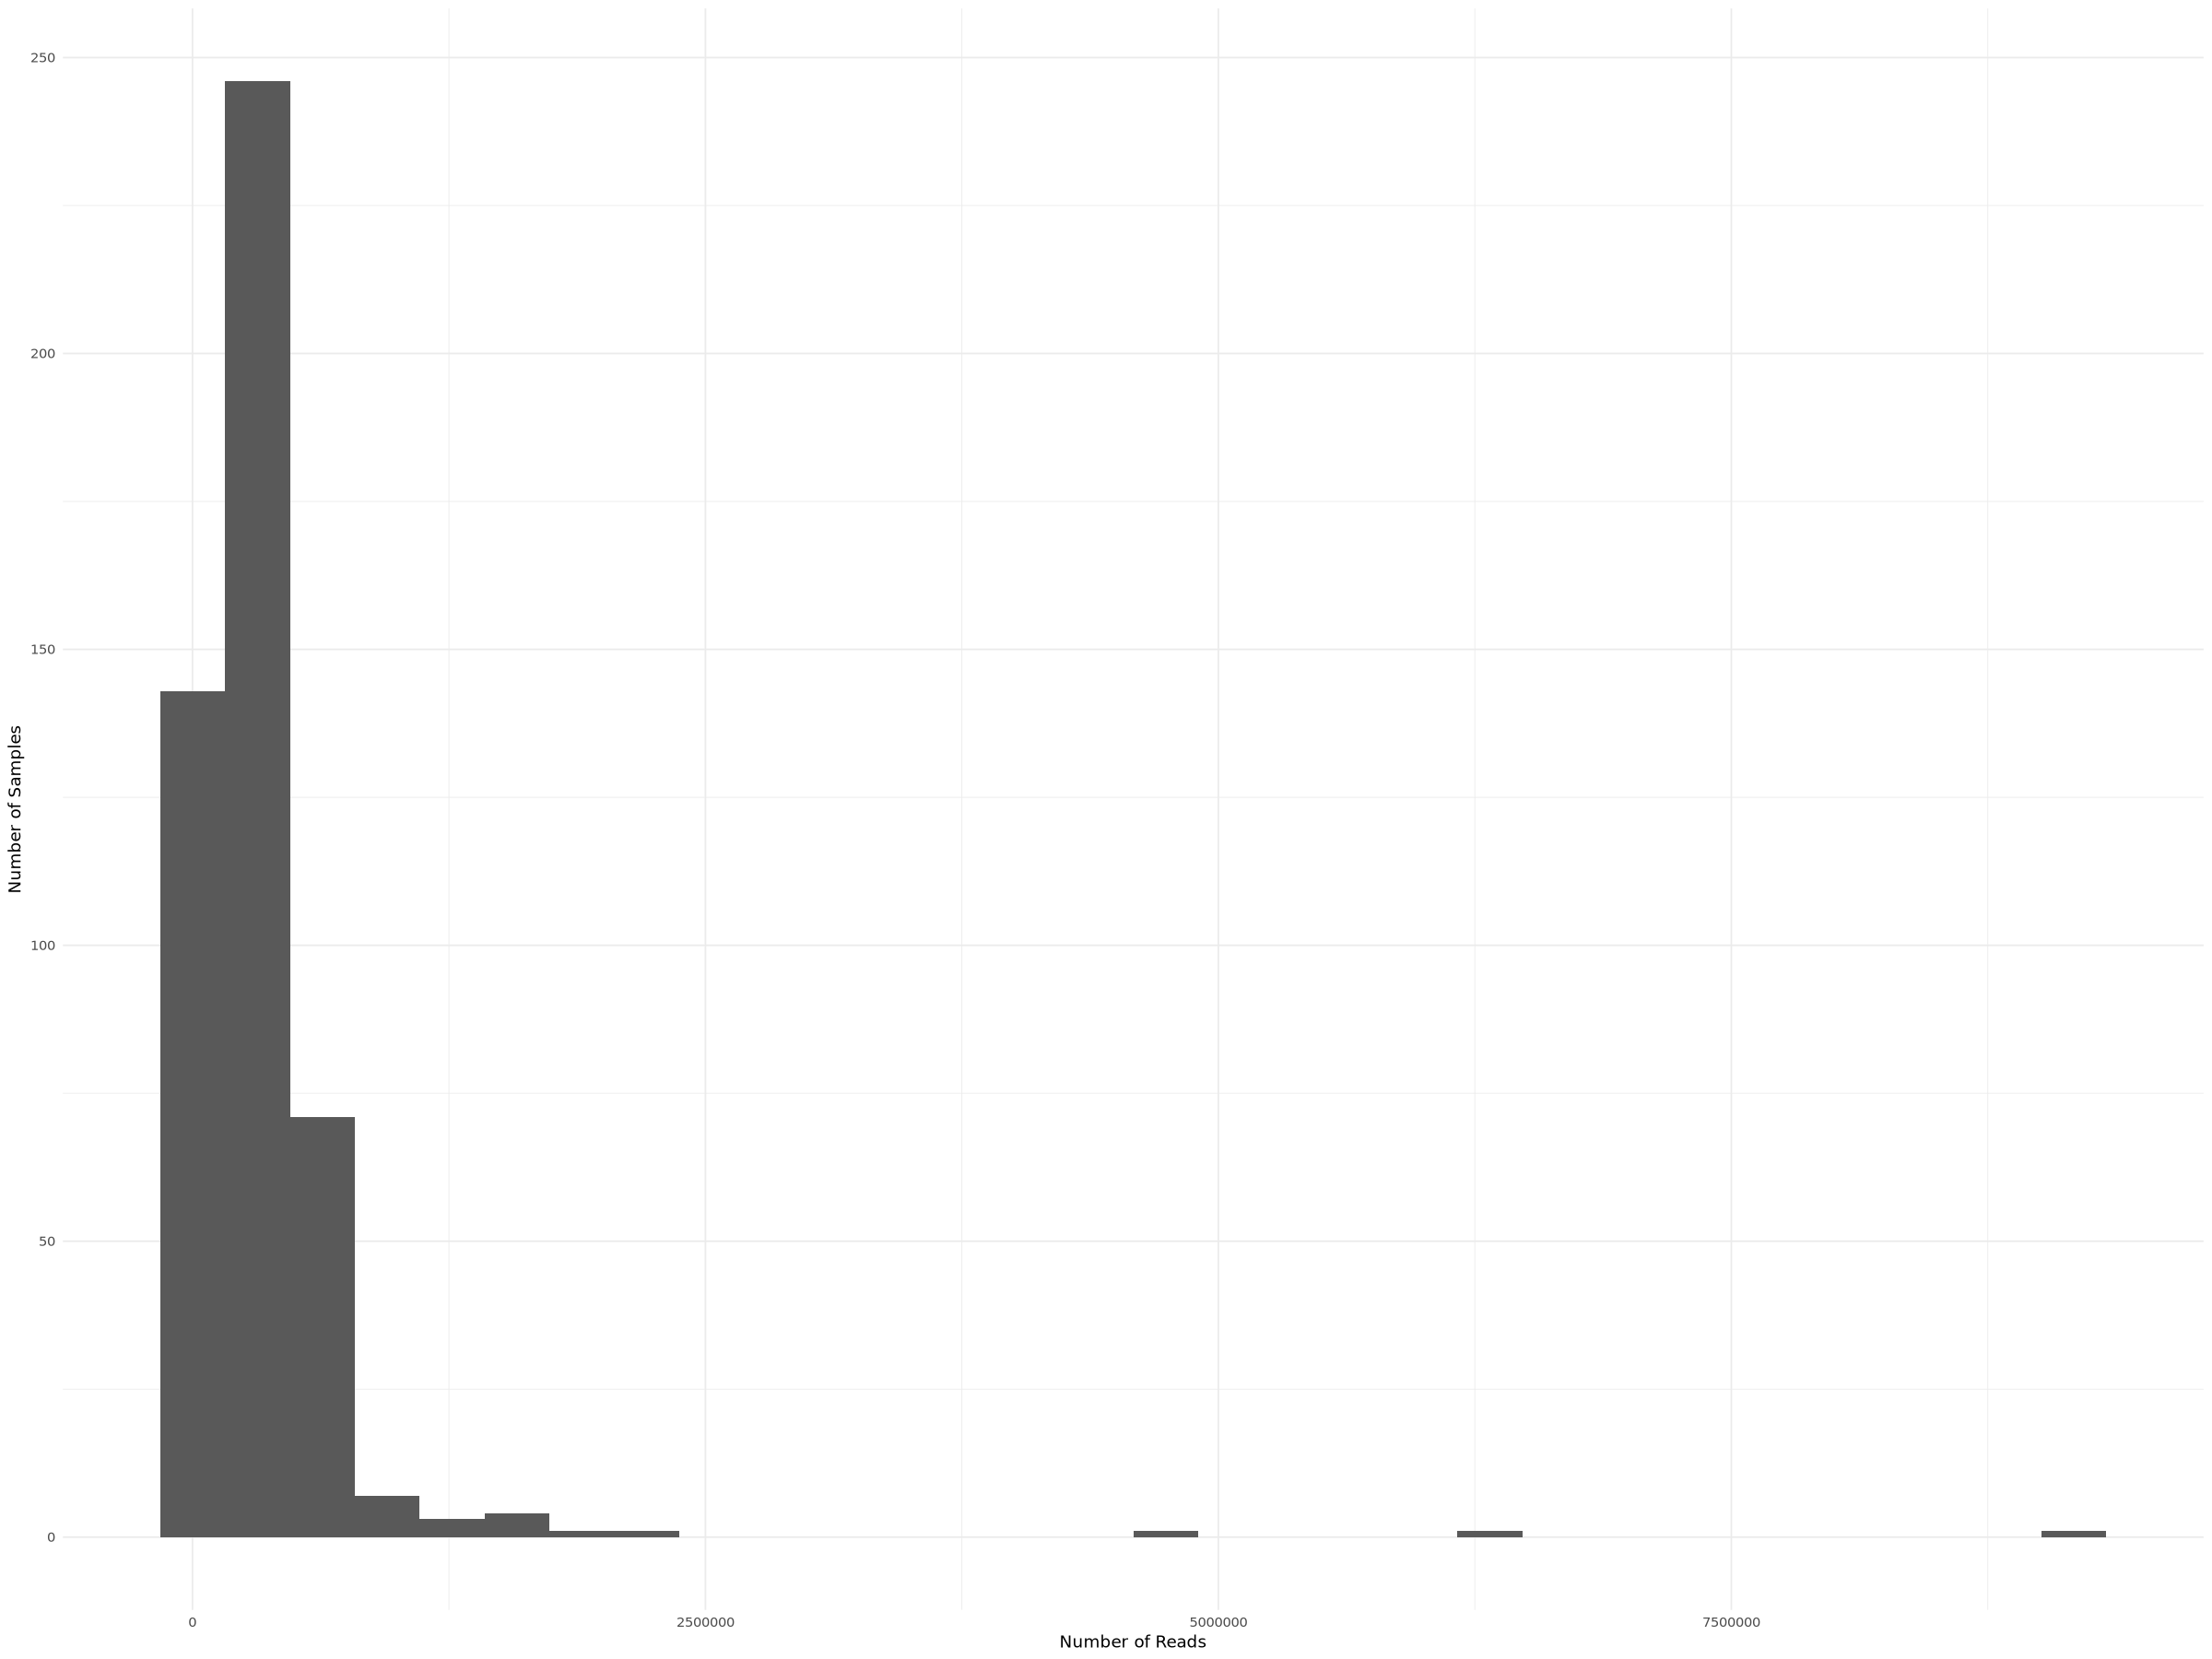

In [69]:
### where do I want to draw the filtering threshold?

readcount %>%
  ggplot(aes(x = TotalReads)) +
  geom_histogram() +   # Added width and transparency
  labs(x = "Number of Reads", y = "Number of Samples") +
  theme_minimal()

### figure notes
- most samples have under 2,500,000 reads, outliers with greater # of reads are from seq run 1

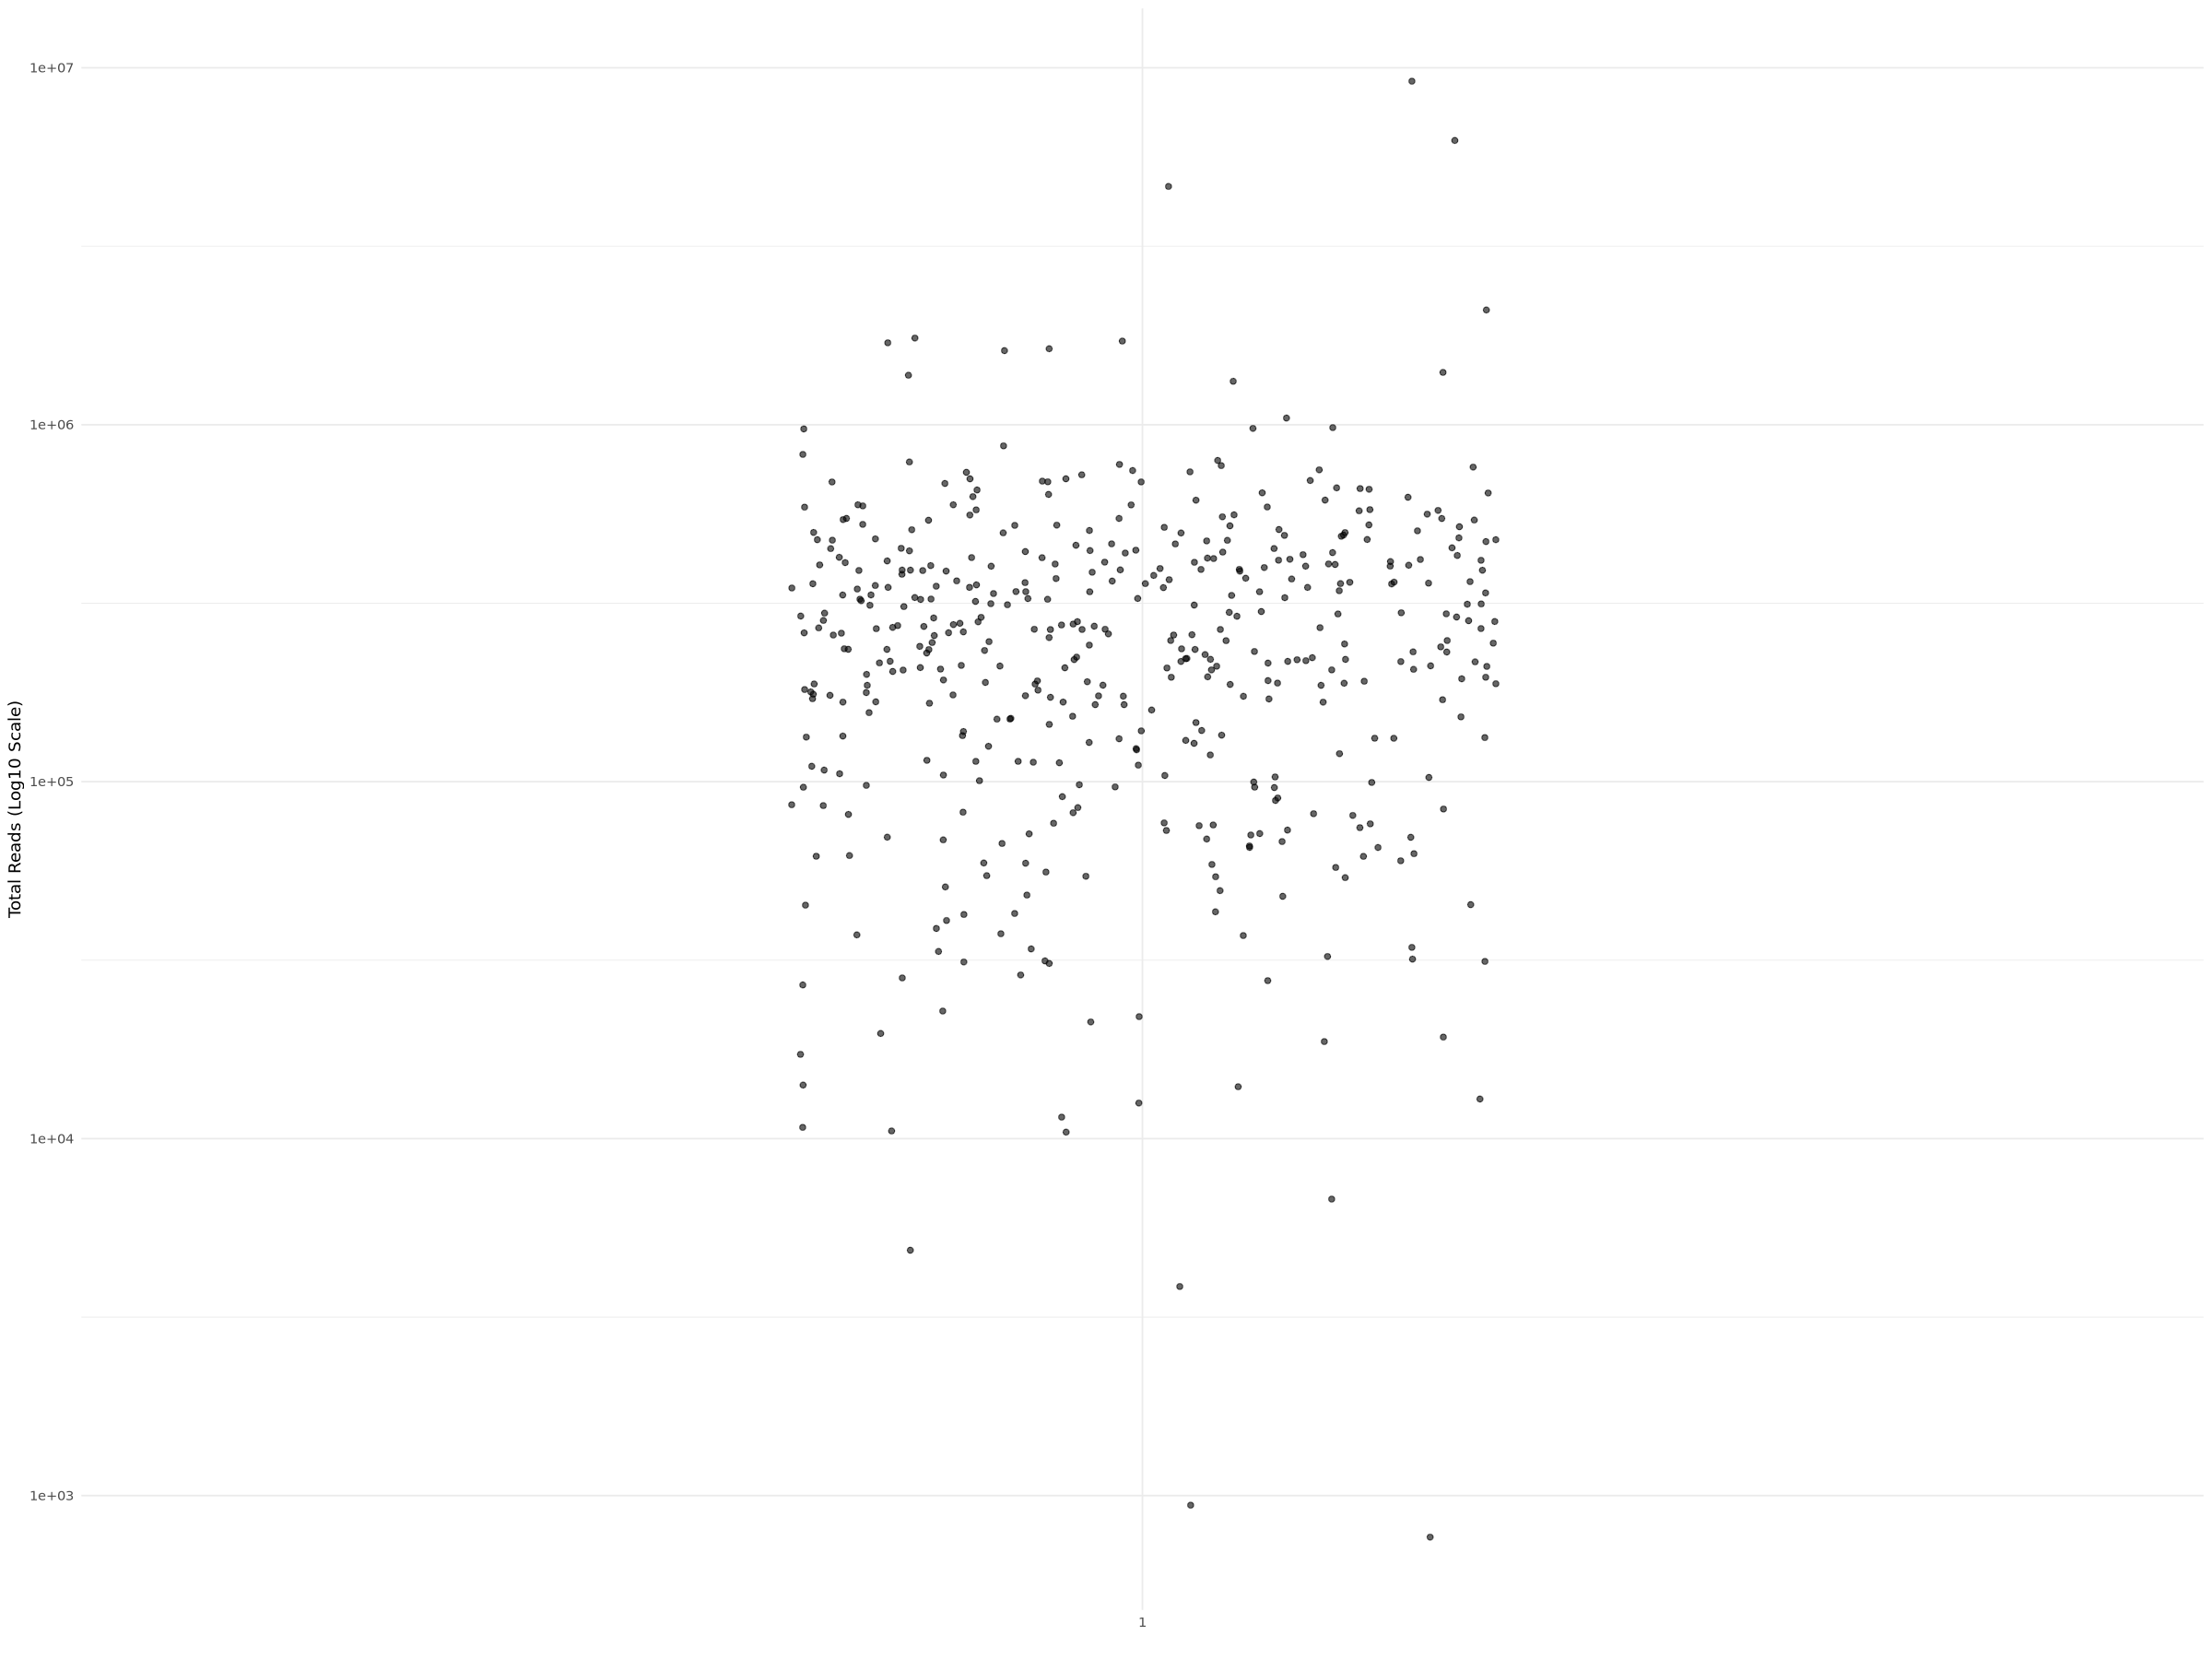

In [7]:
### where do I want to draw the filtering threshold?

readcount %>%
  ggplot(aes(x = factor(1), y = TotalReads)) +
  geom_jitter(width = 0.2, alpha = 0.6) +   # Added width and transparency
  scale_y_log10() +
  labs(x = "", y = "Total Reads (Log10 Scale)") +
  theme_minimal()


### figure notes
- most of the read counts for my samples lie between 10,000 and  1,000,000 reads
- therefore, I will filter out samples with <10K reads 

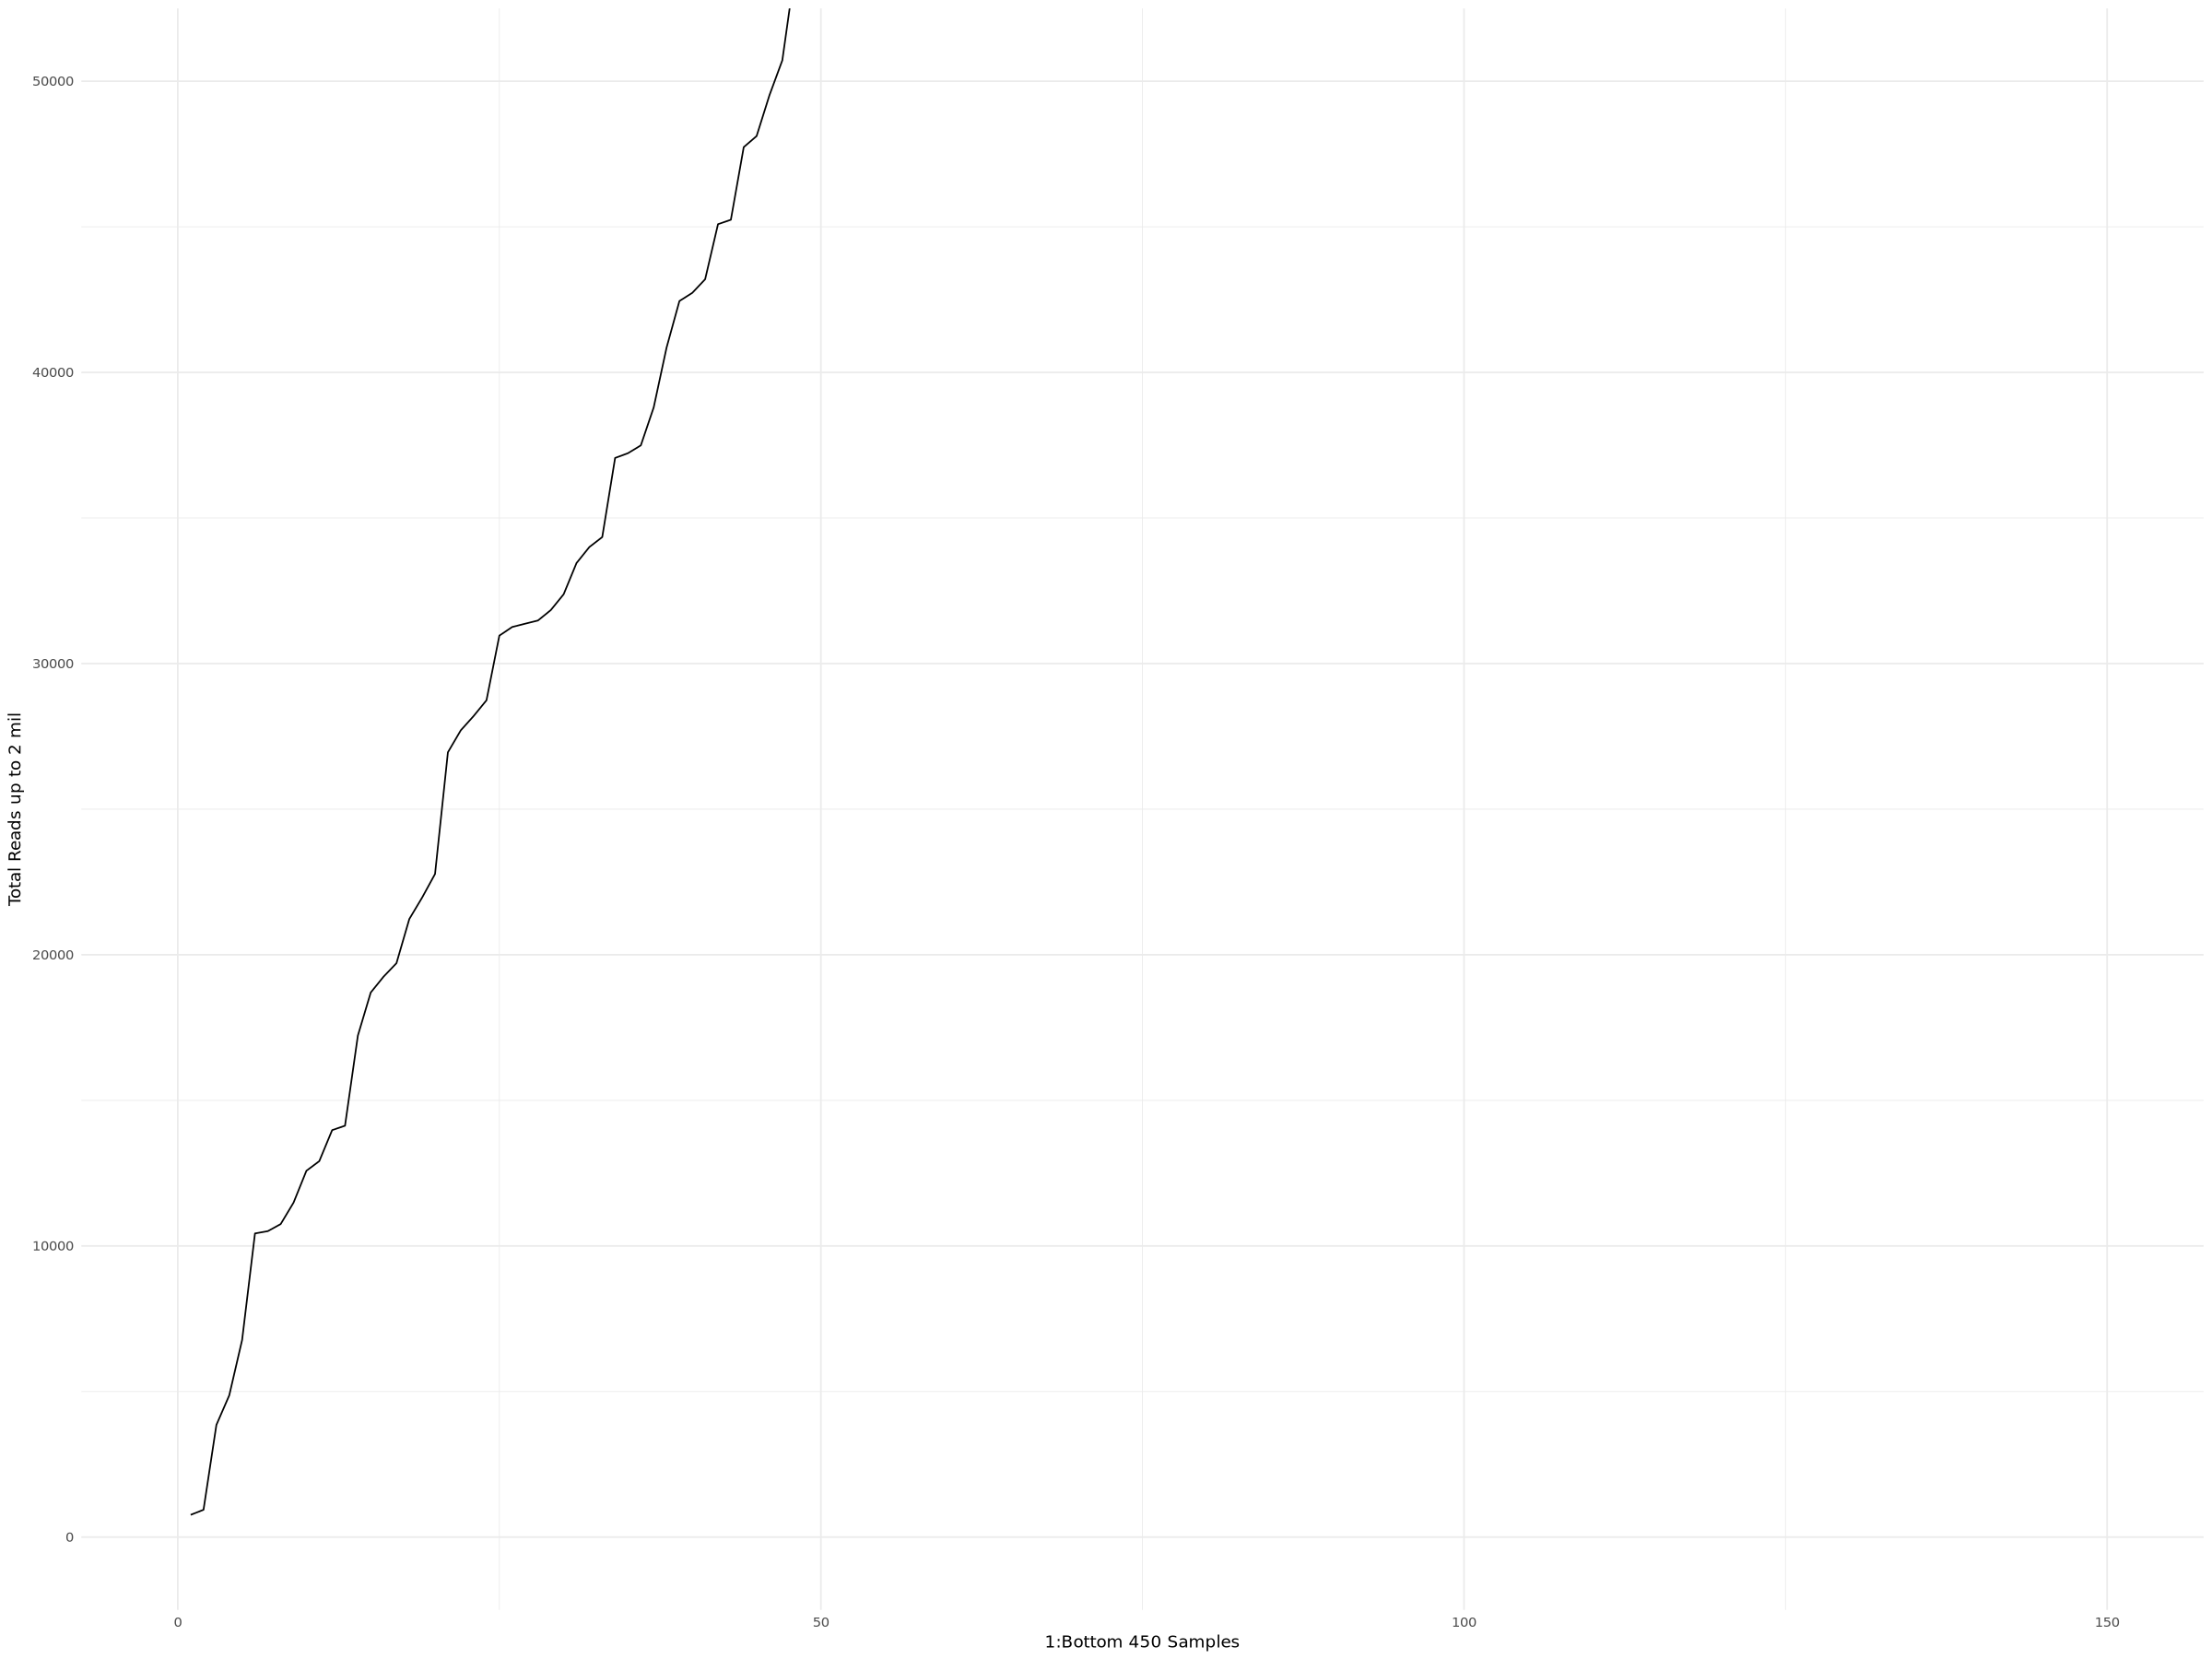

In [11]:
### where do I want to draw the filtering threshold?

readcount %>%
  arrange(TotalReads) %>%
  mutate(Index = row_number()) %>%  # Calculates the 1 to N index instantly
  ggplot(aes(x = Index, y = TotalReads)) +
    geom_line() +
coord_cartesian(xlim = c(0, 150), ylim = c(0, 50000)) +
    labs(x = "1:Bottom 450 Samples", y = "Total Reads up to 2 mil") +
    theme_minimal()

### Good's coverage
- the fraction of sequences that appear in an OTU seen more than once
  

$$ C= 100(1-n/N) $$
- n= number of OTU with 1 sequence
- N= Total number of sequences


- to find Good's coverage I need to start with a table of "SampleID" "ASV_Name" "How Many times saw that otu in that sample"
    - from this can find number of reads per sample, just do
      ```
      sampling coverage <- 
      group_by(SampleID) %>% 
      summarize(TotalReads = sum(value))
      ```

**good's coverage no filter on read count**

``` 
sampling_coverage %>%
summarize(sum_reads = sum(TotalReads),
          single_reads = sum(TotalReads == 1),
          goods = 100*(1 - single_reads / sum_reads))ˇ


ggplot(aes(x = TotalReads, y = goods)) +
  geom_point() +
  labs(x = "Total Reads Per sample", y = "Goods Coverage Value") +
  theme_minimal()

```

**good's coverage with 10K filter on read count**
```
readcount %>%
summarize(sum_reads = sum(TotalReads),
          single_reads = sum(TotalReads == 1),
          goods = 100*(1 - single_reads / sum_reads)) %>%
filter(TotalReads > 10000) %>%
  ggplot(aes(x = TotalReads, y = goods)) +
  geom_point() +
  labs(x = "Total Reads Per sample above 10K reads", y = "Goods Coverage Value") +
  theme_minimal()
  ```

## removing_under_10K_reads 
- **from original ps object (not filtered)**
- removes 5 outlier samples from jitter plot


In [8]:
# remove low read counts
ps_high <- prune_samples(sample_sums(ps) >= 10000, ps)

In [9]:
# which samples were removed?
setdiff(sample_names(ps_prune), sample_names(ps_high))

[1] "122022_BEL_CBC_T3_142_MCAV" "042024_BEL_CBC_T3_960_OFAV"
[3] "Negative"                   "012024_BEL_CBC_T1_561_OANN"
[5] "Negative.4"

In [10]:
ps_high
ps_prune

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 268938 taxa and 474 samples ]
sample_data() Sample Data:       [ 474 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 268938 taxa by 6 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46551 taxa and 479 samples ]
sample_data() Sample Data:       [ 479 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 46551 taxa by 6 taxonomic ranks ]

### filtering_ps_high
- remove mito, chloro
- prune for singletons

In [11]:
#isolate just bacteria
ps_bac_high=subset_taxa(ps_high, Kingdom=="Bacteria")
ps_bac_high

#remove chloroplast order
ps_nochlo_high=subset_taxa(ps_bac_high, Order!="Chloroplast")
ps_nochlo_high

#remove mitochondria family
ps_nomit_high=subset_taxa(ps_nochlo_high, Family!="Mitochondria")
ps_nomit_high

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 104196 taxa and 474 samples ]
sample_data() Sample Data:       [ 474 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 104196 taxa by 6 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 78949 taxa and 474 samples ]
sample_data() Sample Data:       [ 474 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 78949 taxa by 6 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46684 taxa and 474 samples ]
sample_data() Sample Data:       [ 474 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 46684 taxa by 6 taxonomic ranks ]

In [12]:
#removing any taxa that don't show up in any samples to speed up the process

#maybe I should up to 1 to remove singletons
ps_prune_high <- prune_taxa(taxa_sums(ps_nomit_high) > 0, ps_nomit_high)
ps_prune_high

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46536 taxa and 474 samples ]
sample_data() Sample Data:       [ 474 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 46536 taxa by 6 taxonomic ranks ]

In [14]:
head(sample_data(ps_prune_high))

,Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted,Tubelabel_species
,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>,<chr>
052022_BEL_CBC_T1_2_SSID,Diseased_Tissue,1_3,1_22_2025,Diseased,SSID,May 2022,1,CBC30N,2022-05-21,052022_BEL_CBC_T1_2_SSID
092023_BEL_CBC_T1_175_PAST,Healthy,1_13,1_22_2025,Healthy,PAST,Sep 2023,1,CBC30N,2023-09-25,092023_BEL_CBC_T1_175_PAST
022024_BEL_CBC_T3_851_PSTR,Healthy,3_70,1_23_2025,Healthy,PSTR,Feb 2024,1,Lagoon,2024-02-24,022024_BEL_CBC_T3_851_PSTR
082024_BEL_CBC_T4_1609_OFAV,Healthy,4_78,1_23_2025,Healthy,OFAV,Aug 2024,1,Curlew,2024-08-22,082024_BEL_CBC_T4_1609_OFAV
122023_BEL_CBC_T3_526_SSID,Healthy,3_5,1_23_2025,Healthy,SSID,Dec 2023,1,Lagoon,2023-12-16,122023_BEL_CBC_T3_526_SSID
112023_BEL_CBC_T4_399_MCAV,Bleached_Tissue,4_76,1_23_2025,CLP,MCAV,Nov 2023,1,Curlew,2023-11-13,112023_BEL_CBC_T4_399_MCAV


# DESeq2

In [ ]:
## change species column to factor, compatible with DESeq2

# Run this BEFORE phyloseq_to_deseq2 to set your baseline species
sample_data(ps_prune_high)$Species <- as.factor(sample_data(ps_prune_high)$Species)

In [17]:
speciesdds = phyloseq_to_deseq2(ps_prune_high, ~ Species )

# estimatesize factors not happy with counts of 0 in samples
## alternate way to calculate size factors, only looks at the positive counts for each microbe
speciesdds = estimateSizeFactors(speciesdds, type = "poscounts")

speciesdds = DESeq(speciesdds, test="Wald", fitType="parametric")

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
using pre-existing size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 17192 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



### cooksCutoff
- DESeq on default has it on to check data for extreme outliers with cooks distance
- cooksCutoff =FALSE turns this off, so DESeq will calculate p-values for every row even if significance is driven by outlier

- test both ways: sometimes cooks distance can flag variants as outliers

In [18]:
res_species = results(speciesdds, cooksCutoff = FALSE)
alpha = 0.05
sigtab = res_species[which(res_species$padj < alpha), ]
sigtab = cbind(as(sigtab, "data.frame"), as(tax_table(ps_prune_high)[rownames(sigtab), ], "matrix"))
head(sigtab)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Kingdom,Phylum,Class,Order,Family,Genus
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATAGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,1038.098,3.466938,0.3999898,8.667567,4.414530e-18,1.075159e-15,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Vibrionaceae,Vibrio
GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGAGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,9542.427,3.306733,0.2729601,12.114345,8.866918e-34,5.398844e-31,Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Endozoicomonadaceae,Parendozoicomonas
GCAAGCGTTGTTCGGAATTACTGGGCGTAAAGGGCGTGTAGGCGGATTATCAAGTTAGGGGTGAAATCCCGGGGCTCAACCTCGGCACTGCCTTTAAGACTGATAATCTAGAGTATGTGAGGGGATAATGGAATACCTAGTGTAGAGGTGAAATTCGTAGATATTAGGTGGAACACCAGTGGCGAAGGCGATTATCTGGCACATTACTGACGCTGAGGCGCGAAAGCGTGGGG,3863.120,-3.265561,0.4464438,-7.314607,2.581362e-13,4.436855e-11,Bacteria,Pseudomonadota,Alphaproteobacteria,Rhodospirillales,Terasakiellaceae,Marivibrio
TCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCGCGTAGGCGGTTTGCTAAGTCAGATGTGAAATCCCTGGGCTTAACCTAGGAACTGCATTTGAAACTAGCAAGCTAGAGTATGGTAGAGGTGGGTGGAATTTCAGGTGTAGCGGTGGAATGCGTAGAGATCTGAAGGAACATCAGTGGCGAAGGCGGCTCACTGGGCCATCACTGACGCTGAGGTGCGAAAGCGTGGGT,1504.486,-4.359632,0.6460761,-6.747861,1.500401e-11,2.088130e-09,Bacteria,Pseudomonadota,Gammaproteobacteria,Nitrosococcales,Methylophagaceae,Marine Methylotrophic Group 3
GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATTGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,1166.883,3.360715,0.5518128,6.090317,1.126873e-09,1.247500e-07,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Vibrionaceae,Vibrio
GCAAGCGTTGTTCGGATTTACTGGGCGTAAAGGGTGCGTAGGTGGCATGACAAGTCACTTGTGAAATCTCCGAGCTTAACTCGGAACGGTCAAGTGATACTGTTGTGCTAGAGTGCGGGAAGGGCAGCTGGAATTCTTGGTGTAGCGGTGAAATGCGTAGATATCAAGAGGAACACCGGAGGCGAAGGCGAGTTGCTAGACCGACACTGACGCTGAGGCACGAAAGCCAGGGG,2421.658,-9.459922,0.3951819,-23.938146,1.227899e-126,5.981097e-123,Bacteria,Acidobacteriota,Blastocatellia,Blastocatellales,Blastocatellaceae,NA


In [19]:
species_taxa=sigtab[,c("log2FoldChange", "Kingdom", "Phylum", "Class", "Order", "Family", "Genus")] 
species_taxa <- as.matrix(species_taxa)

In [20]:
##turn into phyloseq object
sigspeciesTAX <- tax_table(species_taxa)
ps_species_log <- ps_prune_high
tax_table(ps_species_log)=sigspeciesTAX

In [21]:
##filter for asvs found in 33% of samples
ps_species_log_filter <- genefilter_sample(ps_species_log, filterfun_sample(function(x) x > 1), A=0.33*nsamples(ps_species_log))
ps_species_log_prune <- prune_taxa(ps_species_log_filter, ps_species_log)
     

species_log_prune=ps_species_log_prune
tax_table(species_log_prune) <- tax_table(species_log_prune)[,2:7]
taxmap_species <- parse_phyloseq(species_log_prune)

The following 27 of 99 (27.3%) input indexes have `NA` in their classifications:
   6, 17, 18, 25, 39, 40, 44, 46 ... 82, 83, 88, 92, 94, 95, 97, 98




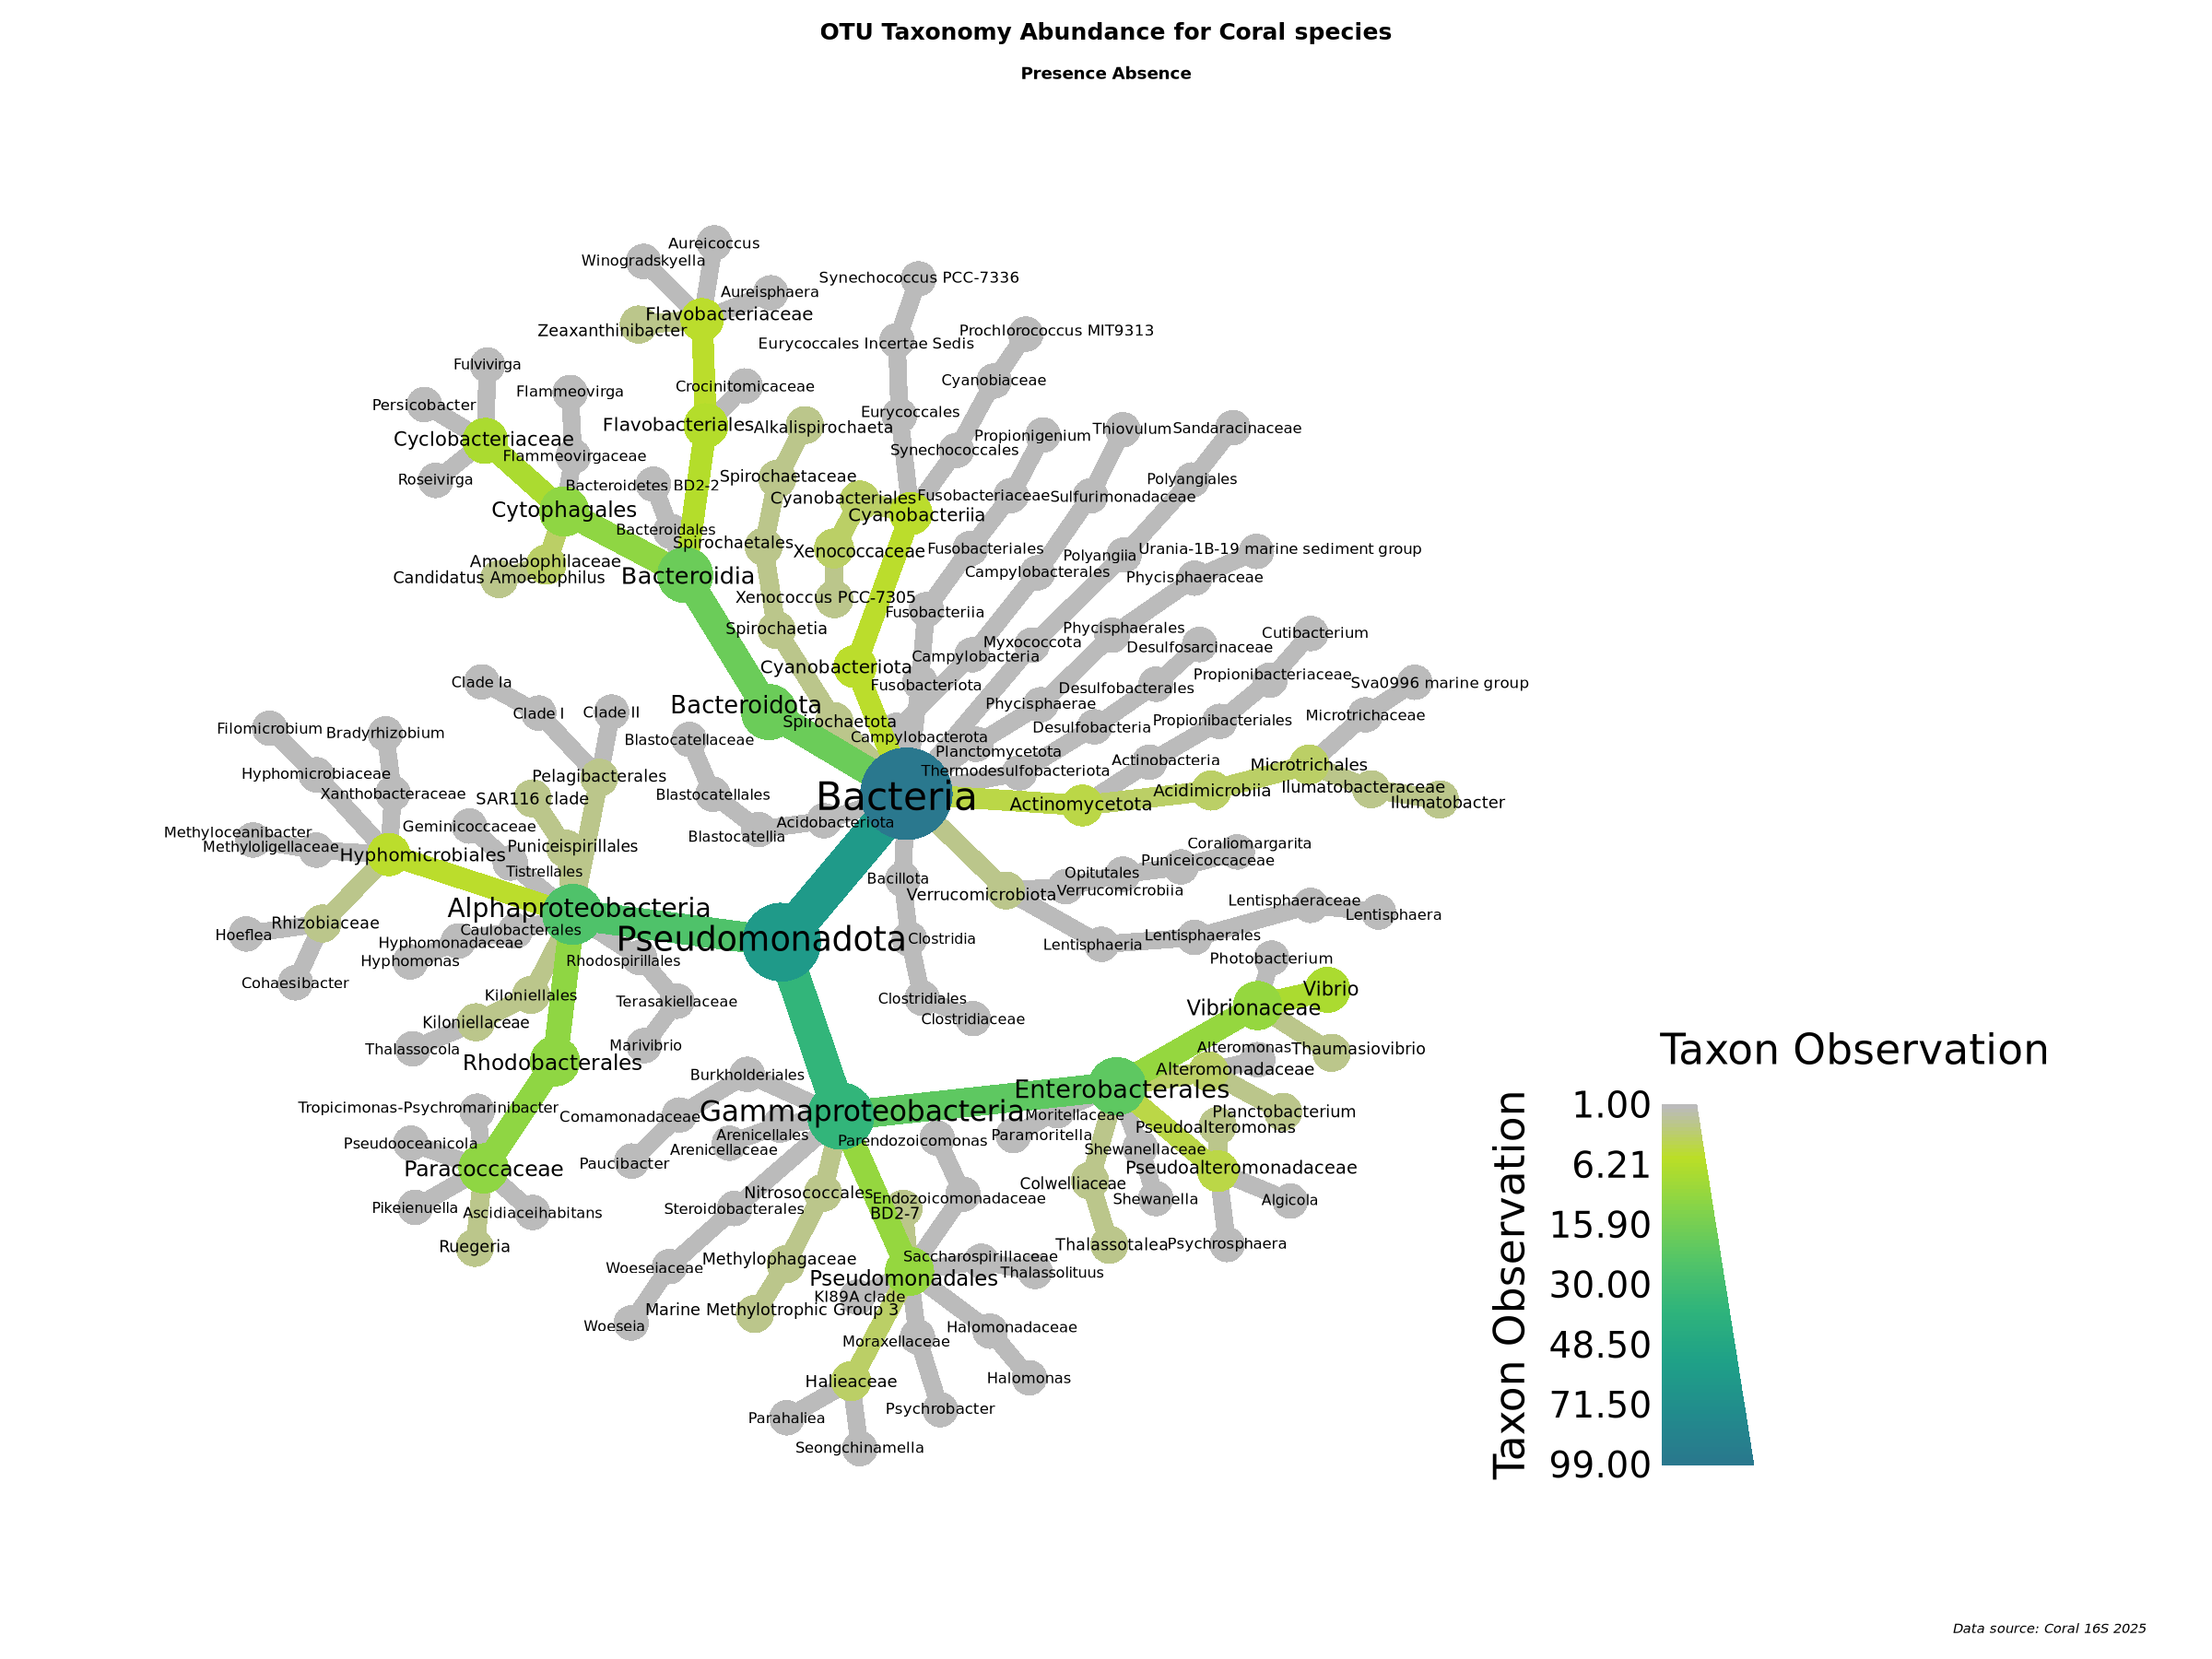

In [22]:
taxmap_species %>% 
  heat_tree(node_label = taxon_names,
            node_size = n_obs(taxmap_species),
            node_color = n_obs(taxmap_species),
            layout = "davidson-harel", initial_layout = "reingold-tilford", 
            node_legend_title	= "Taxon Observation", 
            node_color_axis_label ="Taxon Observation",
            margin_size = c(0.1, 0.1, 0.1, 0.1))+
  theme(legend.position = "none", 
        legend.text=element_text(size=8),
        axis.text.x = element_blank(),
        plot.title = element_text(face = "bold", hjust = 0.5, size = 15, colour = "black", margin=margin(15, 15, 0, 15)), 
        plot.subtitle = element_text(face = "bold", hjust = 0.5, color = "black", margin=margin(15, 15, 15, 15), ),
        plot.caption = element_text(color = "black", face = "italic", margin=margin(15, 15, 15, 15)),
        axis.title.x = element_blank(), 
        axis.title.y = element_blank())+
  labs(title = "OTU Taxonomy Abundance for Coral species", 
       subtitle = "Presence Absence",
       caption = "Data source: Coral 16S 2025")

# species_diversity_plots 

## chron_dates

In [76]:
# 2. reorder MonthYear as a factor in chronological order
sample_data(ps_prune_high)$Month_year <- factor(sample_data(ps_prune_high)$Month_year,levels = c("Jun 2019", "Oct 2019", "May 2022", "Dec 2022", "Sep 2023","Nov 2023","Dec 2023","Jan 2024","Feb 2024","Apr 2024","Jun 2024","Aug 2024"))

## split_species_post_10K_filter

In [77]:
ps_past_high <- subset_samples(ps_prune_high, Species == "PAST")
ps_mcav_high <- subset_samples(ps_prune_high, Species == "MCAV")
ps_pstr_high <- subset_samples(ps_prune_high, Species == "PSTR")
ps_ssid_high <- subset_samples(ps_prune_high, Species == "SSID")

## PAST

### transect

**Figure Notes:**
- similar pattern from when I was normalizing:
- lagoon seems to have maintained higher alpha diversity after the bleaching increase in sept 2023
- T1 and T2 increased diversity during bleaching event and subsequently experienced diversity lows in early 2024

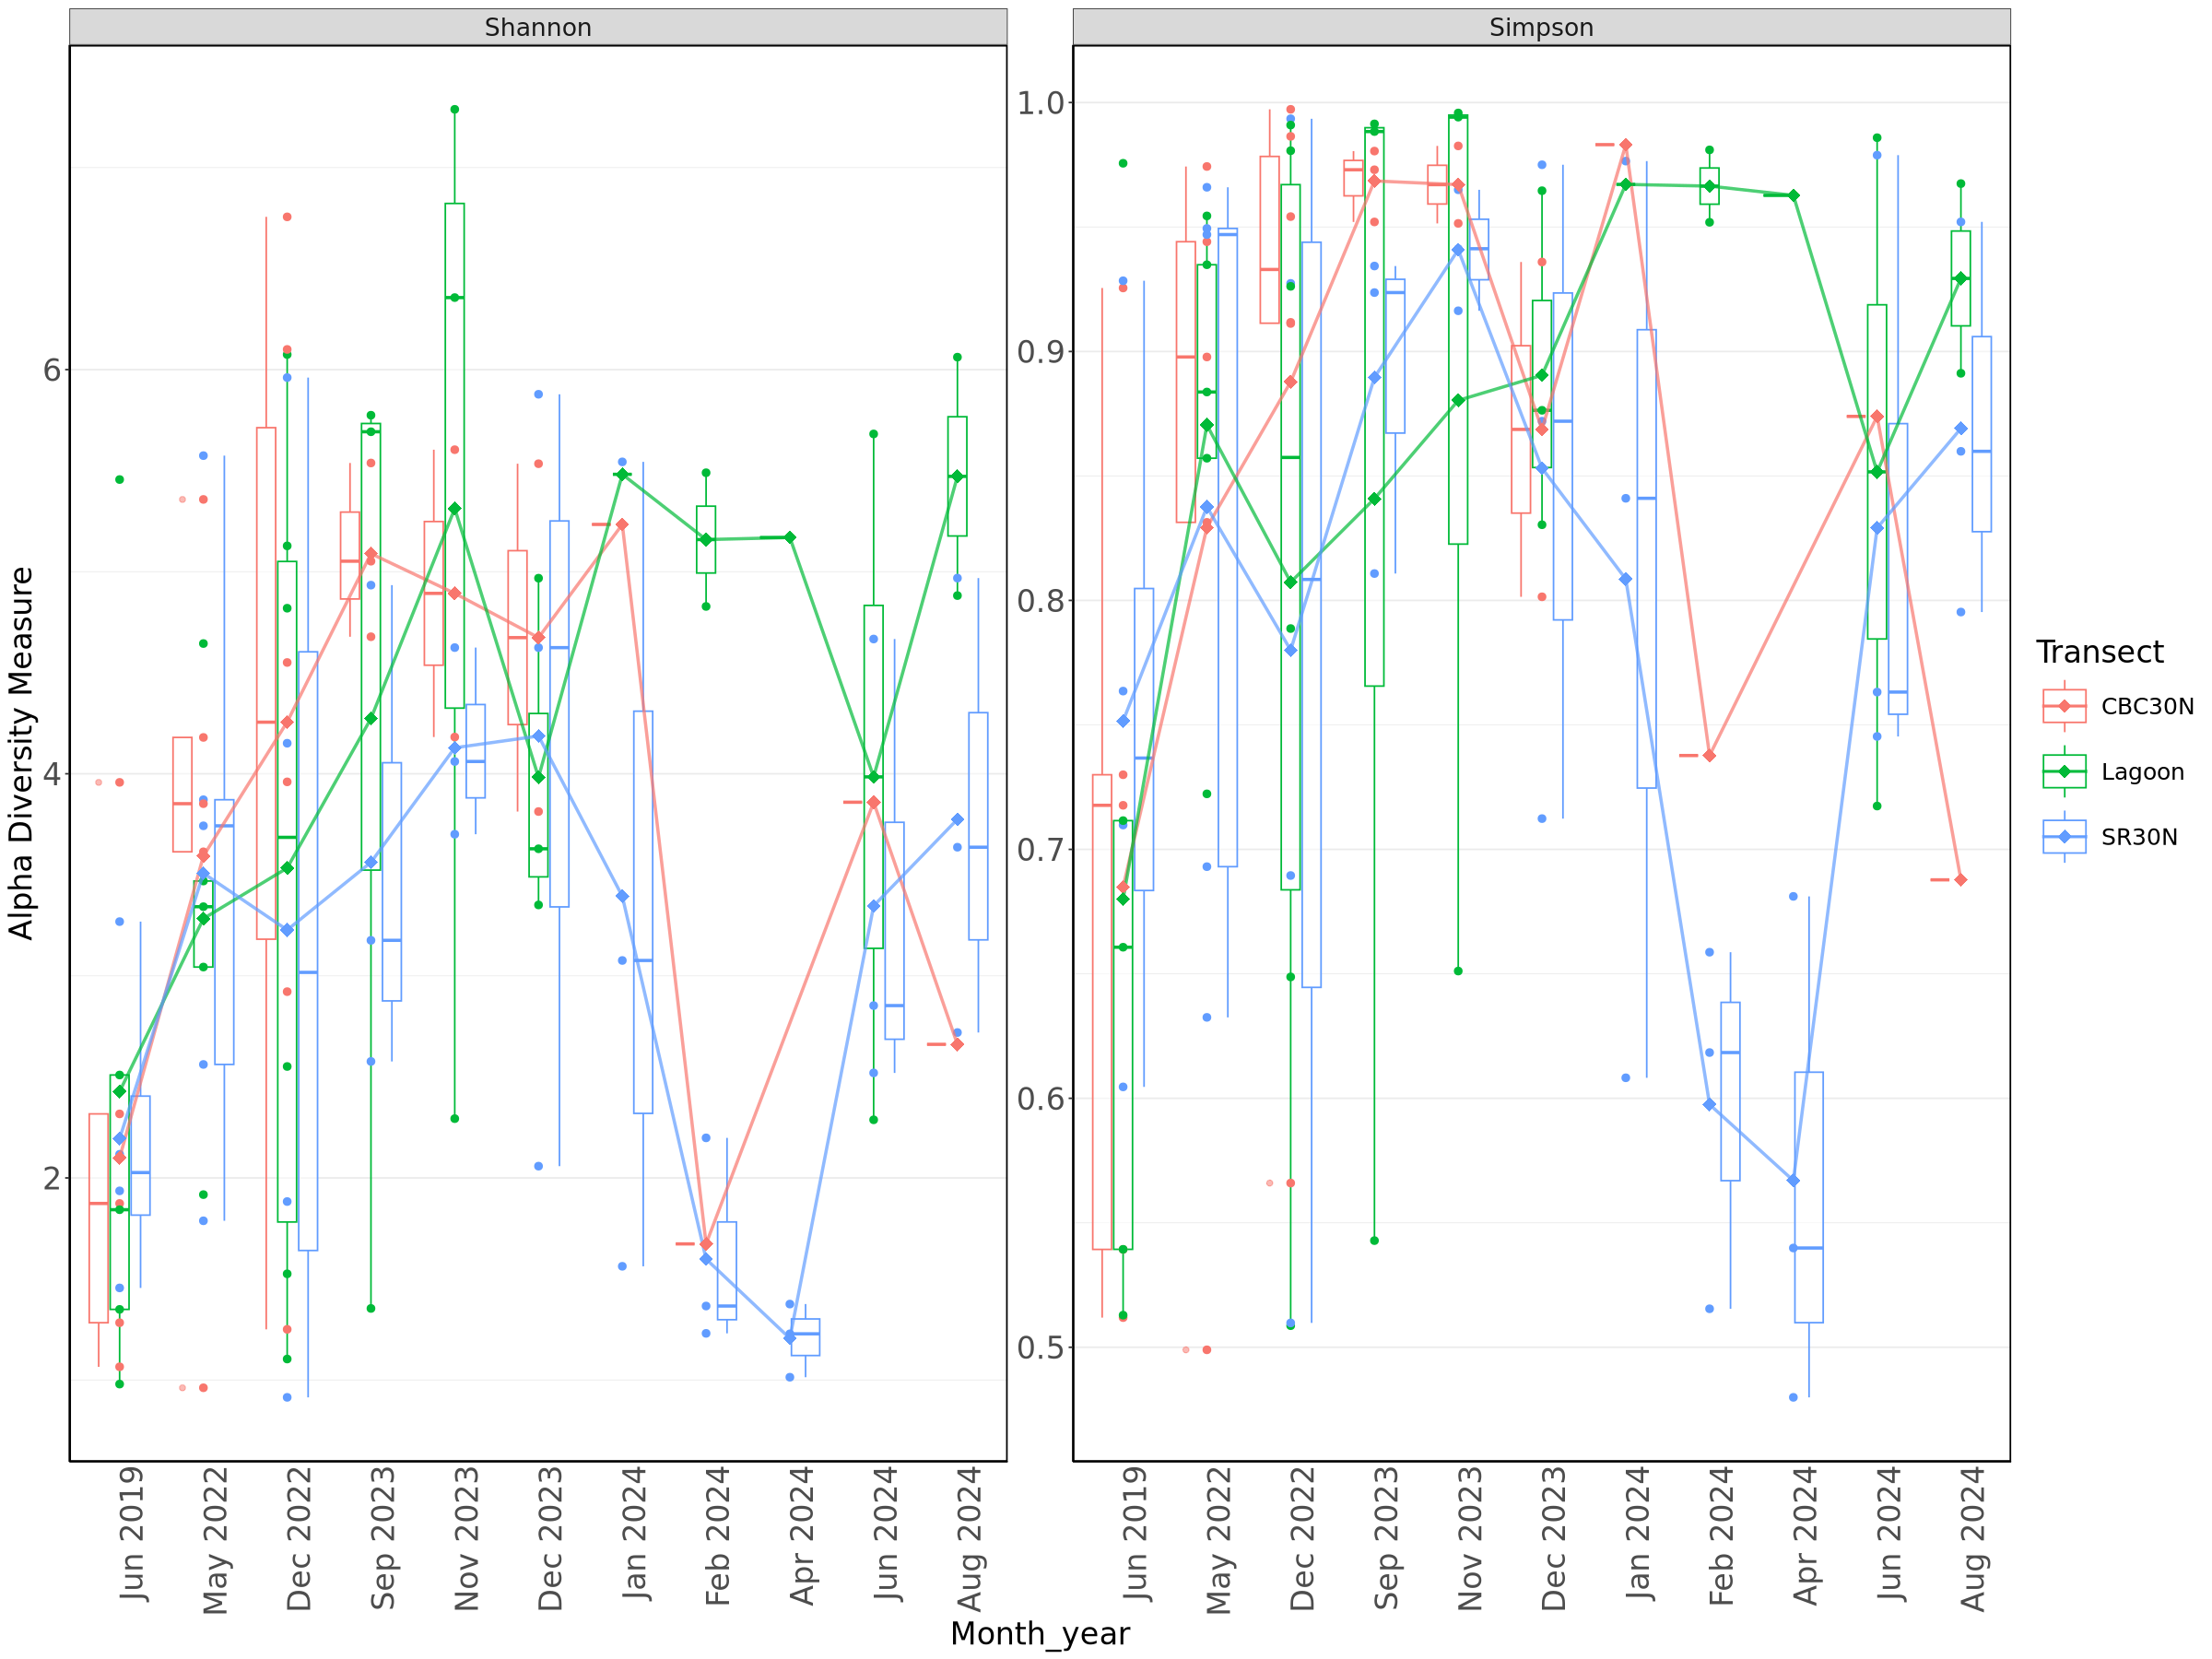

In [76]:
# Alpha diversity dot-line plot
plot_richness(ps_past_high, x="Month_year", measures=c("Shannon", "Simpson"), color="Transect") + 
  geom_boxplot(alpha = 0.5) + # Added alpha for better visibility of points
  geom_point(size=2) +
  # --- ADD THIS SECTION ---
  stat_summary(
    fun = mean, 
    geom = "line", 
    aes(group = Transect), 
    linewidth = 1, 
    alpha = 0.7
  ) +
  stat_summary(
    fun = mean, 
    geom = "point", 
    shape = 18, 
    size = 4, 
    aes(group = Transect)
  ) +
  # -------------------------
  theme_bw() +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 20),
    legend.text = element_text(size = 15),
    legend.key.width = unit(1.3, "cm"),
    legend.key.height = unit(1.5, "cm"),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 90, vjust = 1, hjust = 1, size=20),
    axis.text.y = element_text(size = 20),
    text = element_text(size = 20)
  )
     

### health_status

**Figure notes:**
- diseased_margin samples were similar diversity b/w 052022 and 122022
- diseased_tissue samples experienced reduced diversity in 122022
- bleached_tissue samples were prevalent only in late 2023 and these samples had high alpha diversity
- healthy samples follow the same trend as the general alpha diversity plot; peak diversity during bleaching and then reduced diversity but climbing up as 2024 moves into summer

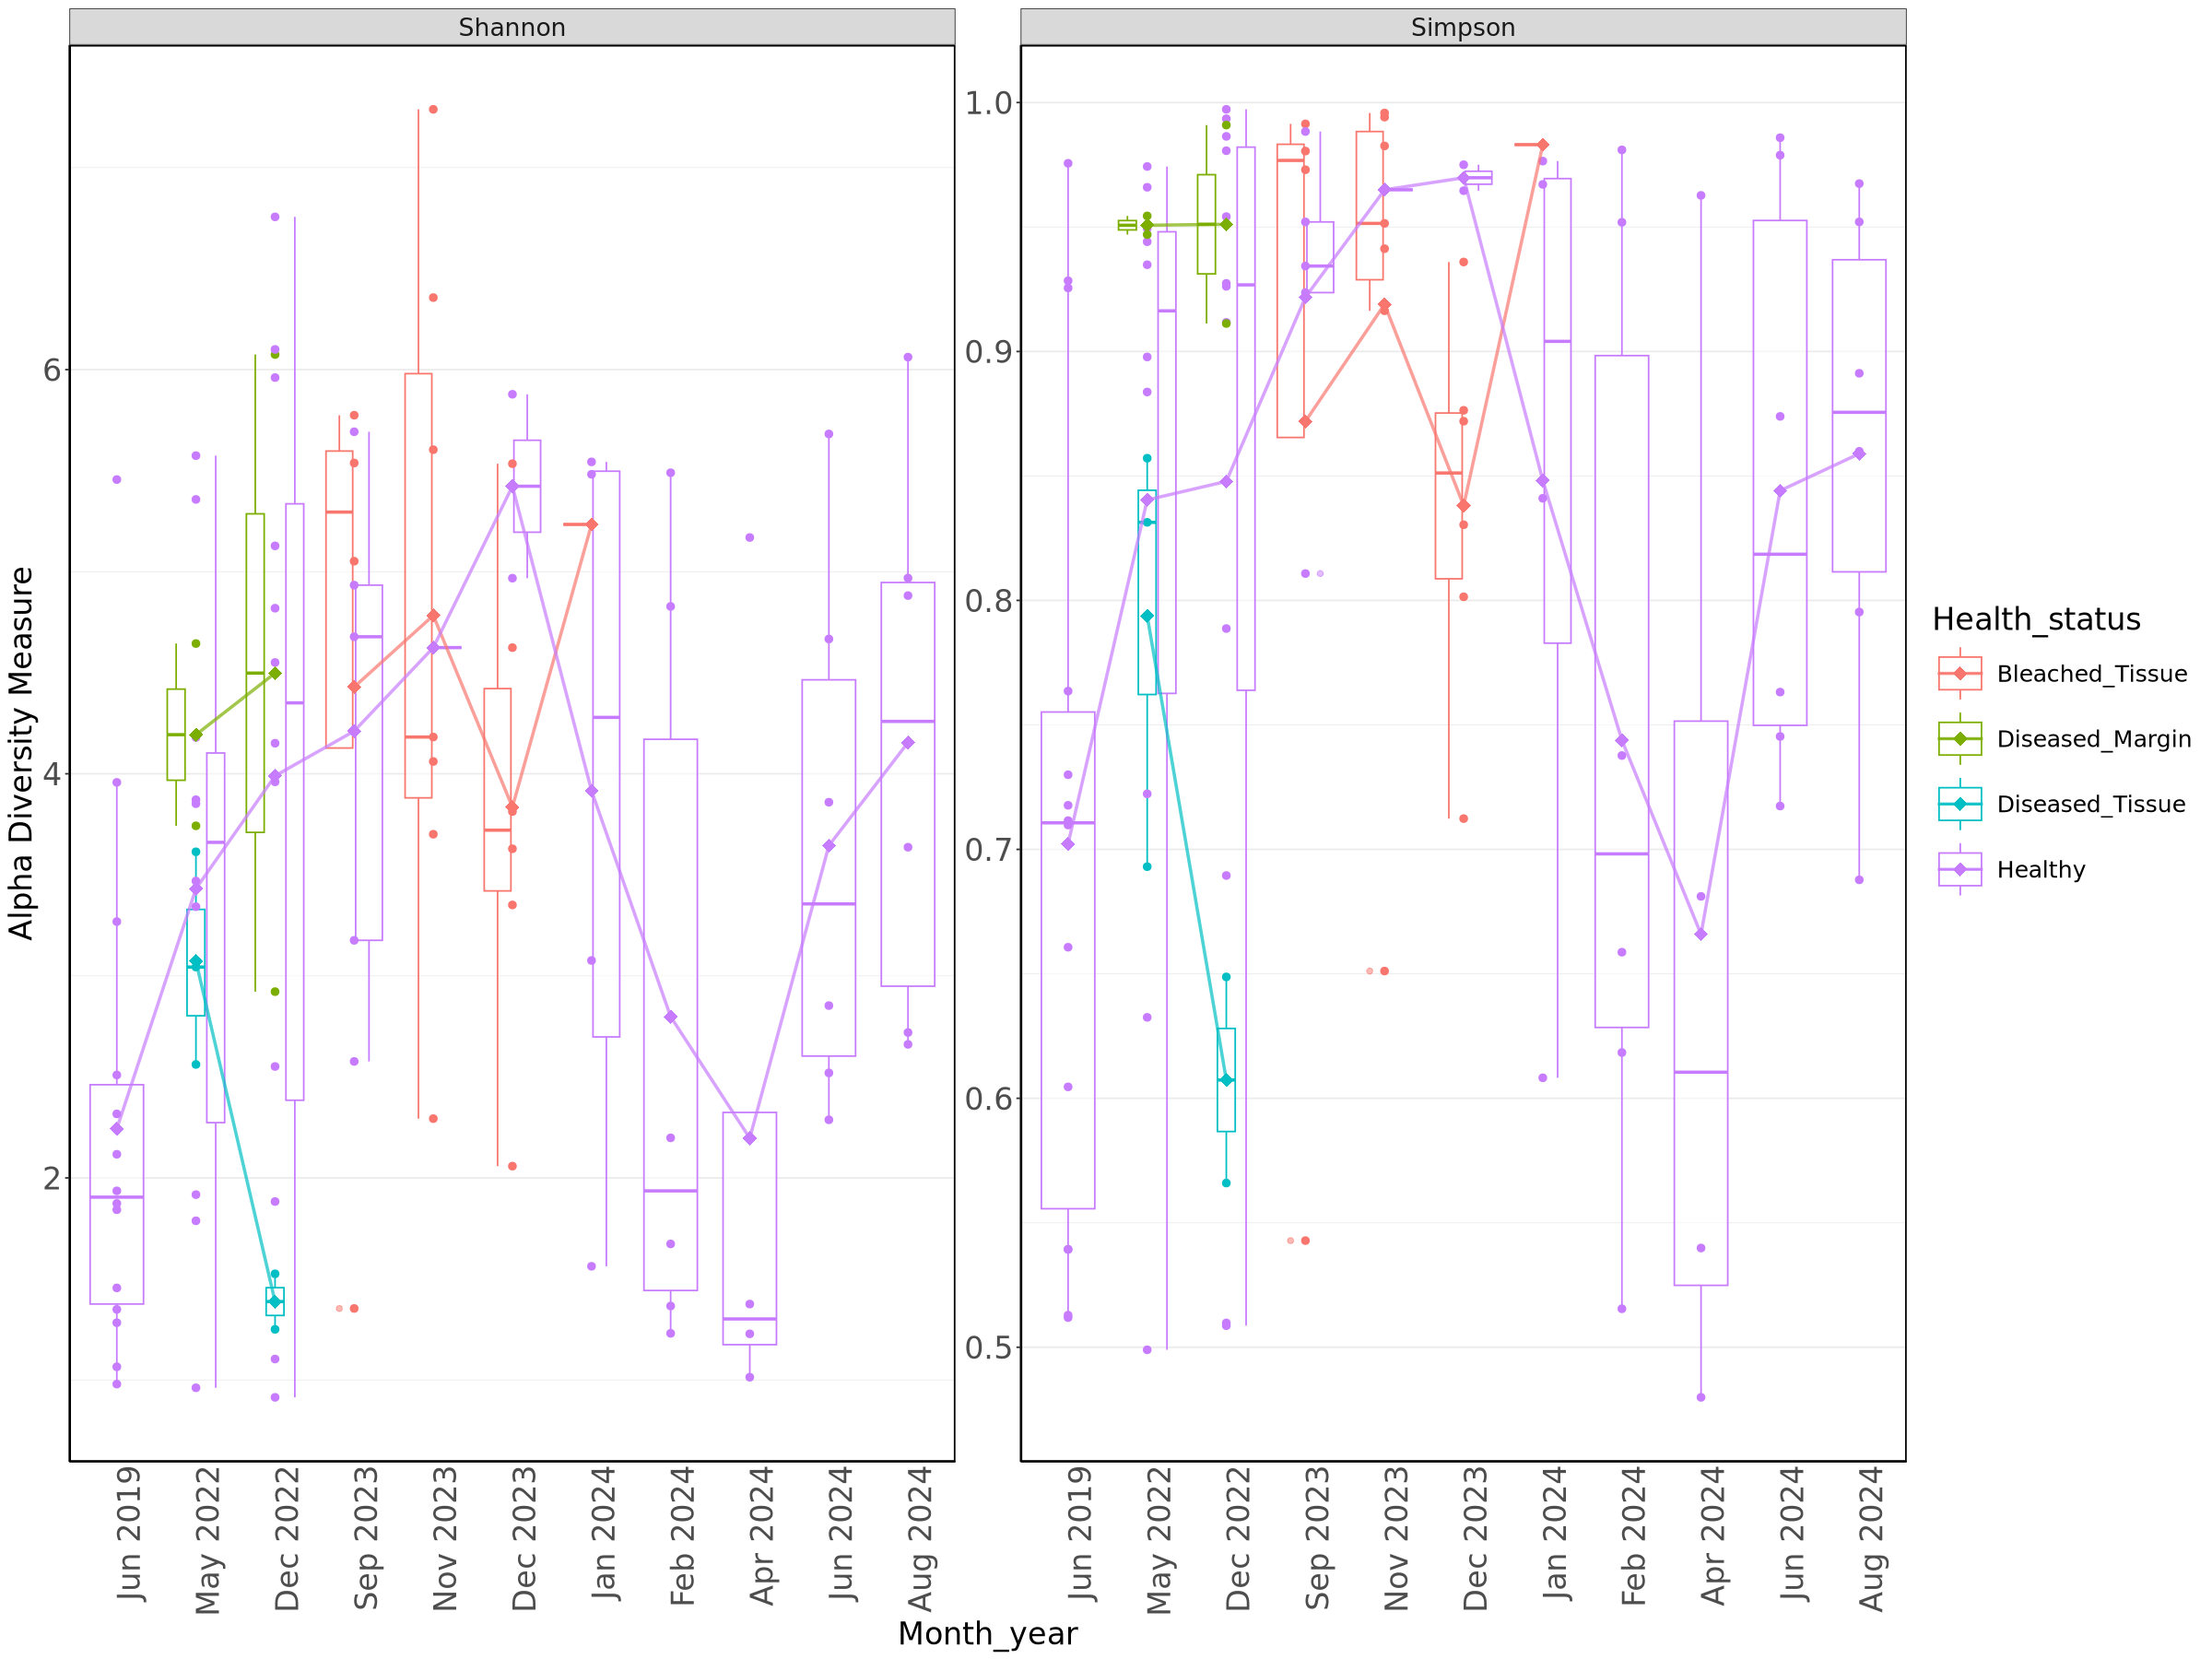

In [77]:
# Alpha diversity dot-line plot
plot_richness(ps_past_high, x="Month_year", measures=c("Shannon", "Simpson"), color="Health_status") + 
  geom_boxplot(alpha = 0.5) + # Added alpha for better visibility of points
  geom_point(size=2) +
  # --- ADD THIS SECTION TO ADD THE MEAN AS A POINT---
  stat_summary(
    fun = mean, 
    geom = "line", 
    aes(group = Health_status), 
    linewidth = 1, 
    alpha = 0.7
  ) +
  stat_summary(
    fun = mean, 
    geom = "point", 
    shape = 18, 
    size = 4, 
    aes(group = Health_status)
  ) +
  # -------------------------
  theme_bw() +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 20),
    legend.text = element_text(size = 15),
    legend.key.width = unit(1.3, "cm"),
    legend.key.height = unit(1.5, "cm"),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 90, vjust = 1, hjust = 1, size=20),
    axis.text.y = element_text(size = 20),
    text = element_text(size = 20)
  )


## MCAV

### transect

**Figure notes:**
-  T2, T3, and T4 seem to have a similar alpha diversity pattern where they increase in Sept 2023 and then decrease after bleaching event
-  T1 seems to be effected by outliers **explore this**

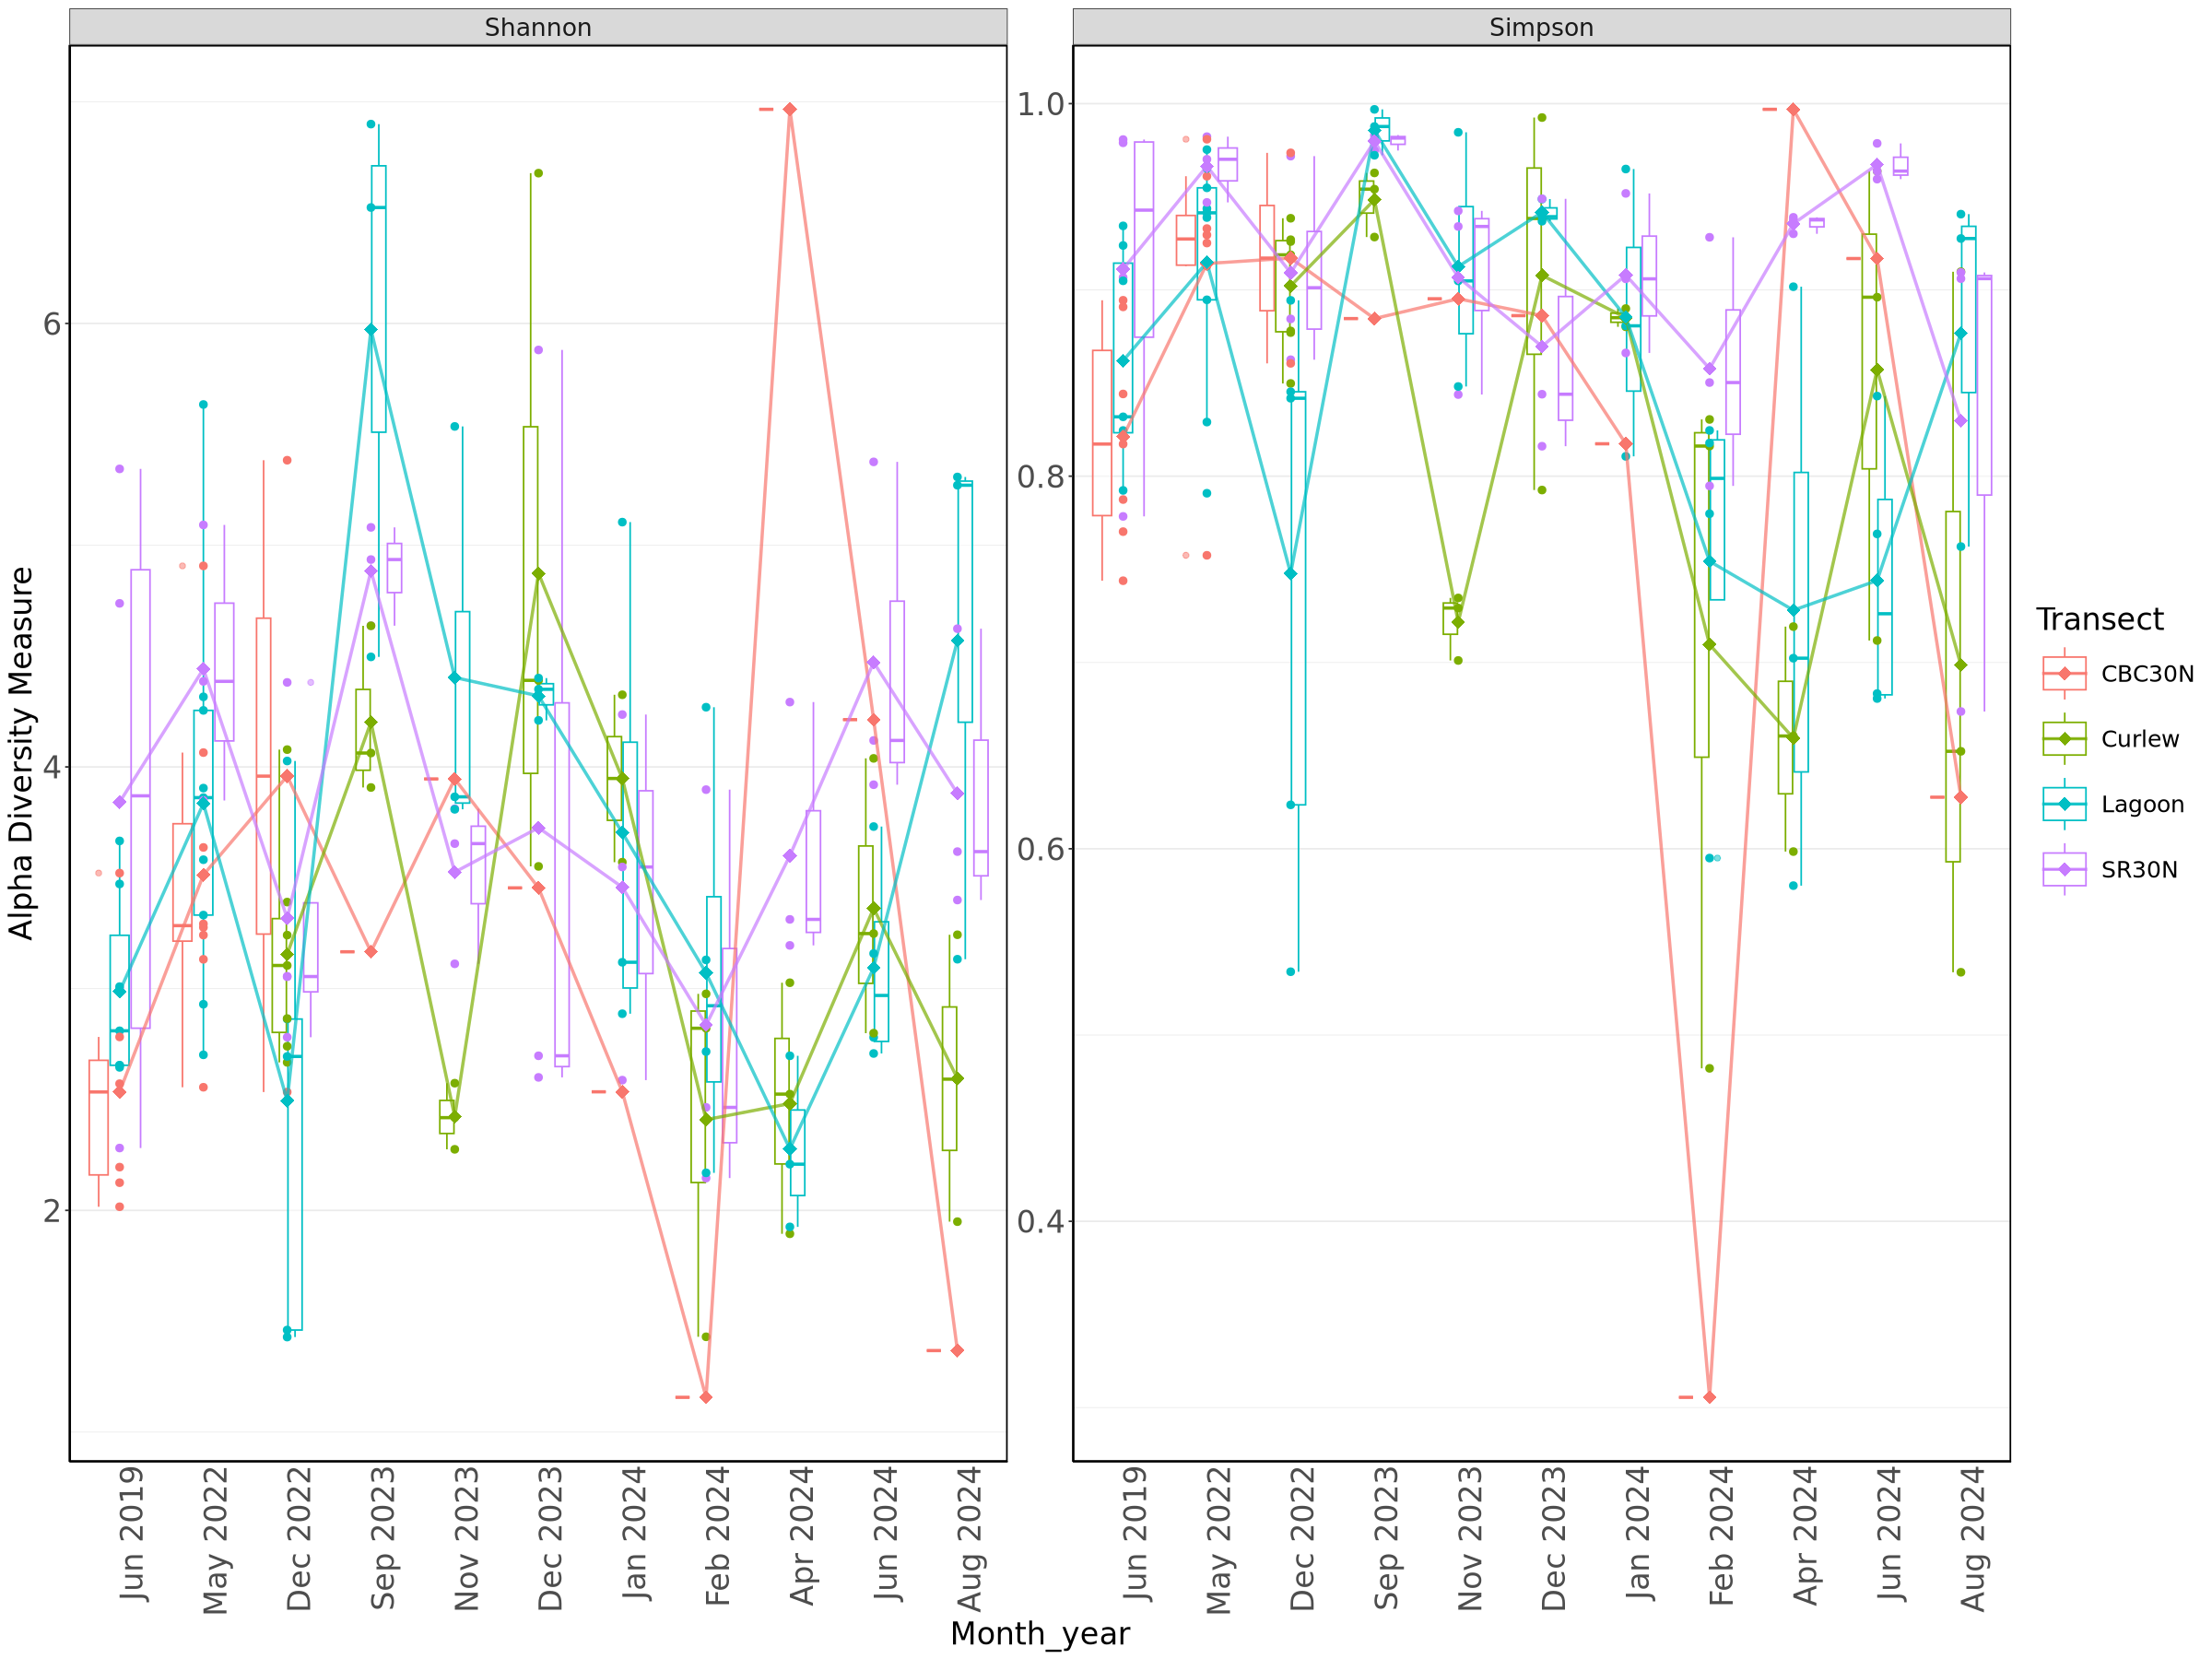

In [78]:
# Alpha diversity dot-line plot
plot_richness(ps_mcav_high, x="Month_year", measures=c("Shannon", "Simpson"), color="Transect") + 
  geom_boxplot(alpha = 0.5) + # Added alpha for better visibility of points
  geom_point(size=2) +
  # --- ADD THIS SECTION ---
  stat_summary(
    fun = mean, 
    geom = "line", 
    aes(group = Transect), 
    linewidth = 1, 
    alpha = 0.7
  ) +
  stat_summary(
    fun = mean, 
    geom = "point", 
    shape = 18, 
    size = 4, 
    aes(group = Transect)
  ) +
  # -------------------------
  theme_bw() +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 20),
    legend.text = element_text(size = 15),
    legend.key.width = unit(1.3, "cm"),
    legend.key.height = unit(1.5, "cm"),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 90, vjust = 1, hjust = 1, size=20),
    axis.text.y = element_text(size = 20),
    text = element_text(size = 20)
  )

### health_status

**Figure notes:**
-disease pops up in May 2022 and Feb 2024 **which colony had dsiease in 022024?**
- seems as though alpha diversity decreased from 052022 and 122022 as disease decimated mcavs
- AGAIN; increased alpha diversity in sept 2023 from healthy colonies to healthy and bleached

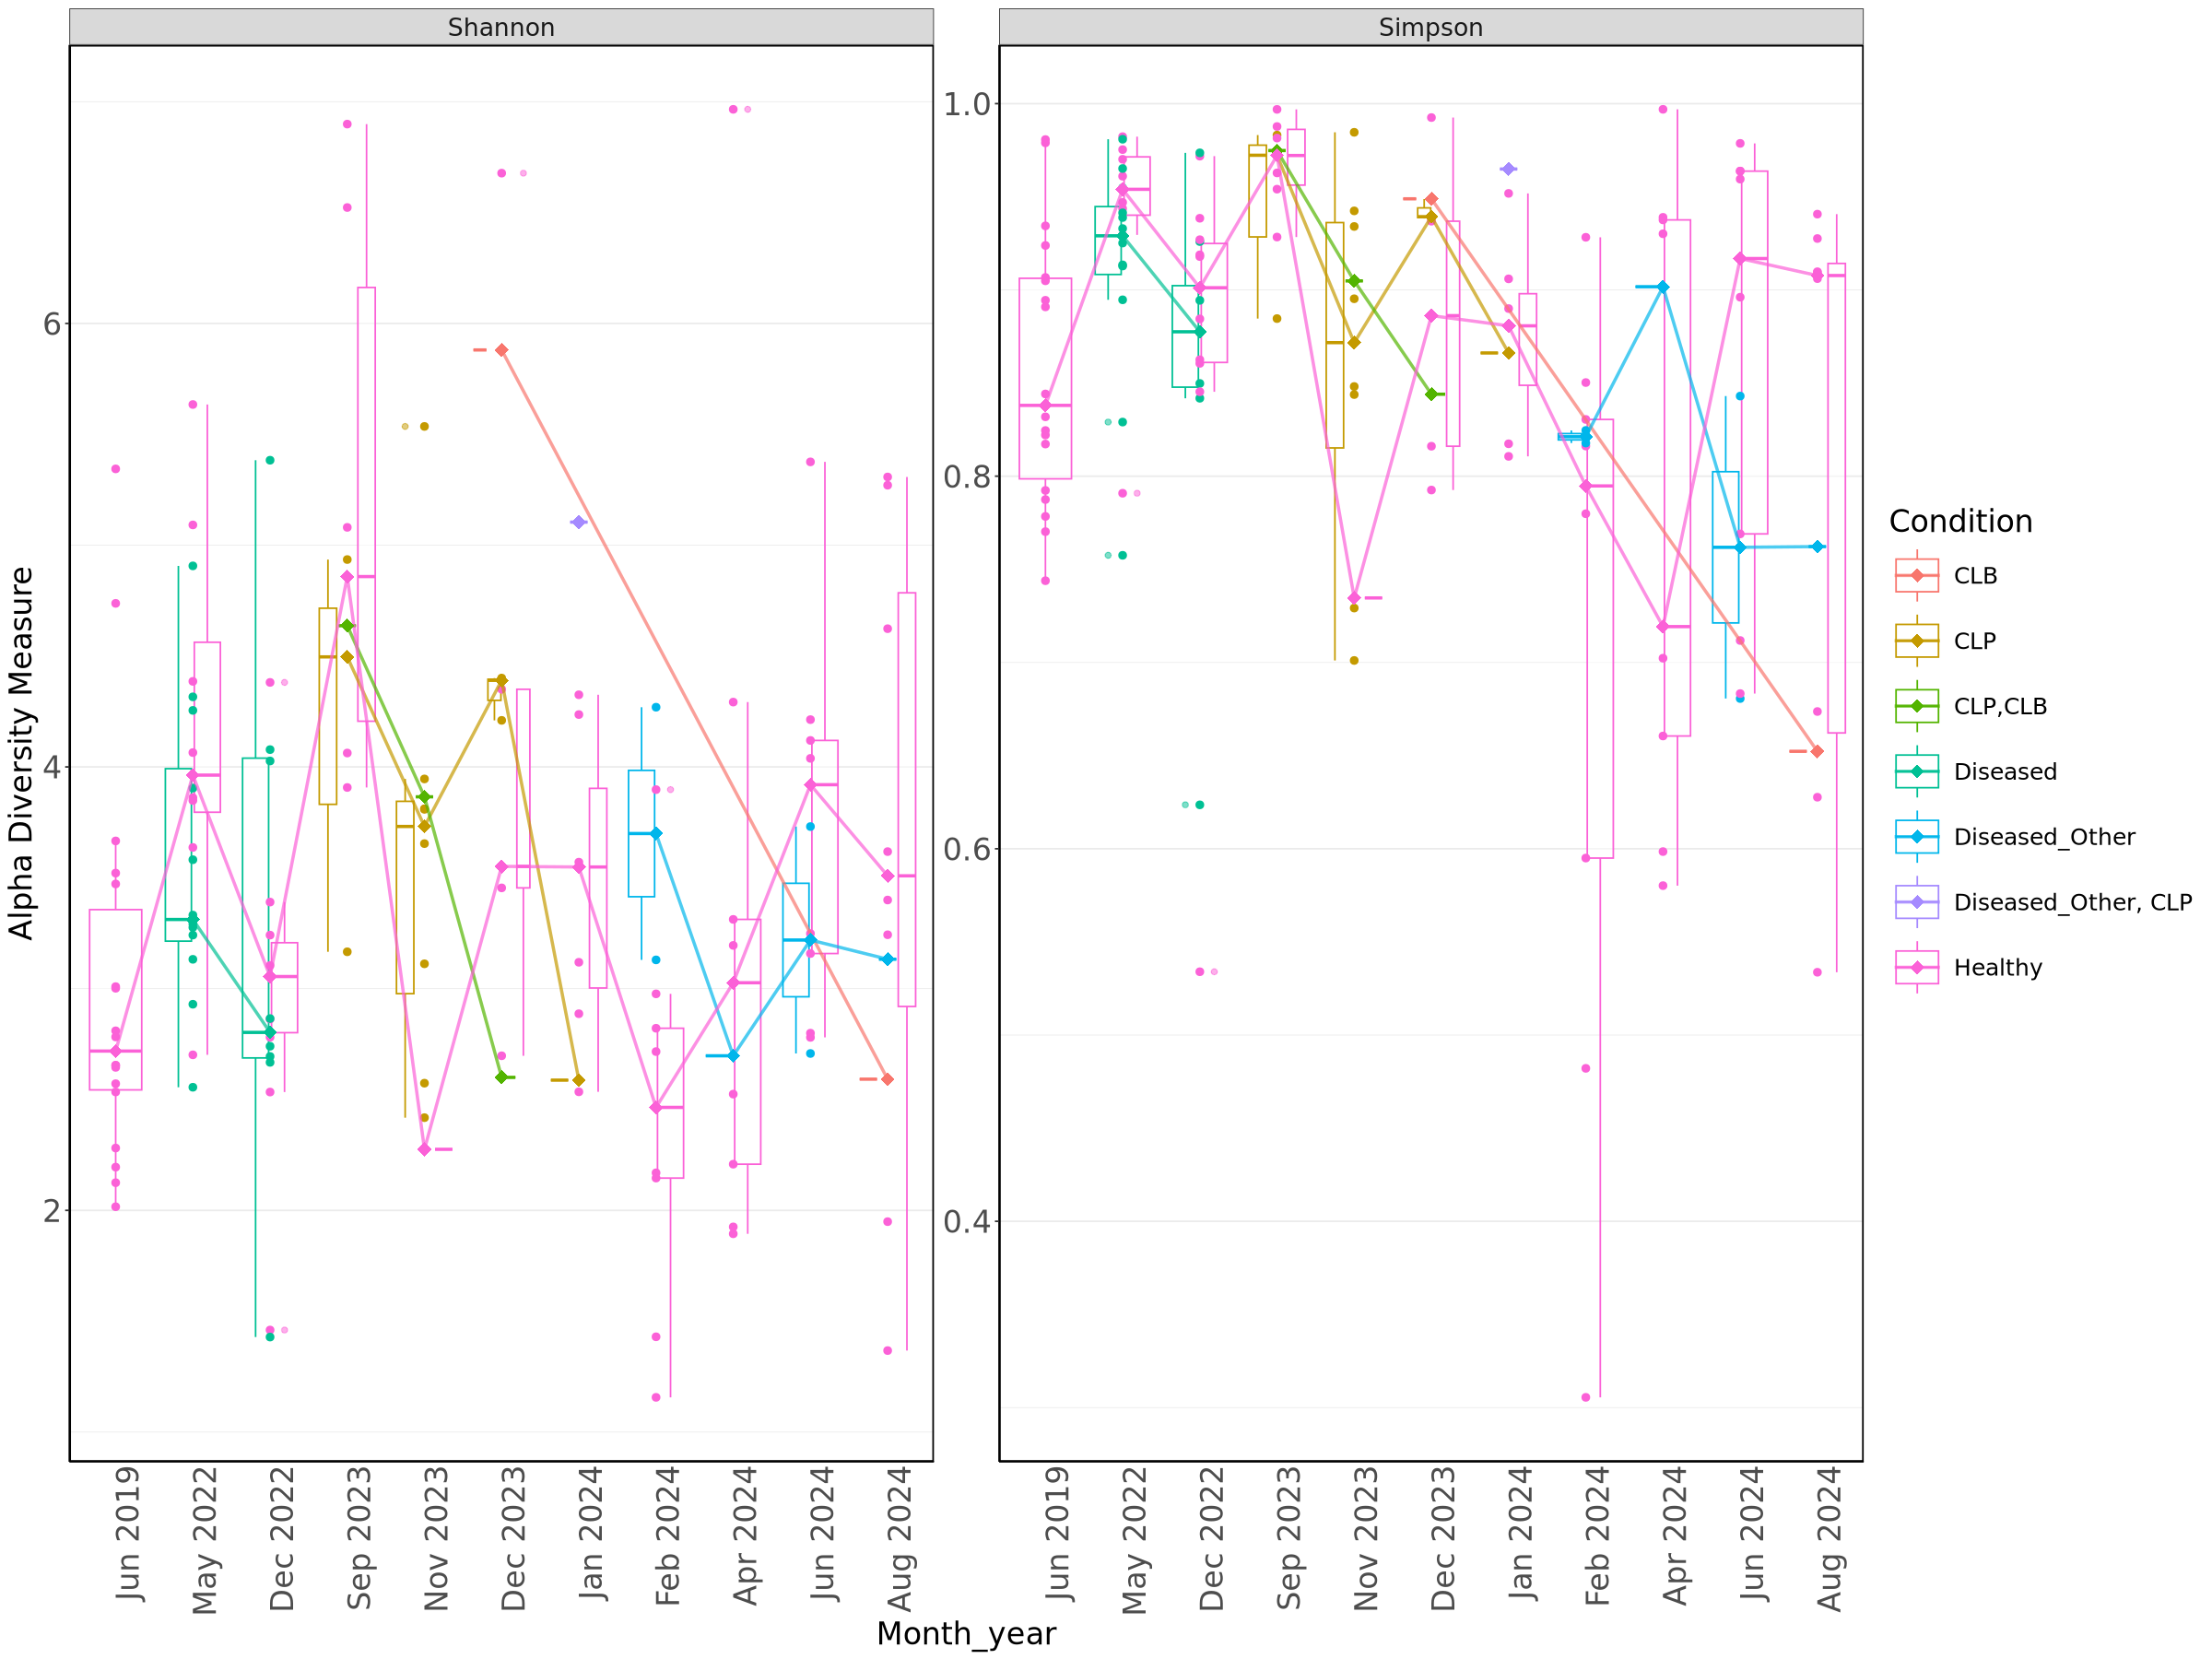

In [81]:
# Alpha diversity dot-line plot
plot_richness(ps_mcav_high, x="Month_year", measures=c("Shannon", "Simpson"), color="Condition") + 
  geom_boxplot(alpha = 0.5) + # Added alpha for better visibility of points
  geom_point(size=2) +
  # --- ADD THIS SECTION TO ADD THE MEAN AS A POINT---
  stat_summary(
    fun = median, 
    geom = "line", 
    aes(group = Condition), 
    linewidth = 1, 
    alpha = 0.7
  ) +
  stat_summary(
    fun = median, 
    geom = "point", 
    shape = 18, 
    size = 4, 
    aes(group = Condition)
  ) +
  # -------------------------
  theme_bw() +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 20),
    legend.text = element_text(size = 15),
    legend.key.width = unit(1.3, "cm"),
    legend.key.height = unit(1.5, "cm"),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 90, vjust = 1, hjust = 1, size=20),
    axis.text.y = element_text(size = 20),
    text = element_text(size = 20)
  )

# network_analysis?

In [ ]:
entrty> data(enterotype)

In [78]:

all <- make_network(ps_prune_high, "samples", max.dist=0.3)